In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.markers import MarkerStyle
from matplotlib.path import Path
import btrack, numpy as np, pandas as pd
from btrack.constants import BayesianUpdates
from scipy.stats import zscore
from scipy.signal import savgol_filter

from scipy.stats import binned_statistic_2d
from scipy.signal import savgol_filter

import anndata as an
import scanpy as sc
from collections import Counter
from matplotlib.patches import Patch
import warnings

# tracking algs
import trackpy as tp

Notebook to predict cell cycle phases for individual cells from FUCCI time-series imaging data
* 4 conditions (N wells/replicates): Control (3), mmMYOD1 (2), siPRRX1 (2), HYB (3)

# Load in data

In [2]:
%%time
dpath = "/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/regionprops/"
file_list = glob.glob(f"{dpath}*_*_*.csv") # exclude the test image

df_list = []

for fpath in file_list:
    basename = os.path.basename(fpath).replace(".csv", "")
    stage, condition, scene, _ = basename.split("_")
    
    df = pd.read_csv(fpath)
    df['basename'] = basename
    df['stage'] = int(stage)
    df['condition'] = condition
    df['scene'] = scene
    
    print(f"\t{basename} {df.shape=}")

    df_list.append(df)


df = pd.concat(df_list)
print(f"{df.shape=}")

df['cell_id'] = df['basename'] + "_label" + df['label'].astype(str)

# shift stage 2 times to follow after stage 1
max_time_stage1 = df.loc[df["stage"] == 1, "time"].max()
df["time_shifted"] = df["time"] + (
    (df["stage"] == 2) * (max_time_stage1 + 1)
)

df.head()

	02_siPRRX1_B3_props df.shape=(188240, 49)
	01_mmMYOD1_D4_props df.shape=(35964, 49)
	01_control_D2_props df.shape=(31271, 49)
	01_hybrid_C3_props df.shape=(49123, 49)
	01_mmMYOD1_D3_props df.shape=(33663, 49)
	02_hybrid_C6_props df.shape=(123894, 49)
	02_hybrid_C4_props df.shape=(145648, 49)
	01_hybrid_C4_props df.shape=(64240, 49)
	02_mmMYOD1_D4_props df.shape=(72217, 49)
	02_siPRRX1_B4_props df.shape=(198826, 49)
	02_hybrid_C3_props df.shape=(133759, 49)
	01_hybrid_C6_props df.shape=(57297, 49)
	01_control_C2_props df.shape=(39967, 49)
	02_mmMYOD1_D3_props df.shape=(68484, 49)
	01_siPRRX1_B4_props df.shape=(80394, 49)
	02_control_C2_props df.shape=(94187, 49)
	01_siPRRX1_B3_props df.shape=(70595, 49)
	01_control_B2_props df.shape=(40213, 49)
	02_control_D2_props df.shape=(65965, 49)
	02_control_B2_props df.shape=(91039, 49)
df.shape=(1684986, 49)
CPU times: user 14.3 s, sys: 1.5 s, total: 15.8 s
Wall time: 18.8 s


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,mKate_sum,time,seg_channel_idx,seg_channel_name,basename,stage,condition,scene,cell_id,time_shifted
0,1,139.0,770,366,786,378,192.0,777.402878,371.733813,0.787459,...,29.239852,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label1,67
1,2,92.0,513,2953,524,2964,121.0,517.945652,2957.891304,0.204520,...,11.038021,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label2,67
2,3,131.0,2553,722,2566,735,169.0,2558.908397,727.664122,0.528127,...,16.582590,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label3,67
3,4,638.0,2205,1117,2234,1148,899.0,2219.070533,1131.733542,0.746750,...,135.223725,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label4,67
4,5,146.0,702,806,719,818,204.0,710.260274,811.657534,0.793181,...,30.855447,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label5,67


# Visualize reporters

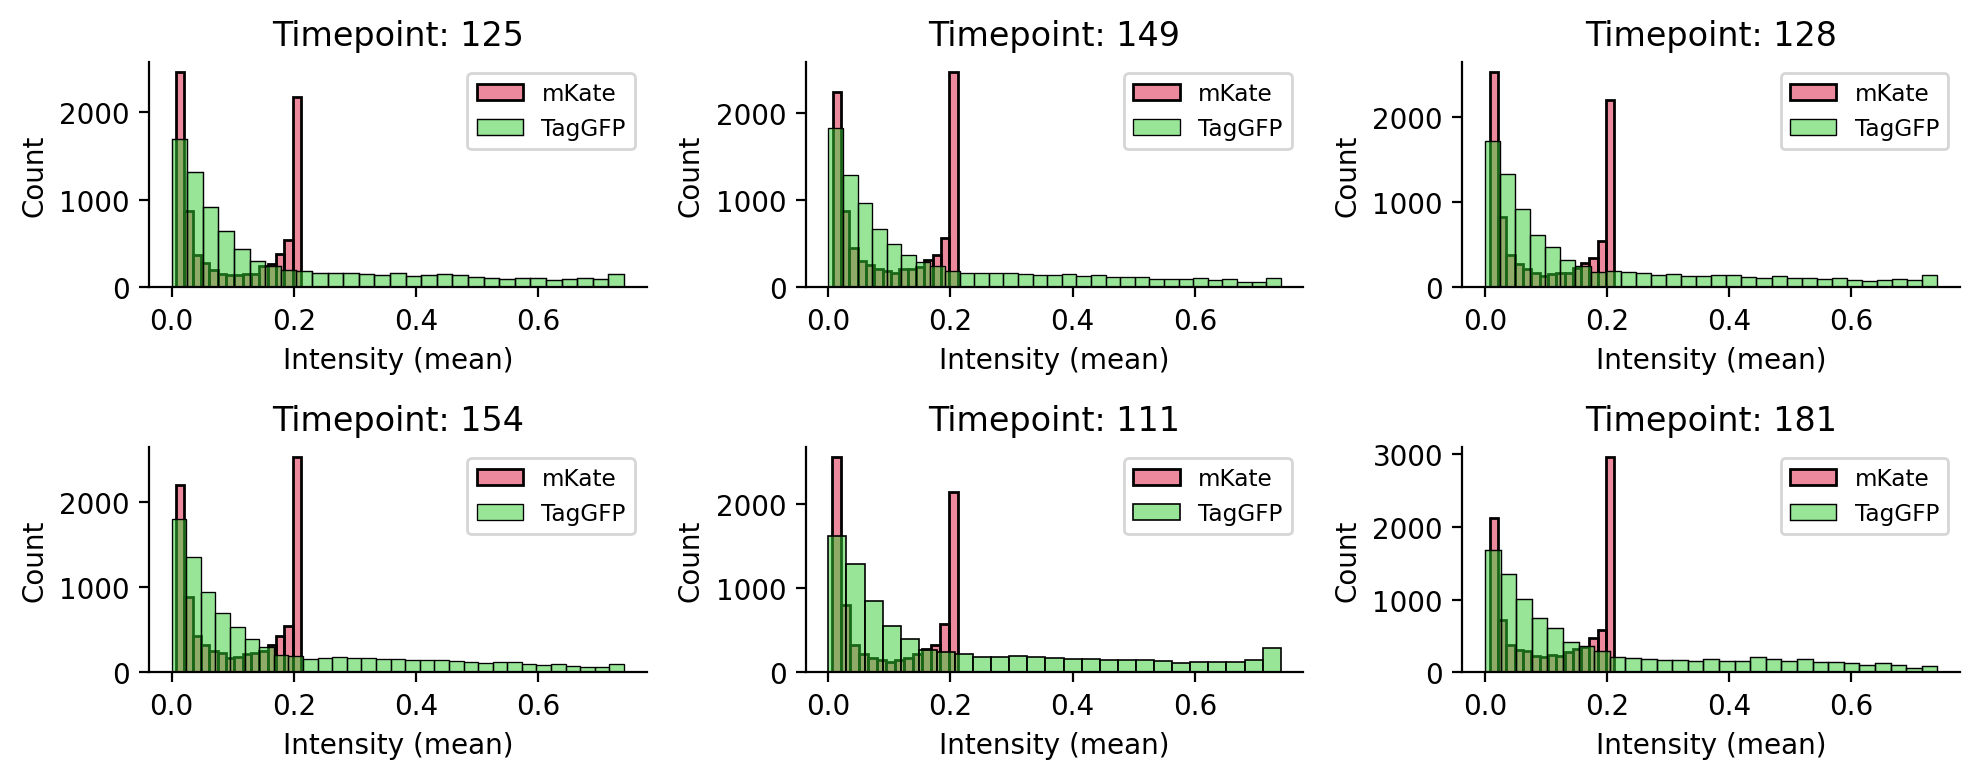

In [4]:
# pick 6 random time points
timepoints = np.random.choice(df["time_shifted"].unique(), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(10, 4), dpi=200)

for ax, time in zip(axes.flatten(), timepoints):
    subset = df[df['time_shifted'] == time]

    sns.histplot(
        data=subset,
        x='mKate_mean',
        color='crimson',
        alpha=0.5,
        label='mKate',
        ax=ax
    )

    sns.histplot(
        data=subset,
        x='TaGFP_mean',
        color='limegreen',
        alpha=0.5,
        label='TagGFP',
        ax=ax
    )

    ax.set_title(f"Timepoint: {time}")
    ax.set_xlabel("Intensity (mean)")
    ax.set_ylabel("Count")
    ax.legend(fontsize='small')

sns.despine()
plt.tight_layout()
plt.show()

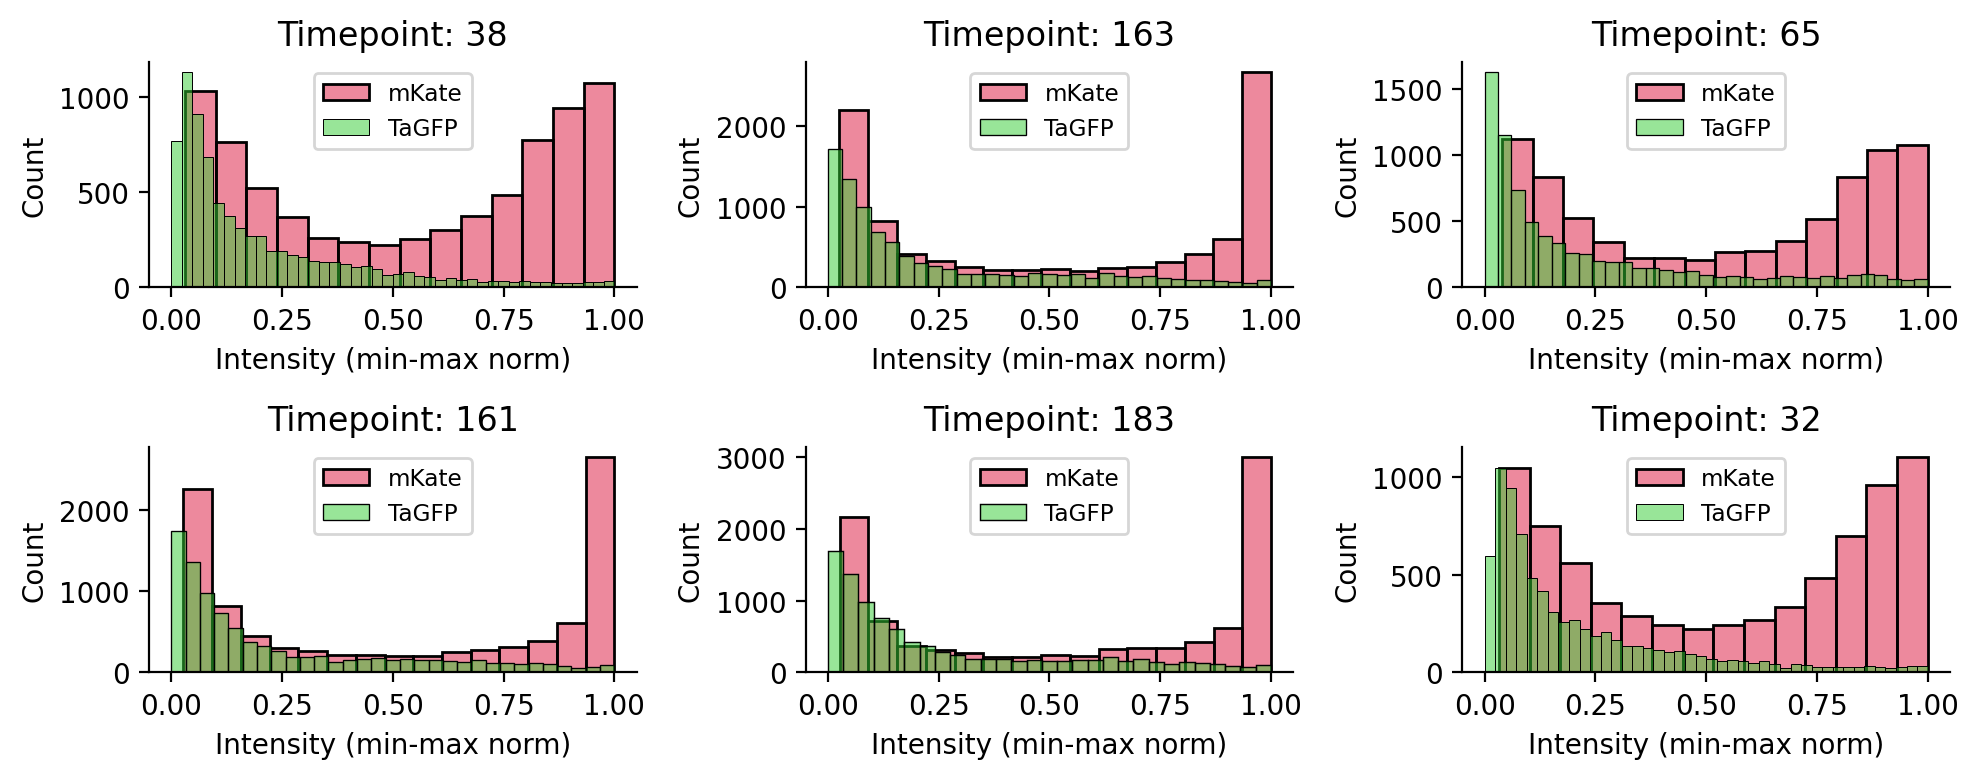

In [5]:
# Simple normalization (min-max)
df['TaGFP_norm'] = (df['TaGFP_mean'] - df['TaGFP_mean'].min()) / (df['TaGFP_mean'].max() - df['TaGFP_mean'].min())
df['mKate_norm'] = (df['mKate_mean'] - df['mKate_mean'].min()) / (df['mKate_mean'].max() - df['mKate_mean'].min())

# pick 6 random time points
timepoints = np.random.choice(df["time_shifted"].unique(), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(10, 4), dpi=200)
# fig, axes = plt.subplots(3, 2, figsize=(7, 6), dpi=200)

for ax, time in zip(axes.flatten(), timepoints):
    subset = df[df['time_shifted'] == time]

    sns.histplot(
        data=subset,
        x='mKate_norm',
        color='crimson',
        alpha=0.5,
        label='mKate',
        ax=ax
    )

    sns.histplot(
        data=subset,
        x='TaGFP_norm',
        color='limegreen',
        alpha=0.5,
        label='TaGFP',
        ax=ax
    )

    ax.set_title(f"Timepoint: {time}")
    ax.set_xlabel("Intensity (min-max norm)")
    ax.set_ylabel("Count")
    ax.legend(fontsize='small')

sns.despine()
plt.tight_layout()
plt.show()

# Track cells

In [6]:
%%time
### --- Tracking by stage ---
# Rename columns for trackpy
pdf = df.rename(columns={
    "time": "frame",
    "centroid_x_px": "x",
    "centroid_y_px": "y"
}).copy()

# Store all per-(cond,scene,stage) tracking results in a list
all_track_dfs = []

for (cond, scene, stage), g in pdf.groupby(["condition", "scene", "stage"]):
    print(f"Tracking: {(cond, scene, stage)}")
    g_sorted = g.sort_values("frame")
    
    # Run tracking
    linked = tp.link_df(
        g_sorted,
        search_range=55,        # adjust as needed
        memory=5,
        adaptive_stop=True
    )
    
    # Add context columns
    linked["condition"] = cond
    linked["scene"] = scene
    linked["stage"] = stage
    
    # Optionally filter out short tracks (e.g., less than 50 frames)
    linked = tp.filter_stubs(linked, threshold=10)
    
    print(f"\tlinked.shape: {linked.shape}")
    
    all_track_dfs.append(linked)

# Combine all per-stage results
all_traj = pd.concat(all_track_dfs, ignore_index=True)
print(f"All tracked data shape: {all_traj.shape}")

Frame 136: 1690 trajectories present.
	linked.shape: (194021, 54)
All tracked data shape: (1633220, 54)
CPU times: user 52.9 s, sys: 2.93 s, total: 55.8 s
Wall time: 1min 1s


In [7]:
all_traj['particle_id'] = all_traj['stage'].astype(str) + '_' + all_traj['condition'] + '_' + all_traj['scene'] + '_' + all_traj['particle'].astype(str)

columns_to_keep = [
    'condition', 'scene', 'stage', 'particle', 'particle_id', 'frame', 'time_shifted',
    'filled_area', 'Cy5_mean', 'TaGFP_mean', 'mKate_mean', 'x', 'y',
]

all_traj = all_traj[columns_to_keep]

all_traj.head()

,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647
1,control,B2,1,2,1_control_B2_2,0,0,107.0,0.094927,0.234181,0.180446,232.588785,2579.112150
2,control,B2,1,3,1_control_B2_3,0,0,118.0,0.037478,0.136275,0.193143,616.525424,551.245763
3,control,B2,1,4,1_control_B2_4,0,0,157.0,0.040521,0.247596,0.201448,1693.929936,2509.847134
4,control,B2,1,5,1_control_B2_5,0,0,86.0,0.107119,0.047916,0.010504,2243.581395,2229.174419


In [8]:
print(all_traj.shape)

(1633220, 13)


# Filter trajectories

In [9]:
# calculate total trajectory length per cell
all_traj['path_length'] = all_traj.groupby('particle_id')['frame'].transform(lambda x: x.nunique())

all_traj.groupby('condition')['path_length'].describe()

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
control,352727.0,90.757302,39.345742,10.0,67.0,77.0,137.0,137.0
hybrid,555376.0,79.582240,39.261481,10.0,50.0,67.0,122.0,137.0
mmMYOD1,201974.0,88.038550,38.563494,10.0,66.0,70.0,135.0,137.0
siPRRX1,523143.0,80.494096,38.007753,10.0,55.0,67.0,119.0,137.0


In [10]:
tdf = all_traj.copy()
print(f"N cells: {tdf['particle_id'].nunique()}")

min_path_length = 50

# remove short trajectories
tdf = tdf[tdf['path_length'] >= min_path_length]
print(f"N cells with at least 50 frames: {tdf['particle_id'].nunique()}\n")

# assess trajectory gaps
tdf = tdf.sort_values(['particle_id', 'frame'])

tdf['frame_diff'] = tdf.groupby('particle_id')['frame'].diff()

# Find gaps (diff > 1)
tdf['gap_length'] = tdf['frame_diff'] - 1
tdf['gap_length'] = tdf['gap_length'].where(tdf['gap_length'] > 0, 0)  # set negative/0 diffs to 0

gap_info = tdf.groupby('particle_id')['gap_length'].agg([
    ('has_gap', lambda x: x.gt(0).any()),
    ('max_gap_length', 'max')
]).reset_index()

# Merge flag and gap info back to the original dataframe
tdf = tdf.merge(gap_info, on='particle_id')
tdf = tdf.drop(columns=['frame_diff'])

print(f"{tdf.drop_duplicates('particle_id')['has_gap'].value_counts()}\n")

tdf.drop_duplicates('particle_id').groupby('condition')['max_gap_length'].describe()

N cells: 27824
N cells with at least 50 frames: 15068

has_gap
False    8941
True     6127
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
control,3366.0,0.624777,1.321116,0.0,0.0,0.0,0.0,5.0
hybrid,4908.0,1.305420,1.655664,0.0,0.0,0.0,2.0,5.0
mmMYOD1,1957.0,0.761369,1.405794,0.0,0.0,0.0,1.0,5.0
siPRRX1,4837.0,1.330784,1.703688,0.0,0.0,0.0,3.0,5.0


# Normalize reporters

In [11]:
### ALL RANDOM
# test_size = 500
# sampled_cells = np.random.choice(tdf['particle_id'].unique(), size=test_size, replace=False)

# test_df = tdf[tdf['particle_id'].isin(sampled_cells)].reset_index(drop=True)
# print(f"N cells: {test_df['particle_id'].nunique()}")

# ### RANDOM PER CONDITION
# sampled_cells = (
#     tdf.groupby('condition')['particle_id']
#     .apply(lambda x: np.random.choice(x.unique(), size=200, replace=False))
#     .explode()
#     .tolist()
# )

# test_df = tdf[tdf['particle_id'].isin(sampled_cells)].reset_index(drop=True)
# print(f"N cells: {test_df['particle_id'].nunique()}")

## ALL CELLS
test_df = tdf.copy()
print(f"N cells: {test_df['particle_id'].nunique()}")

# mKate_global_max = test_df['mKate_mean'].max()
# TaGFP_global_max = test_df['TaGFP_mean'].max()
# print(f"mKate global max: {mKate_global_max}")
# print(f"TaGFP global max: {TaGFP_global_max}")

# # Global normalization for each reporter
# test_df['TaGFP_norm'] = (test_df['TaGFP_mean'] - test_df['TaGFP_mean'].min()) / (test_df['TaGFP_mean'].max() - test_df['TaGFP_mean'].min())
# test_df['mKate_norm'] = (test_df['mKate_mean'] - test_df['mKate_mean'].min()) / (test_df['mKate_mean'].max() - test_df['mKate_mean'].min())
# test_df['Cy5_norm'] = (test_df['Cy5_mean'] - test_df['Cy5_mean'].min()) / (test_df['Cy5_mean'].max() - test_df['Cy5_mean'].min())


# Global normalization for each reporter (by stage)
green_min = test_df.groupby("stage")["TaGFP_mean"].transform("min")
green_max = test_df.groupby("stage")["TaGFP_mean"].transform("max")

red_min = test_df.groupby("stage")["mKate_mean"].transform("min")
red_max = test_df.groupby("stage")["mKate_mean"].transform("max")

cy5_min = test_df.groupby("stage")["Cy5_mean"].transform("min")
cy5_max = test_df.groupby("stage")["Cy5_mean"].transform("max")

# 2. Perform the normalization using the stage-specific boundaries
test_df["TaGFP_norm"] = (test_df["TaGFP_mean"] - green_min) / (
    green_max - green_min
)
test_df["mKate_norm"] = (test_df["mKate_mean"] - red_min) / (red_max - red_min)
test_df["Cy5_norm"] = (test_df["Cy5_mean"] - cy5_min) / (cy5_max - cy5_min)


print(test_df.shape)
test_df.head()

N cells: 15068
(1300948, 20)


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length,gap_length,has_gap,max_gap_length,TaGFP_norm,mKate_norm,Cy5_norm
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647,67,0.0,False,0.0,0.551797,0.972781,0.058496
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,0.205844,32.937063,157.265734,67,0.0,False,0.0,0.533058,0.970838,0.175343
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,0.202407,34.091503,159.078431,67,0.0,False,0.0,0.507353,0.954420,0.312970
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,0.197891,33.737179,160.628205,67,0.0,False,0.0,0.498645,0.932851,0.474235
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,0.197863,34.177215,161.974684,67,0.0,False,0.0,0.496974,0.932718,0.623611


# Cell counts

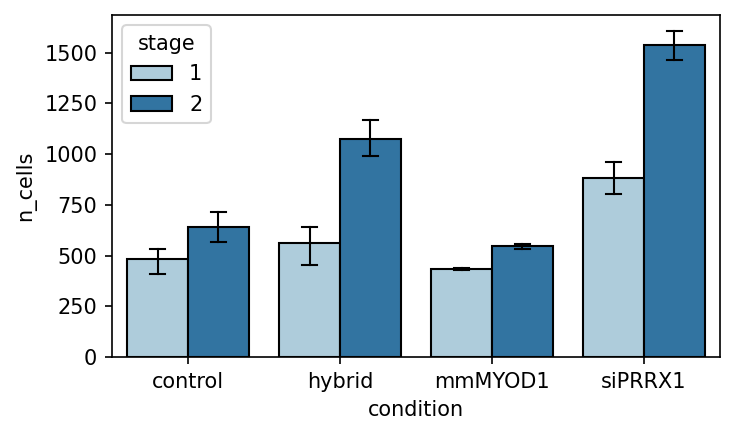

In [12]:
cell_counts = (
    test_df.groupby(['condition', 'scene', 'stage'])['particle_id']
    .nunique()
    .reset_index(name='n_cells')
)

plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(5, 3))

sns.barplot(
    cell_counts,
    x='condition',
    y='n_cells',
    hue='stage',
    palette='Paired',
    ec='k',
    linewidth=1,
    capsize=0.2,
    err_kws={'color': 'k', 'lw': 1},
)

plt.tight_layout()
plt.show()

# Flag noisy cells

In [13]:
%%time

red = 'mKate_norm'
green = 'TaGFP_norm'
jump_thresh = 0.5
max_allowed_jumps = 2

df = test_df.copy()

# --- Compute per-row differences, grouped by cell ---
df['red_diff'] = df.groupby('particle_id')[red].diff().abs()
df['green_diff'] = df.groupby('particle_id')[green].diff().abs()

# --- Flag "big jumps" ---
df['red_big_jump'] = df['red_diff'] > jump_thresh
df['green_big_jump'] = df['green_diff'] > jump_thresh

# --- Aggregate per-cell (particle_id): count of big jumps ---
jump_counts = (
    df.groupby('particle_id')[['red_big_jump', 'green_big_jump']].sum()
    .rename(columns={'red_big_jump': 'red_big_jump_count', 'green_big_jump': 'green_big_jump_count'})
)

# --- Flag noisy cells at the cell (particle) level ---
jump_counts['noisy'] = (jump_counts['red_big_jump_count'] > max_allowed_jumps) | \
                       (jump_counts['green_big_jump_count'] > max_allowed_jumps)

# --- Merge/noisy to df, then broadcast to all rows for each cell ---
noisy_map = jump_counts['noisy']
df['noisy'] = df['particle_id'].map(noisy_map)

# Optional: Clean up helper cols
df.drop(['red_diff', 'green_diff', 'red_big_jump', 'green_big_jump'], axis=1, inplace=True)
df.head()

CPU times: user 1.1 s, sys: 253 ms, total: 1.35 s
Wall time: 1.37 s


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,x,y,path_length,gap_length,has_gap,max_gap_length,TaGFP_norm,mKate_norm,Cy5_norm,noisy
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,...,33.529412,156.867647,67,0.0,False,0.0,0.551797,0.972781,0.058496,False
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,...,32.937063,157.265734,67,0.0,False,0.0,0.533058,0.970838,0.175343,False
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,...,34.091503,159.078431,67,0.0,False,0.0,0.507353,0.954420,0.312970,False
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,...,33.737179,160.628205,67,0.0,False,0.0,0.498645,0.932851,0.474235,False
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,...,34.177215,161.974684,67,0.0,False,0.0,0.496974,0.932718,0.623611,False


## Visualize

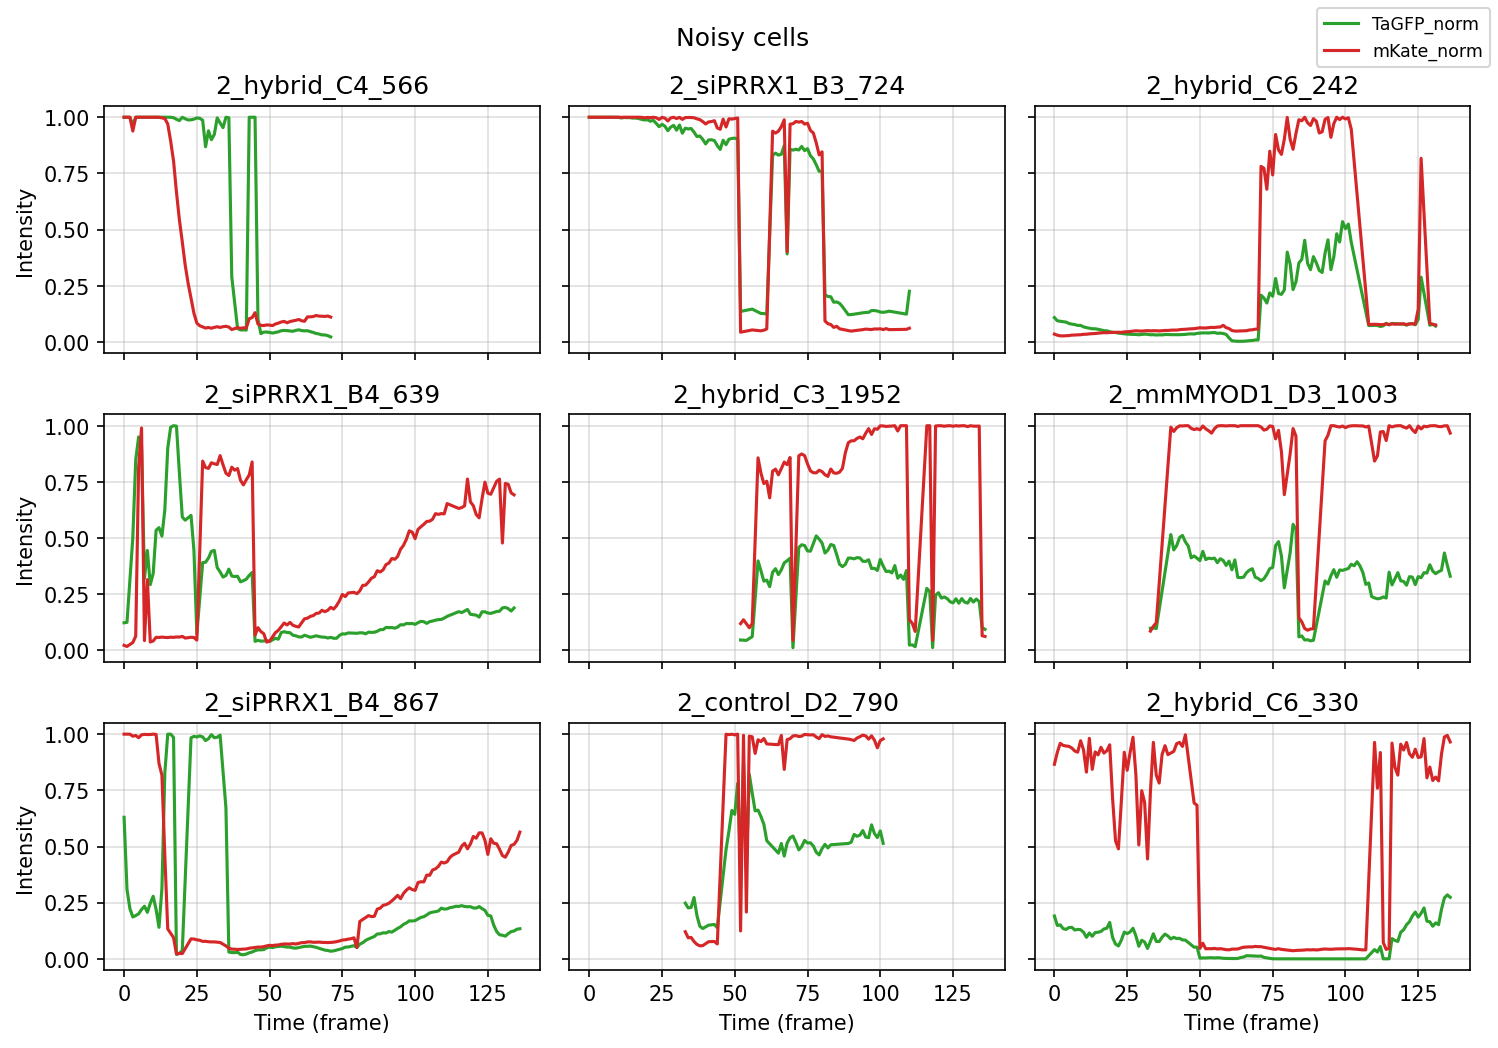

In [14]:
### visualize noisy cells

tmp = df[df['noisy']]
         
noisy_cells = np.random.choice(tmp['particle_id'].unique(), size=9, replace=False)
# noisy_cells = tmp[tmp['noisy']]['particle_id'].unique()

n_cols = 3
n_rows = int(np.ceil(len(noisy_cells) / n_cols))


fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 7), sharex=True, sharey=True, dpi=150)
axes = axes.flatten()

for idx, cell_id in enumerate(noisy_cells):
    ax = axes[idx]
    cdf = df[df['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(cdf['frame'], cdf['TaGFP_norm'], label='TaGFP_norm', color='tab:green')
    ax.plot(cdf['frame'], cdf['mKate_norm'], label='mKate_norm', color='tab:red')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    ax.set_xlabel('Time (frame)' if idx // n_cols == n_rows - 1 else '')
    ax.set_ylabel('Intensity' if idx % n_cols == 0 else '')

for ax in axes[len(noisy_cells):]:
    ax.set_visible(False)
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.suptitle("Noisy cells")
plt.tight_layout()
plt.show()

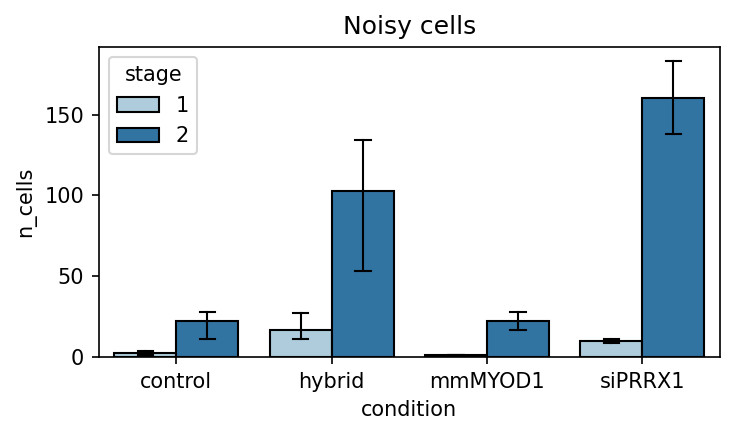

In [15]:
cell_counts = (
    tmp.groupby(['condition', 'scene', 'stage'])['particle_id']
    .nunique()
    .reset_index(name='n_cells')
)

plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(5, 3))

sns.barplot(
    cell_counts,
    x='condition',
    y='n_cells',
    hue='stage',
    palette='Paired',
    ec='k',
    linewidth=1,
    capsize=0.2,
    err_kws={'color': 'k', 'lw': 1},
)

plt.title("Noisy cells")
plt.tight_layout()
plt.show()

N cells after dropping noisy cells: 14249


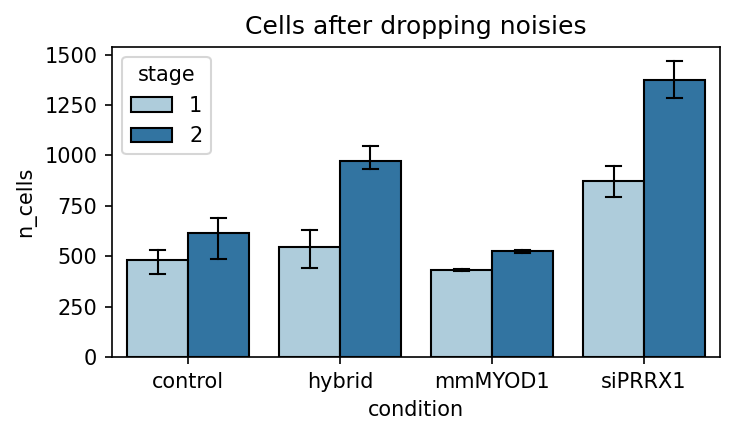

In [16]:
df = df[~df['noisy']]

print(f"N cells after dropping noisy cells: {df['particle_id'].nunique()}")

cell_counts = (
    df.groupby(['condition', 'scene', 'stage'])['particle_id']
    .nunique()
    .reset_index(name='n_cells')
)

plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(5, 3))

sns.barplot(
    cell_counts,
    x='condition',
    y='n_cells',
    hue='stage',
    palette='Paired',
    ec='k',
    linewidth=1,
    capsize=0.2,
    err_kws={'color': 'k', 'lw': 1},
)

plt.title("Cells after dropping noisies")
plt.tight_layout()
plt.show()

# Smooth signal (savgol filter)

<timed exec>:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


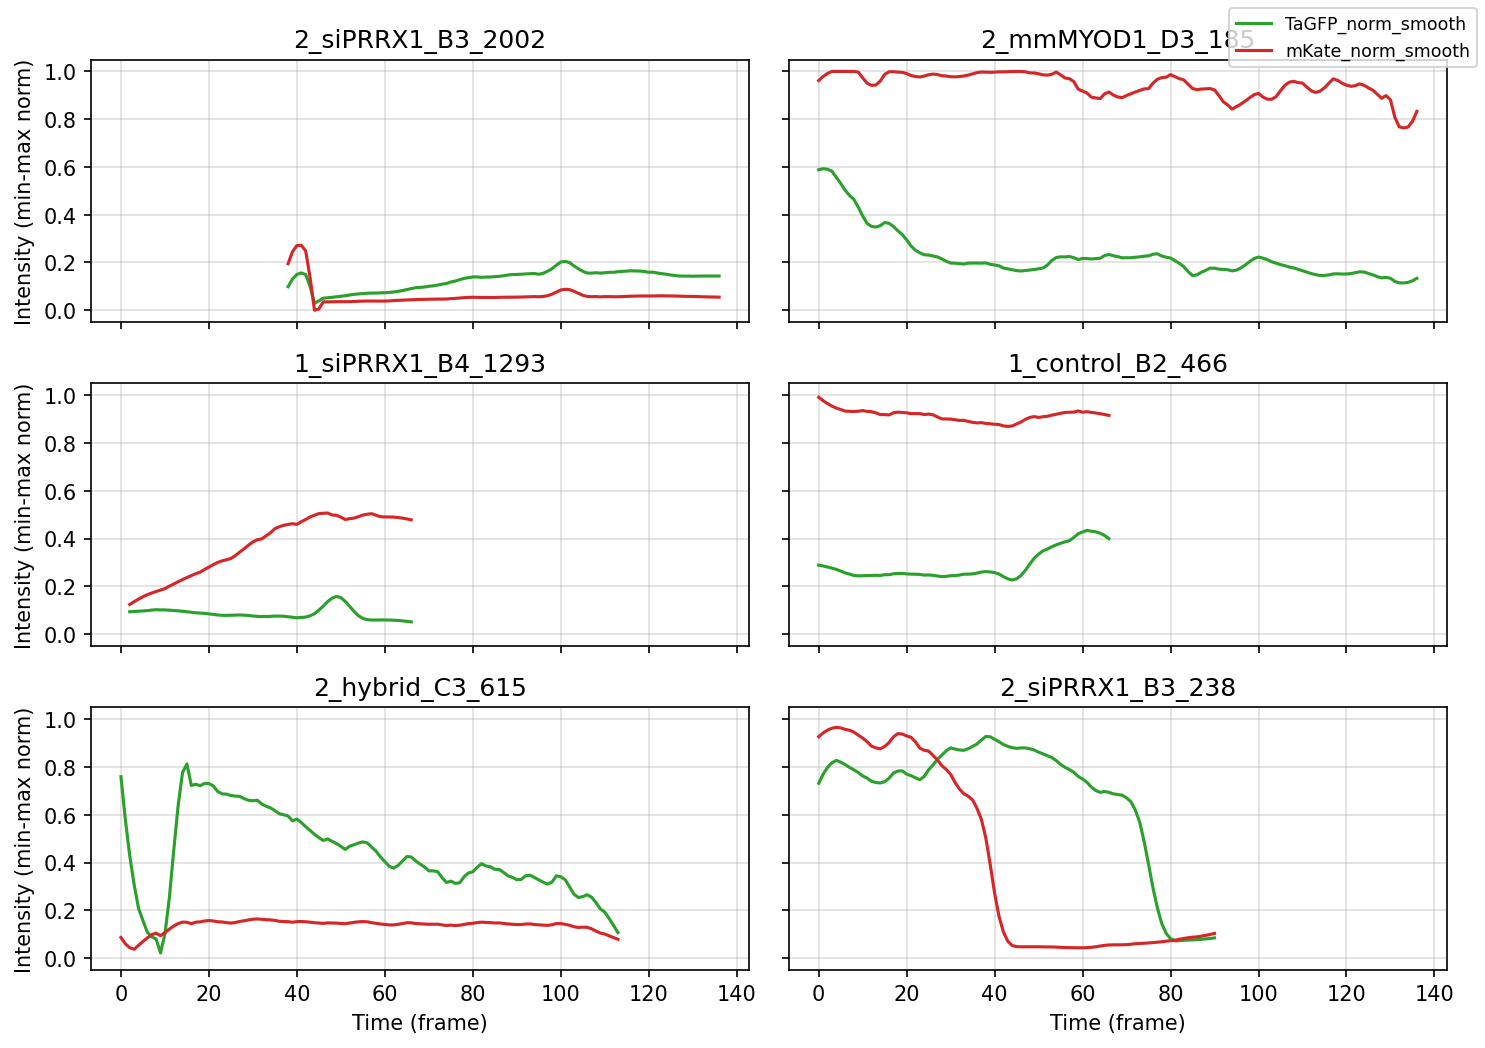

CPU times: user 40.8 s, sys: 699 ms, total: 41.5 s
Wall time: 42.2 s


In [17]:
%%time
def smooth_reporters_group(g, red_col='mKate_norm', green_col='TaGFP_norm', nuc_col='Cy5_norm', window_length=7, polyorder=2):
    g = g.copy()  # Don't modify in-place.
    n = len(g)
    # Must have enough points for filter
    good_len = min(n, window_length if n % 2 == 1 else window_length - 1)
    if good_len < 3:
        g[red_col + '_smooth'] = g[red_col]
        g[green_col + '_smooth'] = g[green_col]
        g[nuc_col + '_smooth'] = g[nuc_col]
    else:
        g = g.sort_values('frame')  # ensure frame order
        g[red_col + '_smooth'] = savgol_filter(g[red_col], window_length=good_len, polyorder=min(polyorder, good_len-1)).clip(0, 1)
        g[green_col + '_smooth'] = savgol_filter(g[green_col], window_length=good_len, polyorder=min(polyorder, good_len-1)).clip(0, 1)
        g[nuc_col + '_smooth'] = savgol_filter(g[nuc_col], window_length=good_len, polyorder=min(polyorder, good_len-1)).clip(0, 1)
    return g

# Use groupby.apply for speed and auto-concatenation
df = df.groupby('particle_id', group_keys=False).apply(
    smooth_reporters_group, 
    red_col='mKate_norm', 
    green_col='TaGFP_norm', 
    nuc_col='Cy5_norm',
    window_length=9, 
    polyorder=2
)

sampled_cells = np.random.choice(df['particle_id'].unique(), size=6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True, dpi=150)

for idx, cell_id in enumerate(sampled_cells):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    cdf = df[df['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(cdf['frame'], cdf['TaGFP_norm_smooth'], label='TaGFP_norm_smooth', color='tab:green')
    ax.plot(cdf['frame'], cdf['mKate_norm_smooth'], label='mKate_norm_smooth', color='tab:red')
    # ax.plot(cdf['frame'], cdf['Cy5_norm_smooth'], label='Cy5_norm_smooth', color='tab:blue')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    if row == 2: 
        ax.set_xlabel('Time (frame)')
    else:
        ax.set_xlabel('')
    if col == 0:
        ax.set_ylabel('Intensity (min-max norm)')
    else:
        ax.set_ylabel('')
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

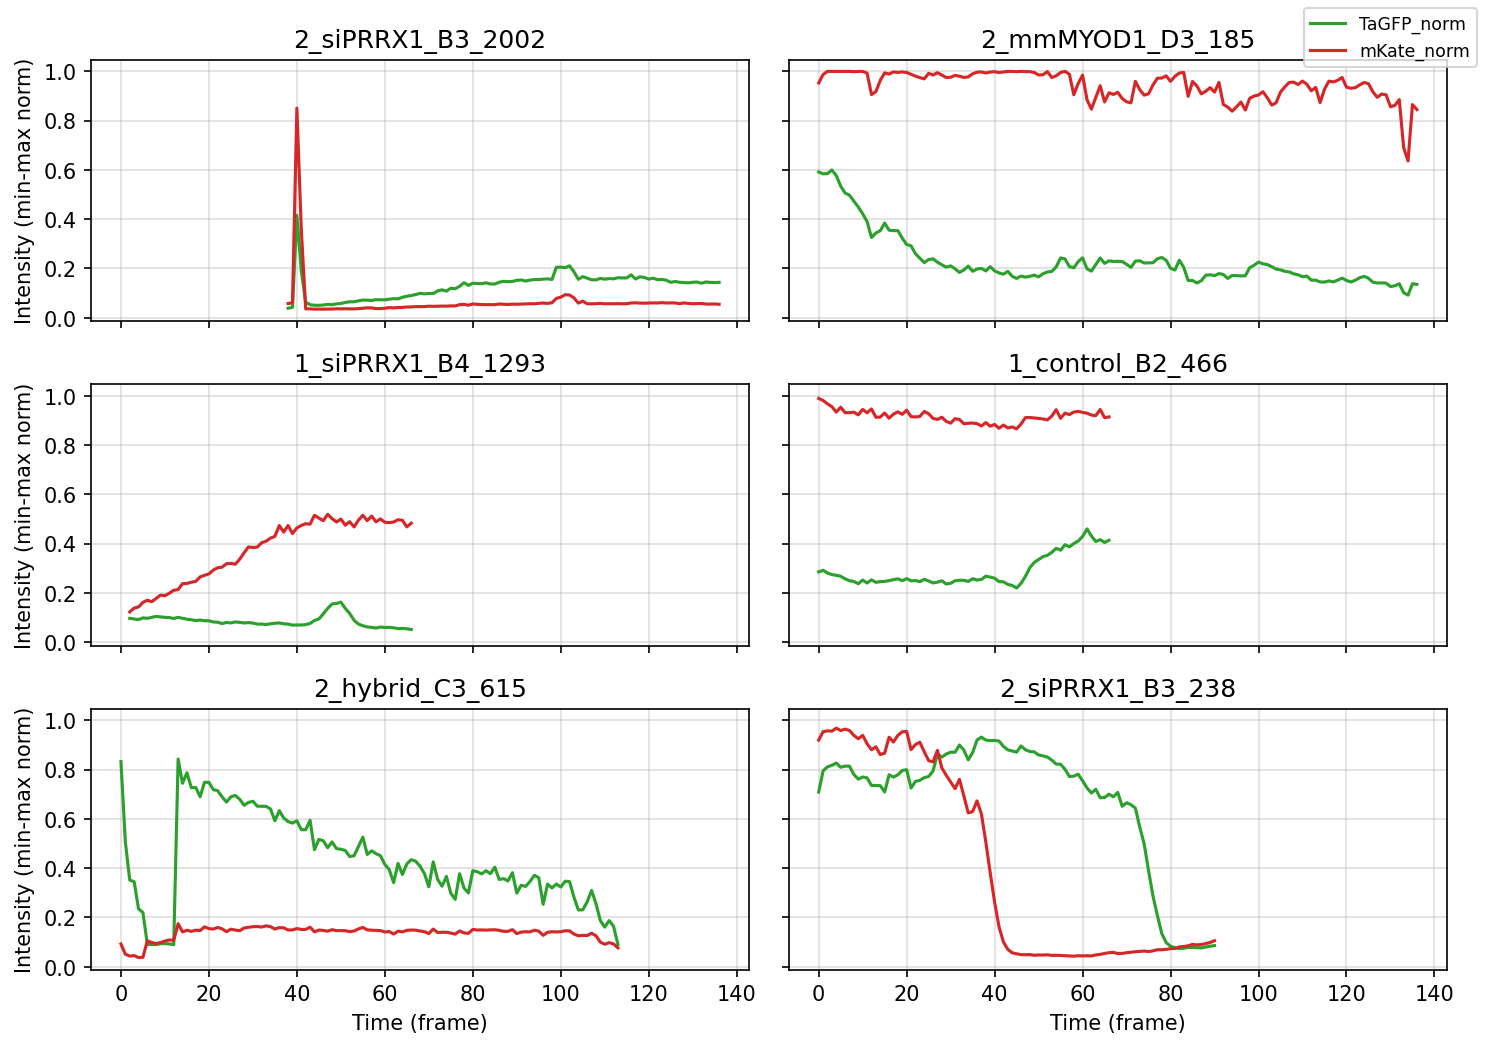

In [18]:
## Look at the unsmoothed signals
fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True)

for idx, cell_id in enumerate(sampled_cells):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    cdf = df[df['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(cdf['frame'], cdf['TaGFP_norm'], label='TaGFP_norm', color='tab:green')
    ax.plot(cdf['frame'], cdf['mKate_norm'], label='mKate_norm', color='tab:red')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    if row == 2: 
        ax.set_xlabel('Time (frame)')
    else:
        ax.set_xlabel('')
    if col == 0:
        ax.set_ylabel('Intensity (min-max norm)')
    else:
        ax.set_ylabel('')
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

# Phase assignment logic

In [19]:
# Suppress warnings related to chained assignment and infer_objects
warnings.filterwarnings('ignore', category=pd.errors.ChainedAssignmentError)
pd.set_option('future.no_silent_downcasting', True)

# --- Utility Functions ---

def rolling_mode_labels(labels, window):
    """
    Optimized rolling mode for text labels using a pandas rolling window approach
    with a string-safe string aggregator or a fast custom windowing scan.
    """
    half = window // 2
    n = len(labels)
    labels_list = labels.tolist()
    out = []
    
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        seg = labels_list[lo:hi]
        out.append(Counter(seg).most_common(1)[0][0] if seg else np.nan)
        
    return pd.Series(out, index=labels.index)



def fill_short_gaps(
    df_part, frame_col='frame', 
    cols_to_fill=['mKate_norm_smooth', 'TaGFP_norm_smooth', 'ratio'], 
    max_gap_fill=5, gap_neighborhood=3
):
    """
    Fills short gaps (NaNs) in specified columns by linear reindexing, 
    grouping NaN blocks, and filling with the mean of a surrounding neighborhood.
    """
    df_part = df_part.sort_values(frame_col).set_index(frame_col).copy()
    full_idx = np.arange(df_part.index.min(), df_part.index.max() + 1)
    df_full = df_part.reindex(full_idx)
    df_full.index.name = frame_col

    is_nan = df_full[cols_to_fill[0]].isna()
    # Identify contiguous NaN blocks
    nan_groups = (is_nan != is_nan.shift(1)).cumsum()[is_nan]
    
    for _, group_idx in nan_groups.groupby(nan_groups).groups.items():
        gap_frames = df_full.loc[group_idx].index.values
        gap_len = len(gap_frames)
        
        if gap_len <= max_gap_fill:
            gap_min, gap_max = gap_frames.min(), gap_frames.max()
            neigh_lo = gap_min - gap_neighborhood
            neigh_hi = gap_max + gap_neighborhood
            
            # Find indices in the neighborhood, excluding the gap itself
            neigh_idx = [
                f for f in range(neigh_lo, neigh_hi + 1)
                if (f in df_full.index) and (f < gap_min or f > gap_max)
            ]
            
            for col in cols_to_fill:
                neigh_vals = df_full.loc[neigh_idx, col].dropna()
                if len(neigh_vals) > 0:
                    # Fill the gap with the mean of the surrounding neighborhood
                    df_full.loc[gap_min:gap_max, col] = neigh_vals.mean()

    df_full = df_full.reset_index()
    # Back- and forward-fill remaining non-filled columns (e.g., IDs)
    for c in df_part.columns:
        if c not in cols_to_fill:
            df_full[c] = df_full[c].ffill().bfill().infer_objects(copy=False)
            
    return df_full



def _assign_block_vectorized(arr, block_label, before_label, after_label, expr_mask):
    """
    Vectorized replacement for tracking 'unassigned' blocks and filling them 
    based on context boundaries.
    """
    arr = np.array(arr, dtype=object)
    is_unassigned = (arr == 'unassigned')
    if not np.any(is_unassigned):
        return arr
        
    # Find start and end indices of contiguous unassigned blocks
    # Group them using a cumulative sum trick
    block_id = (~is_unassigned).cumsum()
    
    # We loop through unique blocks, which is drastically fewer iterations than looping through frames
    for b_id in np.unique(block_id[is_unassigned]):
        mask = (block_id == b_id) & is_unassigned
        idx = np.where(mask)[0]
        
        start_idx, end_idx = idx[0], idx[-1]
        
        # Pull flanking labels safely
        prev_label = arr[start_idx - 1] if start_idx > 0 else None
        next_label = arr[end_idx + 1] if end_idx + 1 < len(arr) else None
        
        block_expr = np.any(expr_mask[start_idx : end_idx + 1])
        
        if block_expr and (
            (prev_label == before_label and next_label == after_label) or
            (prev_label is None and next_label == after_label) or
            (prev_label == before_label and next_label is None)
        ):
            arr[mask] = block_label
            
    return arr


def _assign_M_context_vectorized(arr, df, red_col, green_col, m_win, min_switch, min_flank_block, max_m_len):
    """
    Vectorized version of kinetic switch identification and context grouping for Mitosis.
    """
    arr = np.array(arr, dtype=object)
    is_unassigned = (arr == 'unassigned')
    if not np.any(is_unassigned):
        return arr
        
    mkate_delta = df[red_col].diff().fillna(0).values
    tagfp_delta = df[green_col].diff().fillna(0).values
    # Negative Red change * Positive Green change
    scores = mkate_delta * -tagfp_delta 
    
    block_id = (~is_unassigned).cumsum()
    
    for b_id in np.unique(block_id[is_unassigned]):
        mask = (block_id == b_id) & is_unassigned
        idx = np.where(mask)[0]
        start_idx, end_idx = idx[0], idx[-1]
        
        # Check surrounding blocks for G1/SG2M context sequences
        # Look forward to find a G1 run length
        r_idx = end_idx + 1
        while r_idx < len(arr) and arr[r_idx] == 'G1': r_idx += 1
        right_is_g1_block = (r_idx - (end_idx + 1)) >= min_flank_block
        
        # Look backward to find an S/G2/M run length
        l_idx = start_idx - 1
        while l_idx >= 0 and arr[l_idx] == 'S/G2/M': l_idx -= 1
        left_is_sg2m_block = ((start_idx - 1) - l_idx) >= min_flank_block
        
        context_ok = (
            (left_is_sg2m_block and right_is_g1_block) or
            (start_idx == 0 and right_is_g1_block) or
            (left_is_sg2m_block and end_idx == len(arr) - 1)
        )
        
        if context_ok:
            block_scores = scores[start_idx : end_idx + 1]
            if np.any(block_scores > min_switch):
                max_idx_within = np.argmax(block_scores)
                center = start_idx + max_idx_within
                
                half_win = m_win // 2
                m_start = max(center - half_win, start_idx)
                m_end = min(center + half_win, end_idx)
                
                if m_end - m_start + 1 > max_m_len:
                    m_start = max(center - ((max_m_len - 1) // 2), start_idx)
                    m_end = min(m_start + max_m_len - 1, end_idx)
                    
                arr[m_start : m_end + 1] = 'M'
                
                # Vectorized remaining fill
                unlabeled_mask = (arr[start_idx : end_idx + 1] == 'unassigned')
                if right_is_g1_block:
                    arr[start_idx : end_idx + 1][unlabeled_mask] = 'G1'
                elif left_is_sg2m_block:
                    arr[start_idx : end_idx + 1][unlabeled_mask] = 'S/G2/M'
                    
            elif (end_idx - start_idx + 1) >= max_m_len:
                arr[start_idx : start_idx + max_m_len] = 'M'
                
    return arr


def _force_transitions(phases, 
                       g1_label='G1', sg2m_label='S/G2/M', 
                       g1s_label='G1-S', m_label='M', unlabeled_label='unlabeled'):
    """
    Forces G1-S between G1 -> S/G2/M and M between S/G2/M -> G1 transitions 
    if the transition phase is currently missing between the two major phases.
    """
    
    phases = np.array(phases, dtype=object)
    n = len(phases)
    
    # Look for S/G2/M -> (short unlabeled gap) -> G1 and force M
    i = 0
    while i < n:
        if phases[i] == sg2m_label:
            # Find end of S/G2/M block
            j = i
            while j + 1 < n and phases[j + 1] == sg2m_label:
                j += 1
                
            # Check what comes after (allowing a short unlabeled gap)
            gap_start = j + 1
            gap_end = gap_start
            while gap_end < n and phases[gap_end] == unlabeled_label:
                gap_end += 1
                
            # If a short gap is immediately followed by G1, turn that gap into M
            if gap_end < n and phases[gap_end] == g1_label and (gap_end - gap_start <= 4):
                if gap_start == gap_end: # Directly touching
                    phases[j] = m_label
                else: # Shading the brief gap
                    phases[gap_start:gap_end] = m_label
            i = j + 1
        else:
            i += 1

    # Force G1-S at G1 -> S/G2/M transition
    for i in range(1, n):
        if phases[i-1] == g1_label and phases[i] == sg2m_label:
            phases[i-1] = g1s_label
            
    return phases
    
    
#     phases = phases.copy()
#     n = len(phases)
    
#     for i in range(1, n):
#         prev = phases[i-1]
#         curr = phases[i]
        
#         # 1. Force G1-S at G1 -> S/G2/M transition
#         if prev == g1_label and curr == sg2m_label:
#             # Check if the transition phase (G1-S) exists immediately before the G1->S/G2/M change
#             # and if the current frame is where the change happens.
#             # We want to insert G1-S immediately before S/G2/M starts.
#             if phases[i-1] == g1_label: 
#                  # Find the end of the preceding G1 block
#                 j = i - 1
#                 while j >= 0 and phases[j] == g1_label:
#                     j -= 1
#                 # The frame right after the G1 block is the logical insertion point.
#                 # If the frame right before S/G2/M is not G1-S or M, force G1-S.
#                 if phases[i-1] != g1s_label and phases[i-1] != m_label:
#                     phases[i-1] = g1s_label
            
#         # 2. Force M at S/G2/M -> G1 transition (original logic)
#         elif prev == sg2m_label and curr == g1_label:
#             # We want to insert M immediately before G1 starts.
#             if phases[i-1] != m_label:
#                 phases[i-1] = m_label
                
#     return phases



def _fill_post_m_unlabeled_gaps(phases, fill_value='unlabeled', m_label='M', g1_label='G1'):
    """
    Fills blocks of 'unlabeled' frames with 'G1' if they immediately follow 'M' phase
    and either precede a 'G1' phase or extend to the end of the trace.
    """
    phases = np.array(phases)
    n = len(phases)
    i = 0
    
    while i < n:
        if phases[i] == fill_value:
            block_start = i
            block_end = i
            
            # Find the end of the current unlabeled block
            while block_end + 1 < n and phases[block_end + 1] == fill_value:
                block_end += 1
            
            # Check the preceding label
            left = phases[block_start - 1] if block_start > 0 else None
            
            # Check the succeeding label
            right = phases[block_end + 1] if block_end + 1 < n else None
            
            # The criteria: Immediately follows M AND (precedes G1 OR ends the trace)
            if left == m_label and (right == g1_label or right is None):
                phases[block_start:block_end + 1] = g1_label
            
            i = block_end + 1
        else:
            i += 1
            
    return phases



def _fill_short_unlabeled_gaps(phases, fill_value='unlabeled', max_gap=10):
    """Fills short gaps of 'unlabeled' if flanked by the same phase."""
    phases = np.array(phases)
    n = len(phases)
    i = 0
    while i < n:
        if phases[i] == fill_value:
            block_start = i
            block_end = i
            while block_end + 1 < n and phases[block_end + 1] == fill_value:
                block_end += 1
            
            block_len = block_end - block_start + 1
            left = phases[block_start - 1] if block_start > 0 else None
            right = phases[block_end + 1] if block_end + 1 < n else None
            
            if (
                block_len <= max_gap and 
                left is not None and right is not None and
                left == right and left != fill_value
            ):
                phases[block_start:block_end + 1] = left
            i = block_end + 1
        else:
            i += 1
    return phases



def _clean_isolated_spurts(phases, min_phase_len=3, unlabeled_label='unlabeled'):
    phases = np.array(phases, dtype=object)
    n = len(phases)
    
    # Identify where active phases exist
    is_active = (phases != unlabeled_label)
    if not np.any(is_active):
        return phases
        
    # Group contiguous active blocks using a cumulative sum trick
    block_id = (~is_active).cumsum()
    
    # Loop over each unique active island
    for b_id in np.unique(block_id[is_active]):
        mask = (block_id == b_id) & is_active
        idx = np.where(mask)[0]
        
        block_len = len(idx)
        
        # If the spurt is shorter than our minimum allowed phase length, drop it
        if block_len < min_phase_len:
            start_idx, end_idx = idx[0], idx[-1]
            
            # Check context: Is it flanked by unlabeled blocks (or track edges)?
            left_unlabeled = (start_idx == 0) or (phases[start_idx - 1] == unlabeled_label)
            right_unlabeled = (end_idx == n - 1) or (phases[end_idx + 1] == unlabeled_label)
            
            if left_unlabeled and right_unlabeled:
                phases[mask] = unlabeled_label
                
    return phases


# --- Main Logic Functions ---

def gap_fill_and_ratio(
    g, red_col='mKate_norm_smooth', green_col='TaGFP_norm_smooth',
    ratio_col='ratio', max_gap_fill=5, gap_neighborhood=3
):
    """
    Groups apply function: Fills gaps on the smooth markers, and recompute ratio
    using a tiny safety epsilon (1e-5) to prevent NaN errors on zero-valued regions.
    """
    cols_to_fill = [red_col, green_col]
    
    # 1. Fill short trace breaks using your neighborhood structure
    g_filled = fill_short_gaps(
        g, cols_to_fill=cols_to_fill, frame_col='frame', 
        max_gap_fill=max_gap_fill, gap_neighborhood=gap_neighborhood
    )
    
    # 2. CONTINUOUS RATIO CALCULATION WITH EPSILON
    epsilon = 1e-5
    g_filled[ratio_col] = g_filled[green_col] / (g_filled[red_col] + epsilon)
    
    return g_filled


def label_fucci_phases_ratio_context(
    df,  
    red_col='mKate_norm', green_col='TaGFP_norm',
    rolling_window=7,
    min_phase_len=2,
    ratio_quantiles=(0.10, 0.90),
    reporter_thresh=0.2,
    g1_abs_thresh=0.3,
    sg2m_abs_thresh=0.3,
    small_range_val=0.075,
    flat_threshold=0.1,
    high_expr_thresh=0.8,
    expr_delta=0.2, # Added parameter for flat_flag fallback
    # M-phase parameters
    m_win=3,
    min_switch=0.2,
    min_flank_block=3,
    max_m_len=10,
    unlabeled_gap_fill=10
):
    """
    Groups apply function: Assigns cell cycle phases (G1, S/G2/M, G1-S, M) 
    using FUCCI reporter ratio, expression thresholds, and contextual rules.
    
    Returns: DataFrame with added phase columns ('phase_raw', 'phase_final', etc.)
    """
    df = df.copy()
    n = len(df)
    
    # Global mask to enforce: at least one reporter must be above threshold to get a real phase call
    both_below_thresh = (df[red_col] < reporter_thresh) & (df[green_col] < reporter_thresh)
    
    if (df[red_col].max() < reporter_thresh) and (df[green_col].max() < reporter_thresh):
        df['phase_raw'] = df['phase_final'] = df['phase_smoothed'] = df['phase_final2'] = 'unlabeled'
        epsilon = 1e-5
        df['ratio'] = df[green_col] / (df[red_col] + epsilon)
        df['ratio_smooth'] = df['ratio'].rolling(window=rolling_window, center=True, min_periods=1).mean()
        return df

    if 'ratio' not in df.columns:
        epsilon = 1e-5
        df['ratio'] = df[green_col] / (df[red_col] + epsilon)
    df['ratio_smooth'] = df['ratio'].rolling(window=rolling_window, center=True, min_periods=1).mean()

    # Flat profile evaluations
    rmin, rmax = df['ratio_smooth'].min(), df['ratio_smooth'].max()
    rspread = rmax - rmin

    # BIOLOGICAL GUARDRAIL: Check if Red is continuously pinned high throughout the whole track
    red_is_pinned_high = df[red_col].min() > 0.6
    
    
    if rspread < flat_threshold:# or red_is_pinned_high:
        df['flat_flag'] = True
        phase = np.array(['unassigned'] * n, dtype=object)
        
        red_high = df[red_col] >= high_expr_thresh
        green_high = df[green_col] >= high_expr_thresh
        
        # Condition 1: Red is high AND Green is low -> G1
        g1_mask = red_high & (~green_high)
        phase[g1_mask] = 'G1'
        
        # Condition 2: Green is high AND Red is low -> S/G2/M
        sg2m_mask = green_high & (~red_high)
        phase[sg2m_mask] = 'S/G2/M'
        
        # Condition 3: Both are high -> unlabeled
        both_high_mask = red_high & green_high
        phase[both_high_mask] = 'unlabeled'
        
        # g1_idx = df[red_col] >= high_expr_thresh
        # sg2m_idx = df[green_col] >= high_expr_thresh

        # assigned = False
        # if g1_idx.sum() > 0:
        #     phase[g1_idx] = 'G1'
        #     assigned = True
        # if sg2m_idx.sum() > 0:
        #     phase[sg2m_idx] = 'S/G2/M'
        #     assigned = True

        
        # Fallback Case: If a frame didn't meet ANY of the high expression thresholds,
        # we check the baseline mean difference across the track to give it a steady state.
        # (This handles the remaining 'unassigned' frames)
        
        unassigned_mask = (phase == 'unassigned')
        if np.any(unassigned_mask):
            mean_red = df[red_col].mean()
            mean_green = df[green_col].mean()
            
            if (mean_red - mean_green) > expr_delta:
                phase[unassigned_mask] = 'G1'
            elif (mean_green - mean_red) > expr_delta:
                phase[unassigned_mask] = 'S/G2/M'
            else:
                phase[unassigned_mask] = 'unlabeled'
        
        # if not assigned:
        #     mean_red, mean_green = df[red_col].mean(), df[green_col].mean()
        #     if (mean_red - mean_green) > expr_delta: phase[:] = 'G1'
        #     elif (mean_green - mean_red) > expr_delta: phase[:] = 'S/G2/M'
        #     else: phase[:] = 'unlabeled'
    else:
        df['flat_flag'] = False
        vmin = df['ratio_smooth'].quantile(ratio_quantiles[0])
        vmax = df['ratio_smooth'].quantile(ratio_quantiles[1])
        vmid = 0.5 * (vmin + vmax)
        small_range = small_range_val * (vmax - vmin)
        
        df['vmin'] = vmin; df['vmax'] = vmax; df['vmid'] = vmid; df['small_range'] = small_range
        
        expr_mask = (df[red_col] >= reporter_thresh) | (df[green_col] >= reporter_thresh)
        phase = np.array(['unassigned'] * n, dtype=object)

        sg2m_ratio = df['ratio_smooth'] > (vmid + small_range)
        sg2m_abs = (df[green_col] > sg2m_abs_thresh) & (df[red_col] < g1_abs_thresh)
        # phase[(sg2m_ratio | sg2m_abs) & expr_mask] = 'S/G2/M'
        
        # Enforce that a frame cannot be ratio-called S/G2/M if red is saturating
        phase[(sg2m_ratio & (df[red_col] < 0.75) | sg2m_abs) & expr_mask] = 'S/G2/M'

        g1_ratio = df['ratio_smooth'] < (vmid - small_range)
        g1_abs = (df[red_col] > g1_abs_thresh) & (df[green_col] < sg2m_abs_thresh)
        phase[(g1_ratio | g1_abs) & expr_mask] = 'G1'

    df['phase_raw'] = phase
    phase_arr = df['phase_raw'].values.copy()
    expr_mask = (df[red_col] >= reporter_thresh) | (df[green_col] >= reporter_thresh)

    # Call optimized vector blocks
    phase_arr = _assign_block_vectorized(phase_arr, 'G1-S', 'G1', 'S/G2/M', expr_mask)
    phase_arr = _assign_M_context_vectorized(phase_arr, df, red_col, green_col, m_win, min_switch, min_flank_block, max_m_len)

    df['phase_final'] = np.where(phase_arr == 'unassigned', 'unlabeled', phase_arr)
    df['phase_smoothed'] = rolling_mode_labels(pd.Series(df['phase_final']), rolling_window)

    # Sequential edge updates/cleanups (retaining your downstream structural steps)
    phase_final2 = df['phase_smoothed'].values.copy()
    
    # Transient phase length validation
    for current_phase in np.unique(phase_final2):
        if current_phase in ['G1-S', 'M']: continue
        mask = (phase_final2 == current_phase)
        blocks = (~mask).cumsum()
        for b in np.unique(blocks[mask]):
            b_idx = np.where((blocks == b) & mask)[0]
            if len(b_idx) < min_phase_len:
                left = phase_final2[b_idx[0] - 1] if b_idx[0] > 0 else None
                phase_final2[b_idx] = left if left is not None else current_phase
    
    # # Fast segment verification scan
    # for current_phase in np.unique(phase_final2):
    #     if current_phase == 'G1-S': continue
    #     mask = (phase_final2 == current_phase)
    #     # Scan for transient violations below minimum phase length
    #     blocks = (~mask).cumsum()
    #     for b in np.unique(blocks[mask]):
    #         b_idx = np.where((blocks == b) & mask)[0]
    #         if len(b_idx) < min_phase_len:
    #             left = phase_final2[b_idx[0] - 1] if b_idx[0] > 0 else None
    #             phase_final2[b_idx] = left if left is not None else current_phase

    phase_final2 = _force_transitions(phase_final2)
    phase_final2 = _fill_post_m_unlabeled_gaps(phase_final2)
    phase_final2 = _fill_short_unlabeled_gaps(phase_final2, fill_value='unlabeled', max_gap=unlabeled_gap_fill)
    
    # Apply final smoothing round 
    df['phase_final2'] = rolling_mode_labels(pd.Series(phase_final2), rolling_window)
    
    # Re-verify transitions right on the column
    df['phase_final2'] = _force_transitions(df['phase_final2'].values)
    
    # --- CRITICAL FIX: THE ABSOLUTE FINAL STEP ---
    # We apply the strict baseline threshold lockout here so nothing downstream can alter it.
    df.loc[both_below_thresh, 'phase_final2'] = 'unlabeled'
    
    df['phase_smoothed'] = df['phase_final2']
    
#     phase_final2[df['phase_final'].values == 'G1-S'] = 'G1-S'
#     df['phase_final2'] = _force_transitions(phase_final2)
#     df['phase_final2'] = _fill_post_m_unlabeled_gaps(df['phase_final2'].values)
#     df['phase_final2'] = _fill_short_unlabeled_gaps(df['phase_final2'].values, fill_value='unlabeled', max_gap=unlabeled_gap_fill)
    
#     df['phase_final2'] = rolling_mode_labels(df['phase_final2'], rolling_window)
    
#     # --- CRITICAL SEQUENCE RESTORATION ---
#     # Since rolling mode might wipe out a single-frame G1-S boundary, we 
#     # force the G1-S transition rules ONE final time right on the output column.
#     df['phase_final2'] = _force_transitions(df['phase_final2'].values)
    
#     # --- STRICT BIOLOGICAL EXPRESSION THRESHOLD OVERRIDE ---
#     # If both channels drop below the threshold on a frame, it is ALWAYS 'unlabeled'
#     df.loc[both_below_thresh, 'phase_final2'] = 'unlabeled'
    
    # df['phase_smoothed'] = rolling_mode_labels(df['phase_final2'], rolling_window)

    return df

# Assign phases

In [20]:
%%time

df = df.groupby('particle_id', group_keys=False).apply(
    gap_fill_and_ratio,
    red_col='mKate_norm_smooth',
    green_col='TaGFP_norm_smooth',
    ratio_col='ratio',
    max_gap_fill=5,
    gap_neighborhood=3,
)

CPU times: user 1min 46s, sys: 1.32 s, total: 1min 48s
Wall time: 1min 49s


<timed exec>:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [90]:
%%time

df_phases = df.groupby('particle_id', group_keys=False).apply(
    label_fucci_phases_ratio_context,    
    red_col='mKate_norm_smooth',
    green_col='TaGFP_norm_smooth',
    rolling_window=3,
    min_phase_len=2,
    ratio_quantiles=(0.10, 0.90),
    reporter_thresh=0.15,
    g1_abs_thresh=0.3,
    sg2m_abs_thresh=0.3,
    small_range_val=0.2,
    flat_threshold=0.25,
    high_expr_thresh=0.75,
    expr_delta=0.5,
    m_win=3,
    min_switch=0.2,
    min_flank_block=3,
    max_m_len=10,
    unlabeled_gap_fill=10,
)

print("Phase proportions (final):")
print(df_phases['phase_final2'].value_counts(normalize=True, dropna=False))
print(df_phases['phase_smoothed'].value_counts(normalize=True, dropna=False))

df_phases.head()

Phase proportions (final):
phase_final2
G1           0.587958
unlabeled    0.252951
S/G2/M       0.076271
G1-S         0.061224
M            0.021596
Name: proportion, dtype: float64
phase_smoothed
G1           0.587958
unlabeled    0.252951
S/G2/M       0.076271
G1-S         0.061224
M            0.021596
Name: proportion, dtype: float64
CPU times: user 1min 22s, sys: 1.08 s, total: 1min 23s
Wall time: 1min 24s


<timed exec>:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,ratio_smooth,flat_flag,phase_raw,phase_final,phase_smoothed,phase_final2,vmin,vmax,vmid,small_range
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,0.556552,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,0.551576,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,0.542273,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,0.534915,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,0.530020,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN


# Phase assignment (baseline)

In [21]:
def _identify_mitosis_cavities(phases, df, red_col, green_col, exp_thresh=0.2, min_block_len=6, max_m_len=6, unlabeled_label='unlabeled', sg2m_label='S/G2/M', g1_label='G1', m_label='M'):
    phases = np.array(phases, dtype=object)
    n = len(phases)
    
    # Track-wide mask of where both reporters are structurally below threshold
    both_below = (df[red_col] <= exp_thresh) & (df[green_col] <= exp_thresh)
    
    # Helper to calculate continuous block lengths
    def get_block_length(arr, start_idx, label):
        length = 0
        while (start_idx + length < len(arr)) and (arr[start_idx + length] == label):
            length += 1
        return length

    i = 0
    while i < n:
        if phases[i] == sg2m_label:
            # 1. Determine size of the current S/G2/M block
            sg2m_len = get_block_length(phases, i, sg2m_label)
            end_sg2m_idx = i + sg2m_len - 1
            
            # Move our pointer to the end of this block
            i += sg2m_len
            
            # Skip if the S/G2/M block itself isn't biologically long enough
            if sg2m_len <= min_block_len:
                continue
                
            # 2. Check if an unlabeled block immediately follows
            if i < n and phases[i] == unlabeled_label:
                unlabeled_start = i
                unlabeled_len = get_block_length(phases, unlabeled_start, unlabeled_label)
                unlabeled_end = unlabeled_start + unlabeled_len - 1
                
                # Check context: what follows the unlabeled block?
                next_phase_idx = unlabeled_end + 1
                next_phase = phases[next_phase_idx] if next_phase_idx < n else None
                
                # Condition A: Followed by a valid G1 block (> 6 frames)
                is_valid_g1_follow = False
                if next_phase == g1_label:
                    g1_len = get_block_length(phases, next_phase_idx, g1_label)
                    if g1_len > min_block_len:
                        is_valid_g1_follow = True
                        
                # Condition B: It's the end of the track (nothing after)
                is_track_end = (next_phase is None)
                
                # If it satisfies either valid biological scenario, look for the M cavity
                if is_valid_g1_follow or is_track_end:
                    
                    # Look for the exact frame inside this gap where Green drops below threshold
                    green_drop_idx = None
                    for check_idx in range(unlabeled_start, unlabeled_end + 1):
                        if df.loc[df.index[check_idx], green_col] <= exp_thresh:
                            green_drop_idx = check_idx
                            break
                    
                    # If green was already low or we found the transition drop frame
                    if green_drop_idx is not None:
                        # Map up to max_m_len frames starting from the green drop point
                        m_count = 0
                        for m_idx in range(green_drop_idx, unlabeled_end + 1):
                            if m_count >= max_m_len:
                                break
                            
                            # Only assign to M if BOTH reporters are truly dark (below exp_thresh)
                            if both_below.iloc[m_idx]:
                                phases[m_idx] = m_label
                                m_count += 1
                                
        else:
            i += 1
            
    return phases



def baseline_fucci_labeling(
    df, 
    red_col='mKate_norm_smooth', 
    green_col='TaGFP_norm_smooth',
    ratio_col='ratio_smooth', 
    exp_thresh=0.2, 
    high_thresh=0.75,
    flat_threshold=0.5, 
    expr_delta=0.4,
):
    """
    Simplified first-principles FUCCI labeling pipeline.
    Applies strict threshold and ratio logic before any sequential patching.
    """
    df = df.copy()
    n = len(df)
    
    # 1. Check for permanently dark tracks
    all_dark = (df[red_col] <= exp_thresh) & (df[green_col] <= exp_thresh)
    if all_dark.all():
        df['phase_baseline'] = 'unlabeled'
        df['flat_flag'] = False
        return df

    # Smooth ratio
    df['ratio_smooth'] = df['ratio'].rolling(window=3, center=True, min_periods=1).mean()
    
    # Calculate spread to detect flat profiles
    rmin, rmax = df[ratio_col].min(), df[ratio_col].max()
    rspread = rmax - rmin
    
    
    # Initialize all frames as 'unassigned'
    phase = np.array(['unassigned'] * n, dtype=object)
    
    # Pre-calculate boolean masks for thresholds
    red_high   = df[red_col] >= high_thresh
    red_low    = df[red_col] <= exp_thresh
    green_high = df[green_col] >= high_thresh
    green_low  = df[green_col] <= exp_thresh
    
    # Both channels drop below the baseline expression threshold
    both_low   = red_low & green_low

    # 2. CASE A: Flat Track Logic
    if rspread < flat_threshold:
        df['flat_flag'] = True
        
        # Explicit rules
        phase[red_high & green_low] = 'G1'
        phase[green_high & red_low] = 'S/G2/M'
        phase[red_high & green_high] = 'unlabeled'
        phase[both_low] = 'unlabeled'
        
        # Fallback Case: Check track-wide baseline difference for remaining unassigned frames
        unassigned_mask = (phase == 'unassigned')
        if np.any(unassigned_mask):
            # Calculate the local difference for every individual frame
            frame_delta = df[red_col] - df[green_col]
            
            # Sub-mask 1: Red is locally higher than Green by expr_delta
            phase[unassigned_mask & (frame_delta > expr_delta)] = 'G1'
            
            # Sub-mask 2: Green is locally higher than Red by expr_delta
            phase[unassigned_mask & (frame_delta < -expr_delta)] = 'S/G2/M'
            
            # Sub-mask 3: If they are too close, it stays unlabeled
            still_unassigned = (phase == 'unassigned')
            phase[still_unassigned] = 'unlabeled'


    # 3. CASE B: Non-Flat Track Logic
    else:
        df['flat_flag'] = False
        
        # Rule 3: Both are HIGH -> unlabeled
        phase[red_high & green_high] = 'unlabeled'
        phase[both_low] = 'unlabeled'
        
        # Rule 4: Proceed with your classic ratio-based quantile/midpoint assignment 
        # (Only applied to frames that weren't just knocked out as 'unlabeled')
        remaining_mask = (phase == 'unassigned')
        if np.any(remaining_mask):
            # Calculate dynamic bounds based on the whole track profile
            vmin = df[ratio_col].quantile(0.10)
            vmax = df[ratio_col].quantile(0.90)
            vmid = 0.5 * (vmin + vmax)
            small_range = 0.2 * (vmax - vmin)
            
            # Sub-masks for ratio zones
            sg2m_ratio = df[ratio_col] > (vmid + small_range)
            g1_ratio   = df[ratio_col] < (vmid - small_range)
            
            # S/G2/M requires high ratio AND Green > Red
            phase[remaining_mask & sg2m_ratio & (df[green_col] > df[red_col])] = 'S/G2/M'
            # G1 requires low ratio AND Red > Green
            phase[remaining_mask & g1_ratio & (df[red_col] > df[green_col])] = 'G1'
            
            # Anything left over between thresholds becomes 'unlabeled' or stays 'unassigned'
            # (We will mark them 'unlabeled')
            final_unassigned = (phase == 'unassigned')
            phase[final_unassigned] = 'unlabeled'
            
    if not df['flat_flag'].all():
        phase = _identify_mitosis_cavities(
            phase, df, red_col, green_col, 
            exp_thresh=exp_thresh, min_block_len=6, max_m_len=6
        )

    df['phase_baseline'] = phase
    return df

In [22]:
%%time
df_phases = df.groupby('particle_id', group_keys=False).apply(
    baseline_fucci_labeling,
    red_col='mKate_norm_smooth', 
    green_col='TaGFP_norm_smooth',
    ratio_col='ratio_smooth', 
    exp_thresh=0.2, 
    high_thresh=0.75,
    flat_threshold=0.25, 
    expr_delta=0.5,
)

print("Phase proportions (final):")
print(df_phases['phase_baseline'].value_counts(normalize=True, dropna=False))
df_phases.head()

Phase proportions (final):
phase_baseline
unlabeled    0.544009
G1           0.404731
S/G2/M       0.045986
M            0.005274
Name: proportion, dtype: float64
CPU times: user 41.3 s, sys: 415 ms, total: 41.7 s
Wall time: 42.1 s


<timed exec>:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,mKate_norm,Cy5_norm,noisy,mKate_norm_smooth,TaGFP_norm_smooth,Cy5_norm_smooth,ratio,ratio_smooth,flat_flag,phase_baseline
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,0.972781,0.058496,False,0.966301,0.543242,0.009032,0.562182,0.556564,True,unlabeled
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,0.970838,0.175343,False,0.963199,0.530676,0.196675,0.550945,0.551589,True,unlabeled
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,0.954420,0.312970,False,0.959880,0.519914,0.363017,0.541639,0.542287,True,unlabeled
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,0.932851,0.474235,False,0.956343,0.510956,0.508058,0.534276,0.534929,True,unlabeled
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,0.932718,0.623611,False,0.952588,0.503803,0.631797,0.528873,0.530036,True,unlabeled


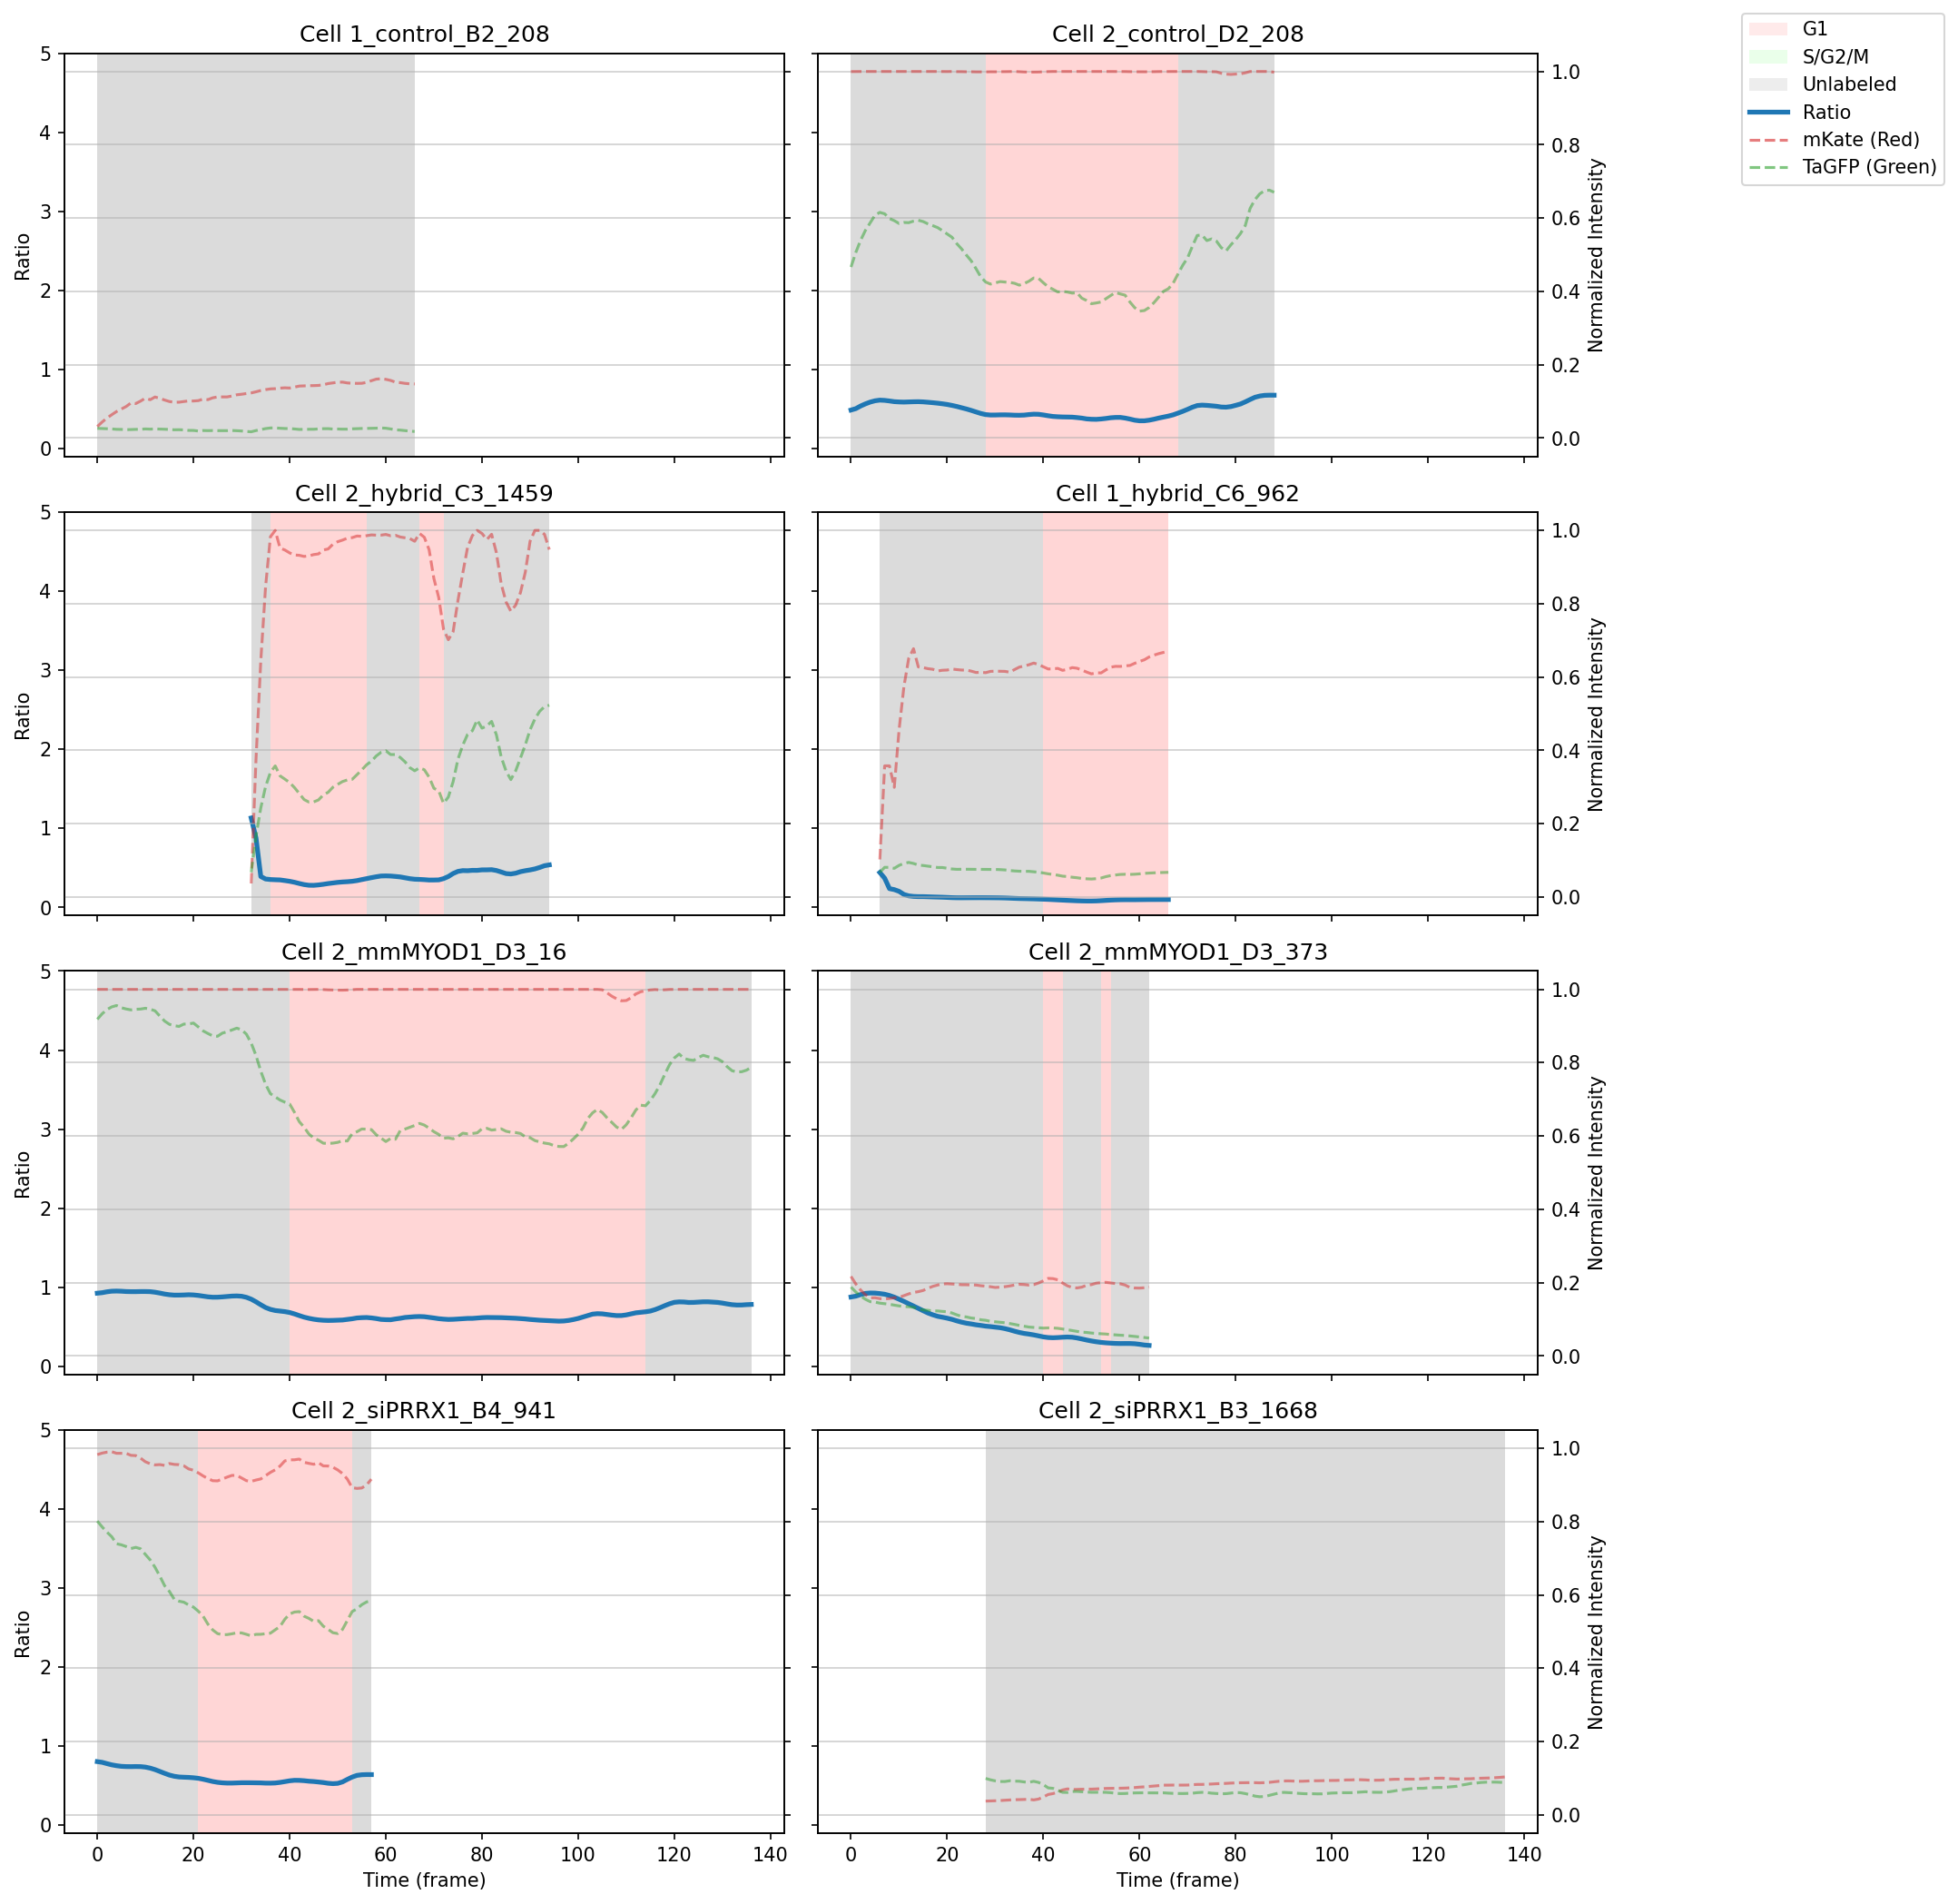

In [25]:
plot_df = df_phases[df_phases['flat_flag'] == False]

phase_colors = {
    'G1': '#ffcccc',  # Light Red
    'G1-S':  '#fff0b3',  # Light Yellow / Gold
    'S/G2/M': '#ccffcc',  # Light Green
    'M':  '#e6ccff',   # Light Purple / Mitosis collapse
    'unlabeled': 'lightgray',
}

sampled_cells = (
    plot_df.groupby('condition')['particle_id']
    .apply(lambda x: np.random.choice(x.unique(), size=min(2, len(x)), replace=False))
    .explode()
    .tolist()
)

num_cells = len(sampled_cells)
num_cols = 2
num_rows = int(np.ceil(num_cells / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 3.5 * num_rows), sharex=True, sharey=True, dpi=150)
axes_flat = axes.flatten()

for idx, cell_id in enumerate(sampled_cells):
    ax = axes_flat[idx]
    row, col = divmod(idx, num_cols)
    
    # Filter and sort data for the current cell
    cdf = plot_df[plot_df['particle_id'] == cell_id].sort_values('frame').reset_index(drop=True)
    
    # 1. Plot the Ratio axis
    ax.plot(cdf['frame'], cdf['ratio_smooth'], label='ratio_smooth', color='tab:blue', linewidth=2.5, zorder=3)
    
    # Generate secondary axis for intensities
    ax2 = ax.twinx()
    ax2.plot(cdf['frame'], cdf['mKate_norm_smooth'], color='tab:red', alpha=0.5, linestyle='--', zorder=2)
    ax2.plot(cdf['frame'], cdf['TaGFP_norm_smooth'], color='tab:green', alpha=0.5, linestyle='--', zorder=2)
    
    # --- FIX 1: FORCE UNIFORM Y-LIMITS FOR TWIN AXES ---
    # Since intensities are normalized, this ensures a true 0-1 perspective across all subplots
    ax2.set_ylim(-0.05, 1.05)
    
    # # --- FIX 2: FORCE BOUNDS ON THE RATIO SIDE TO PREVENT ASYMPTOTIC STRETCHING ---
    ax.set_ylim(-0.1, 5.0) # Adjust 5.0 higher or lower depending on your profile preferences
    
    if col == 1:
        ax2.set_ylabel('Normalized Intensity')
    else:
        # Hide the text labels but leave the right border intact
        # ax2.get_yaxis().set_visible(False)
        ax2.set_yticklabels([])

    # 2. Map the phases visually onto the background using axvspan
    for i in range(len(cdf) - 1):
        start_frame = cdf.loc[i, 'frame']
        end_frame = cdf.loc[i+1, 'frame']
        phase = cdf.loc[i, 'phase_baseline'] # Using baseline column
        
        if phase in phase_colors:
            ax.axvspan(start_frame, end_frame, color=phase_colors[phase], alpha=0.8, lw=0)

    # Aesthetics
    ax.set_title(f'Cell {cell_id}')
    # ax.grid(True, alpha=0.2)
    ax2.grid(True, alpha=0.6)
    ax.set_ylabel('Ratio' if col == 0 else '')
    if row == num_rows - 1: 
        ax.set_xlabel('Time (frame)')

# Clean up empty subplots
for empty_idx in range(num_cells, len(axes_flat)):
    axes_flat[empty_idx].axis('off')

# Custom legend rendering
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=phase_colors['G1'], alpha=0.4, label='G1'),
    Patch(facecolor=phase_colors['S/G2/M'], alpha=0.4, label='S/G2/M'),
    Patch(facecolor=phase_colors['unlabeled'], alpha=0.4, label='Unlabeled'),
    plt.Line2D([0], [0], color='tab:blue', lw=2.5, label='Ratio'),
    plt.Line2D([0], [0], color='tab:red', alpha=0.6, ls='--', label='mKate (Red)'),
    plt.Line2D([0], [0], color='tab:green', alpha=0.6, ls='--', label='TaGFP (Green)')
]
fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.20, 1.0))

plt.tight_layout()
plt.show()

In [ ]:
# S/G2/M --> unlabeled --> M ---- fill unlabeled as S/G2/M (goes until green drops below threshold)
# good cells for mitosis check:
# 2_siPRRX1_B3_2796
# 2_hybrid_C3_1505
# 2_siPRRX1_B3_667

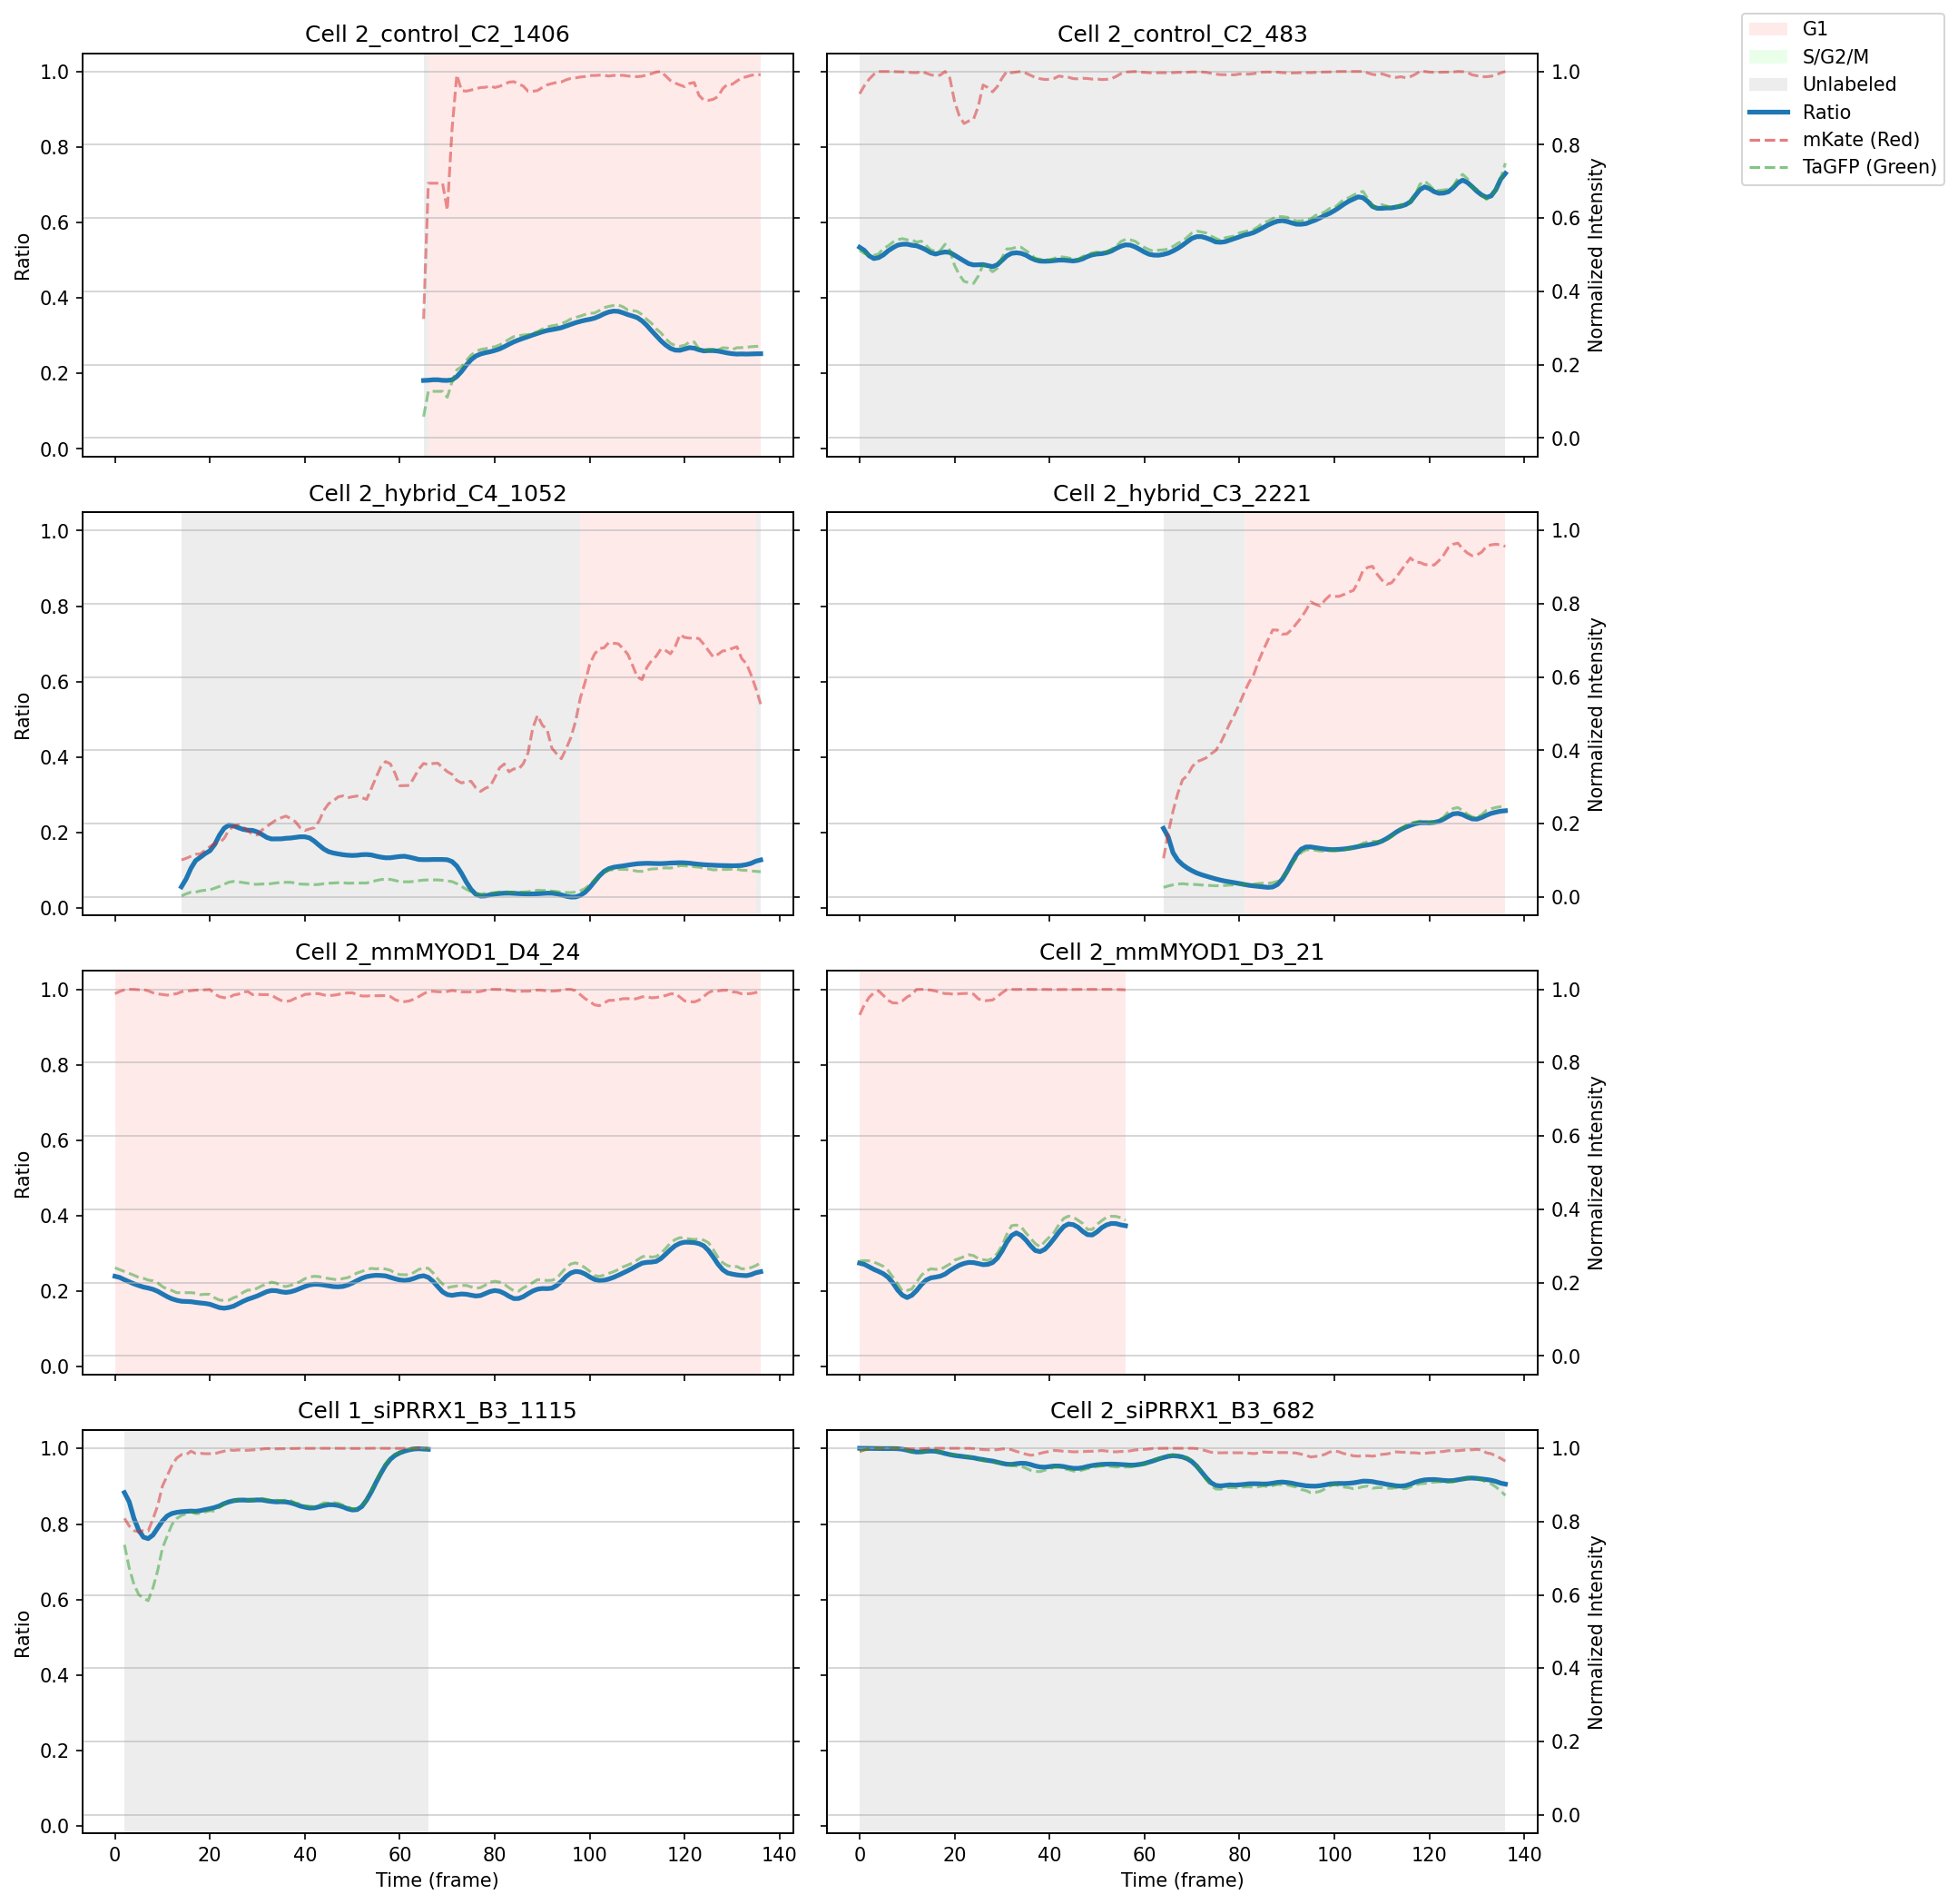

In [119]:
plot_df = df_phases[df_phases['flat_flag'] == True]

phase_colors = {
    'G1': '#ffcccc',  # Light Red
    'G1-S':  '#fff0b3',  # Light Yellow / Gold
    'S/G2/M': '#ccffcc',  # Light Green
    'M':  '#e6ccff',   # Light Purple / Mitosis collapse
    'unlabeled': 'lightgray',
}

sampled_cells1 = (
    plot_df.groupby('condition')['particle_id']
    .apply(lambda x: np.random.choice(x.unique(), size=min(2, len(x)), replace=False))
    .explode()
    .tolist()
)

num_cells = len(sampled_cells1)
num_cols = 2
num_rows = int(np.ceil(num_cells / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 3.5 * num_rows), sharex=True, sharey=True, dpi=150)
axes_flat = axes.flatten()

for idx, cell_id in enumerate(sampled_cells1):
    ax = axes_flat[idx]
    row, col = divmod(idx, num_cols)
    
    # Filter and sort data for the current cell
    cdf = plot_df[plot_df['particle_id'] == cell_id].sort_values('frame').reset_index(drop=True)
    
    # 1. Plot the Ratio axis
    ax.plot(cdf['frame'], cdf['ratio_smooth'], label='ratio_smooth', color='tab:blue', linewidth=2.5, zorder=3)
    
    # Generate secondary axis for intensities
    ax2 = ax.twinx()
    ax2.plot(cdf['frame'], cdf['mKate_norm_smooth'], color='tab:red', alpha=0.5, linestyle='--', zorder=2)
    ax2.plot(cdf['frame'], cdf['TaGFP_norm_smooth'], color='tab:green', alpha=0.5, linestyle='--', zorder=2)
    
    # --- FIX 1: FORCE UNIFORM Y-LIMITS FOR TWIN AXES ---
    # Since intensities are normalized, this ensures a true 0-1 perspective across all subplots
    ax2.set_ylim(-0.05, 1.05)
    
    # # --- FIX 2: FORCE BOUNDS ON THE RATIO SIDE TO PREVENT ASYMPTOTIC STRETCHING ---
    # ax.set_ylim(-0.1, 5.0) # Adjust 5.0 higher or lower depending on your profile preferences
    
    if col == 1:
        ax2.set_ylabel('Normalized Intensity')
    else:
        # Hide the text labels but leave the right border intact
        # ax2.get_yaxis().set_visible(False)
        ax2.set_yticklabels([])

    # 2. Map the phases visually onto the background using axvspan
    for i in range(len(cdf) - 1):
        start_frame = cdf.loc[i, 'frame']
        end_frame = cdf.loc[i+1, 'frame']
        phase = cdf.loc[i, 'phase_baseline'] # Using baseline column
        
        if phase in phase_colors:
            ax.axvspan(start_frame, end_frame, color=phase_colors[phase], alpha=0.4, lw=0)

    # Aesthetics
    ax.set_title(f'Cell {cell_id}')
    # ax.grid(True, alpha=0.2)
    ax2.grid(True, alpha=0.6)
    ax.set_ylabel('Ratio' if col == 0 else '')
    if row == num_rows - 1: 
        ax.set_xlabel('Time (frame)')

# Clean up empty subplots
for empty_idx in range(num_cells, len(axes_flat)):
    axes_flat[empty_idx].axis('off')

# Custom legend rendering
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=phase_colors['G1'], alpha=0.4, label='G1'),
    Patch(facecolor=phase_colors['S/G2/M'], alpha=0.4, label='S/G2/M'),
    Patch(facecolor=phase_colors['unlabeled'], alpha=0.4, label='Unlabeled'),
    plt.Line2D([0], [0], color='tab:blue', lw=2.5, label='Ratio'),
    plt.Line2D([0], [0], color='tab:red', alpha=0.6, ls='--', label='mKate (Red)'),
    plt.Line2D([0], [0], color='tab:green', alpha=0.6, ls='--', label='TaGFP (Green)')
]
fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.20, 1.0))

plt.tight_layout()
plt.show()

# Visualize

## check flat cells

In [85]:
# look at how many "flat" cells
print(df_phases.drop_duplicates('particle_id')['flat_flag'].value_counts())


flat = df_phases[df_phases['flat_flag'] == True]
print(flat.groupby('condition')['particle_id'].nunique())

flat['phase_final2'].value_counts(normalize=True, dropna=False)

flat_flag
False    10206
True      3053
Name: count, dtype: int64
condition
control    1141
hybrid      863
mmMYOD1     520
siPRRX1     529
Name: particle_id, dtype: int64


phase_final2
G1           0.868094
unlabeled    0.131385
S/G2/M       0.000520
Name: proportion, dtype: float64

In [53]:
flat.head()

,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,ratio_smooth,flat_flag,phase_raw,phase_final,phase_smoothed,phase_final2,vmin,vmax,vmid,small_range
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,0.556552,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,0.551576,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,0.542273,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,0.534915,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,0.530020,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN


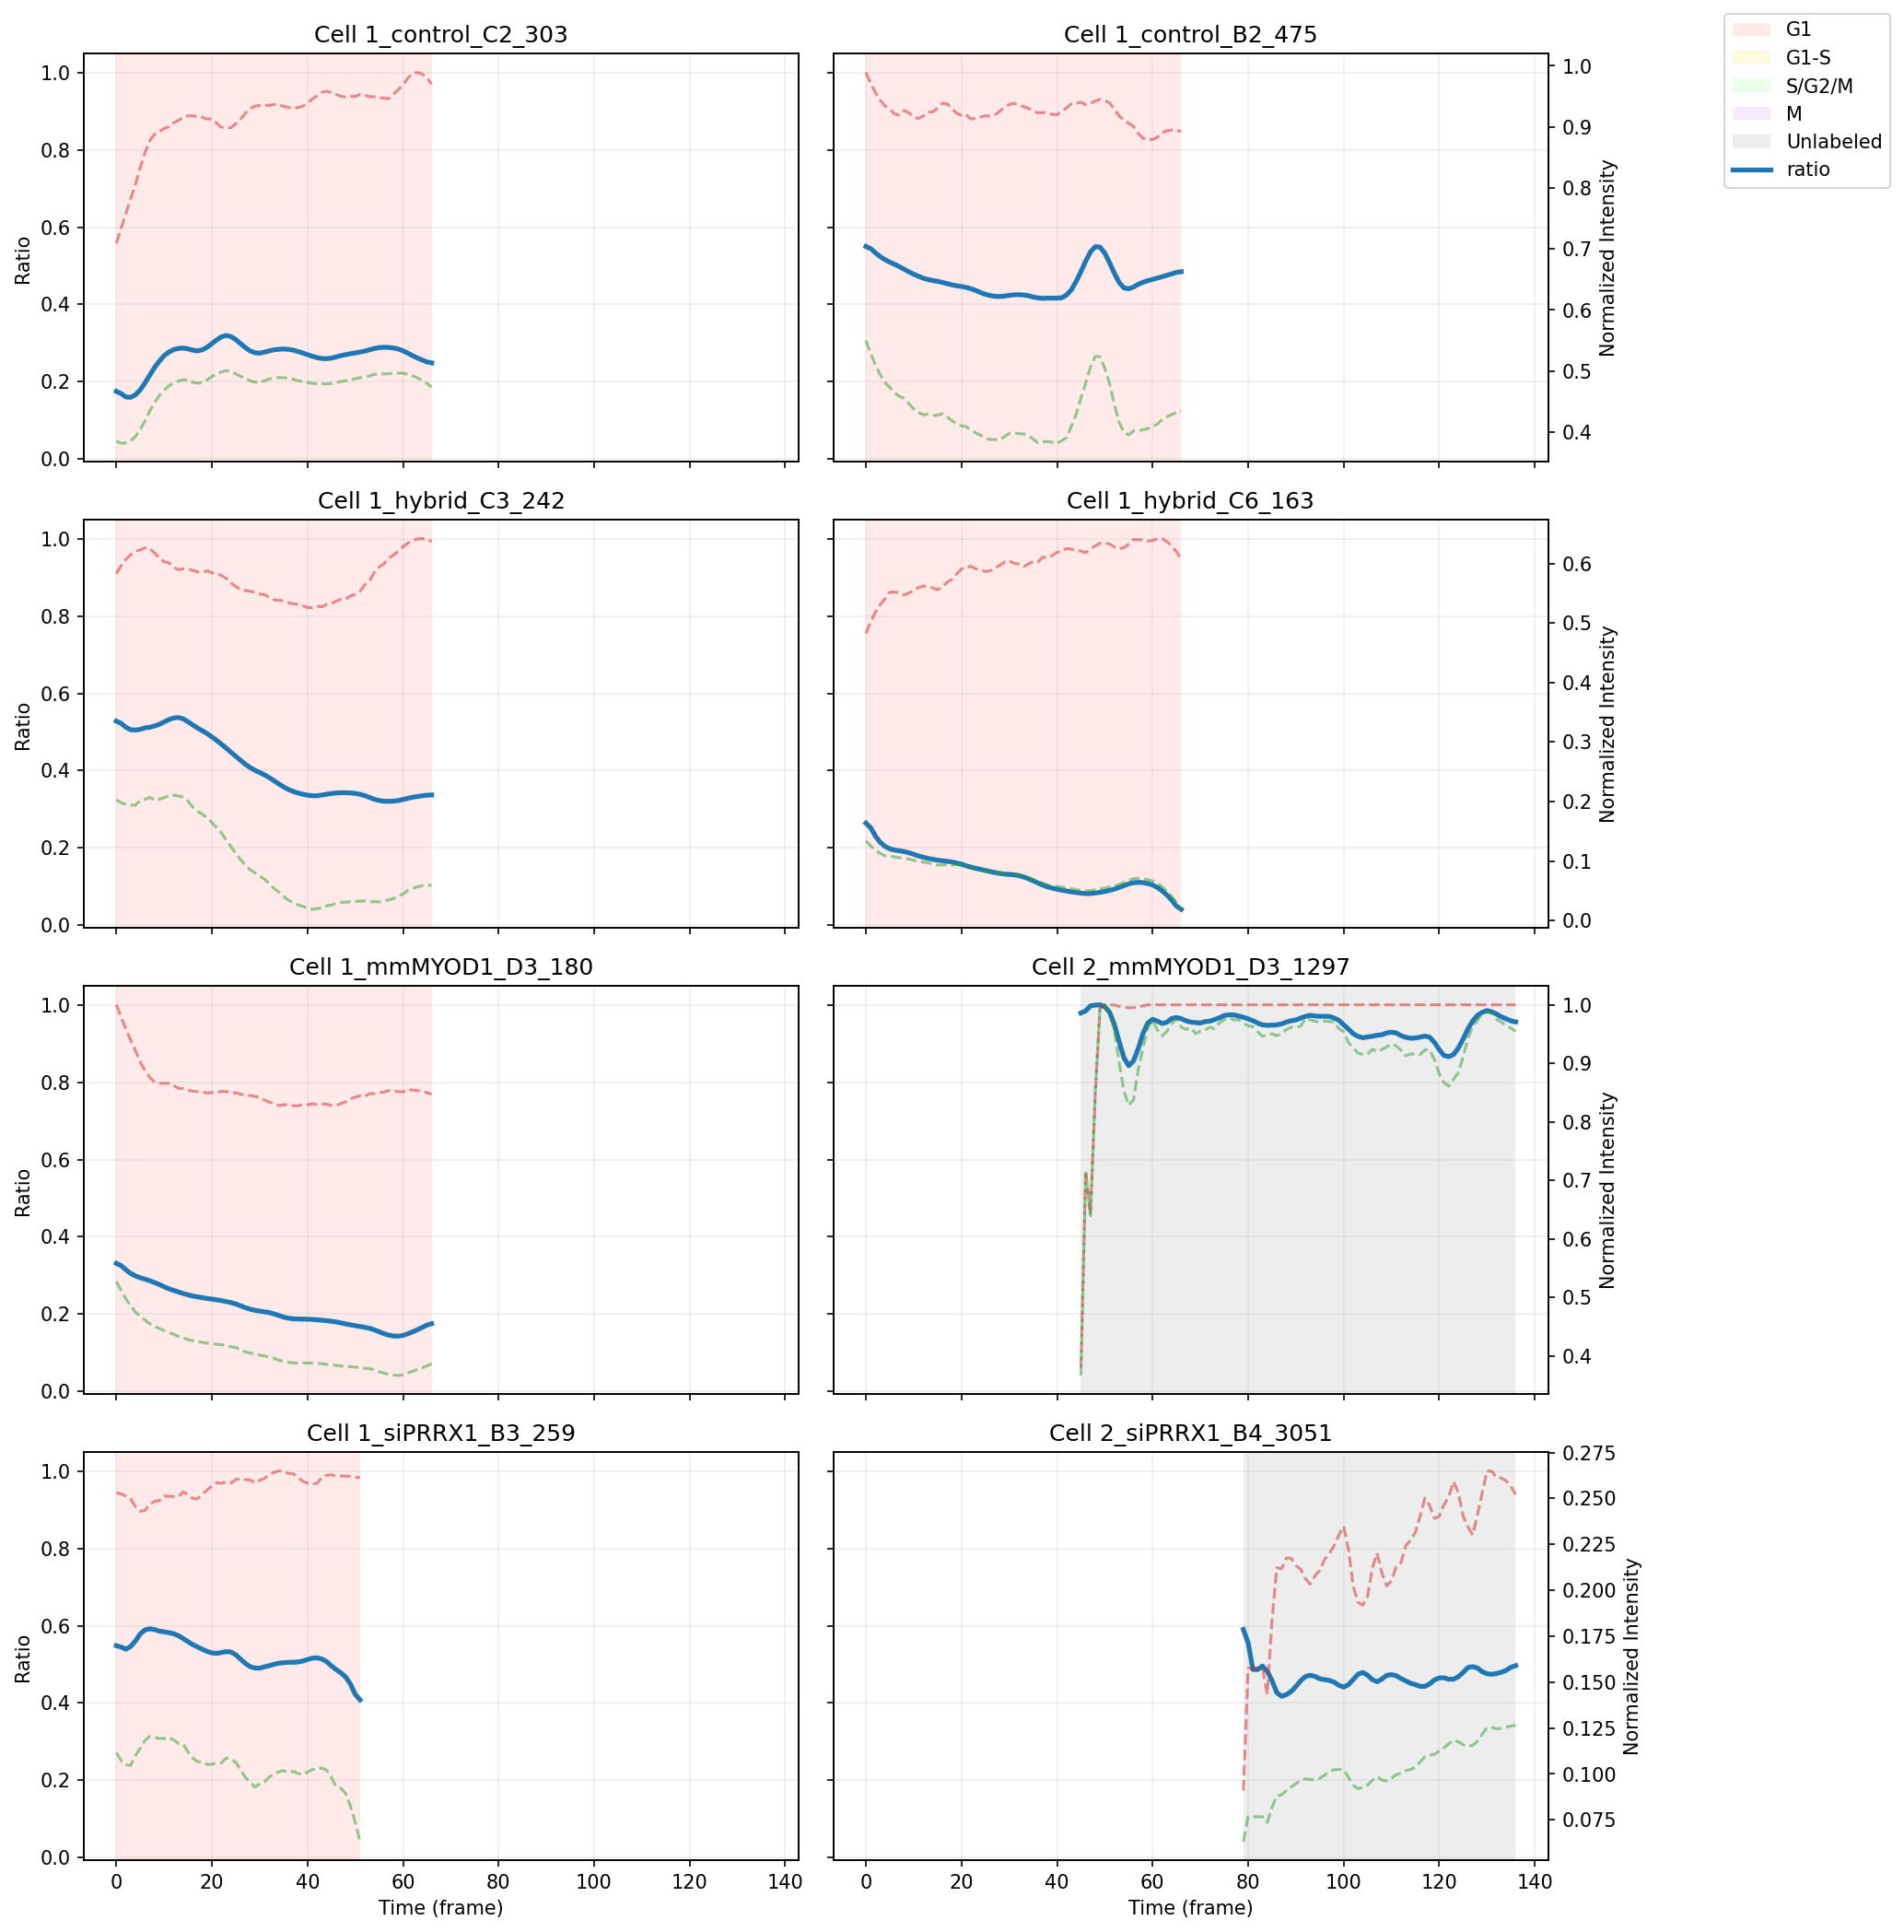

In [86]:
phase_colors = {
    'G1': '#ffcccc',  # Light Red
    'G1-S':  '#fff0b3',  # Light Yellow / Gold
    'S/G2/M': '#ccffcc',  # Light Green
    'M':  '#e6ccff',   # Light Purple / Mitosis collapse
    'unlabeled': 'lightgray',
}

sampled_cells = (
    flat.groupby('condition')['particle_id']
    .apply(lambda x: np.random.choice(x.unique(), size=min(2, len(x)), replace=False))
    .explode()
    .tolist()
)

num_cells = len(sampled_cells)
num_cols = 2

num_rows = int(np.ceil(num_cells / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 3.5 * num_rows), sharex=True, sharey=True, dpi=150)
axes_flat = axes.flatten()

# fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True, dpi=150)

for idx, cell_id in enumerate(sampled_cells):
    # row, col = divmod(idx, 2)
    # ax = axes[row, col]
    
    ax = axes_flat[idx]
    row, col = divmod(idx, num_cols)
    
    # Filter and sort data for the current cell
    cdf = flat[flat['particle_id'] == cell_id].sort_values('frame').reset_index(drop=True)
    
    # 1. Plot the FUCCI angle and individual channels
    ax.plot(cdf['frame'], cdf['ratio_smooth'], label='ratio_smooth', color='tab:blue', linewidth=2.5, zorder=3)
    
    ax2 = ax.twinx()
    ax2.plot(cdf['frame'], cdf['mKate_norm_smooth'], color='tab:red', alpha=0.5, linestyle='--', zorder=2)
    ax2.plot(cdf['frame'], cdf['TaGFP_norm_smooth'], color='tab:green', alpha=0.5, linestyle='--', zorder=2)
    
    if col == 1:
        ax2.set_ylabel('Normalized Intensity')
    else:
        ax2.get_yaxis().set_visible(False)

    # 2. Map the phases visually onto the background using axvspan
    # Loop through the track frame-by-frame to shade the background
    for i in range(len(cdf) - 1):
        start_frame = cdf.loc[i, 'frame']
        end_frame = cdf.loc[i+1, 'frame']
        phase = cdf.loc[i, 'phase_smoothed']
        
        if phase in phase_colors:
            ax.axvspan(start_frame, end_frame, color=phase_colors[phase], alpha=0.4, lw=0)

    # Aesthetics
    ax.set_title(f'Cell {cell_id}')
    ax.grid(True, alpha=0.2)
    ax.set_ylabel('Ratio' if col == 0 else '')
    if row == num_rows - 1: 
        ax.set_xlabel('Time (frame)')
    # if row == 2: ax.set_xlabel('Time (frame)')

# Create a custom legend for the background phases
for empty_idx in range(num_cells, len(axes_flat)):
    axes_flat[empty_idx].axis('off')


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=phase_colors['G1'], alpha=0.4, label='G1'),
    Patch(facecolor=phase_colors['G1-S'], alpha=0.4, label='G1-S'),
    Patch(facecolor=phase_colors['S/G2/M'], alpha=0.4, label='S/G2/M'),
    Patch(facecolor=phase_colors['M'], alpha=0.4, label='M'),
    Patch(facecolor=phase_colors['unlabeled'], alpha=0.4, label='Unlabeled'),
    plt.Line2D([0], [0], color='tab:blue', lw=2.5, label='ratio')
]
fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()
plt.show()

In [91]:
# look at how many "flat" cells
print(df_phases.drop_duplicates('particle_id')['flat_flag'].value_counts())


# filter for non-flat cells
not_flat = df_phases[df_phases['flat_flag'] == False]
print(not_flat.groupby('condition')['particle_id'].nunique())

not_flat['phase_smoothed'].value_counts(normalize=True, dropna=False)

flat_flag
False    10206
True      3053
Name: count, dtype: int64
condition
control    1977
hybrid     3315
mmMYOD1    1249
siPRRX1    3665
Name: particle_id, dtype: int64


phase_smoothed
G1           0.566519
unlabeled    0.216966
S/G2/M       0.103728
G1-S         0.083377
M            0.029410
Name: proportion, dtype: float64

In [54]:
not_flat.head()

,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,ratio_smooth,flat_flag,phase_raw,phase_final,phase_smoothed,phase_final2,vmin,vmax,vmid,small_range
0,0,control,B2,1.0,101.0,1_control_B2_101,0.0,104.0,0.086292,0.063671,...,1.121391,False,unassigned,unlabeled,unlabeled,unlabeled,0.193885,1.934063,1.063974,0.348035
1,1,control,B2,1.0,101.0,1_control_B2_101,1.0,100.0,0.230846,0.062368,...,0.988879,False,unassigned,unlabeled,unlabeled,unlabeled,0.193885,1.934063,1.063974,0.348035
2,2,control,B2,1.0,101.0,1_control_B2_101,2.0,97.0,0.406342,0.061476,...,0.752009,False,unassigned,unlabeled,unlabeled,unlabeled,0.193885,1.934063,1.063974,0.348035
3,3,control,B2,1.0,101.0,1_control_B2_101,3.0,101.0,0.555607,0.058541,...,0.627534,False,unassigned,unlabeled,unlabeled,unlabeled,0.193885,1.934063,1.063974,0.348035
4,4,control,B2,1.0,101.0,1_control_B2_101,4.0,103.0,0.624183,0.060153,...,0.556448,False,unassigned,unlabeled,unlabeled,unlabeled,0.193885,1.934063,1.063974,0.348035


In [68]:
not_flat['ratio_smooth'].describe()

count    919034.000000
mean         19.555894
std         655.090336
min           0.000000
25%           0.228087
50%           0.447736
75%           0.786561
max      100000.000000
Name: ratio_smooth, dtype: float64

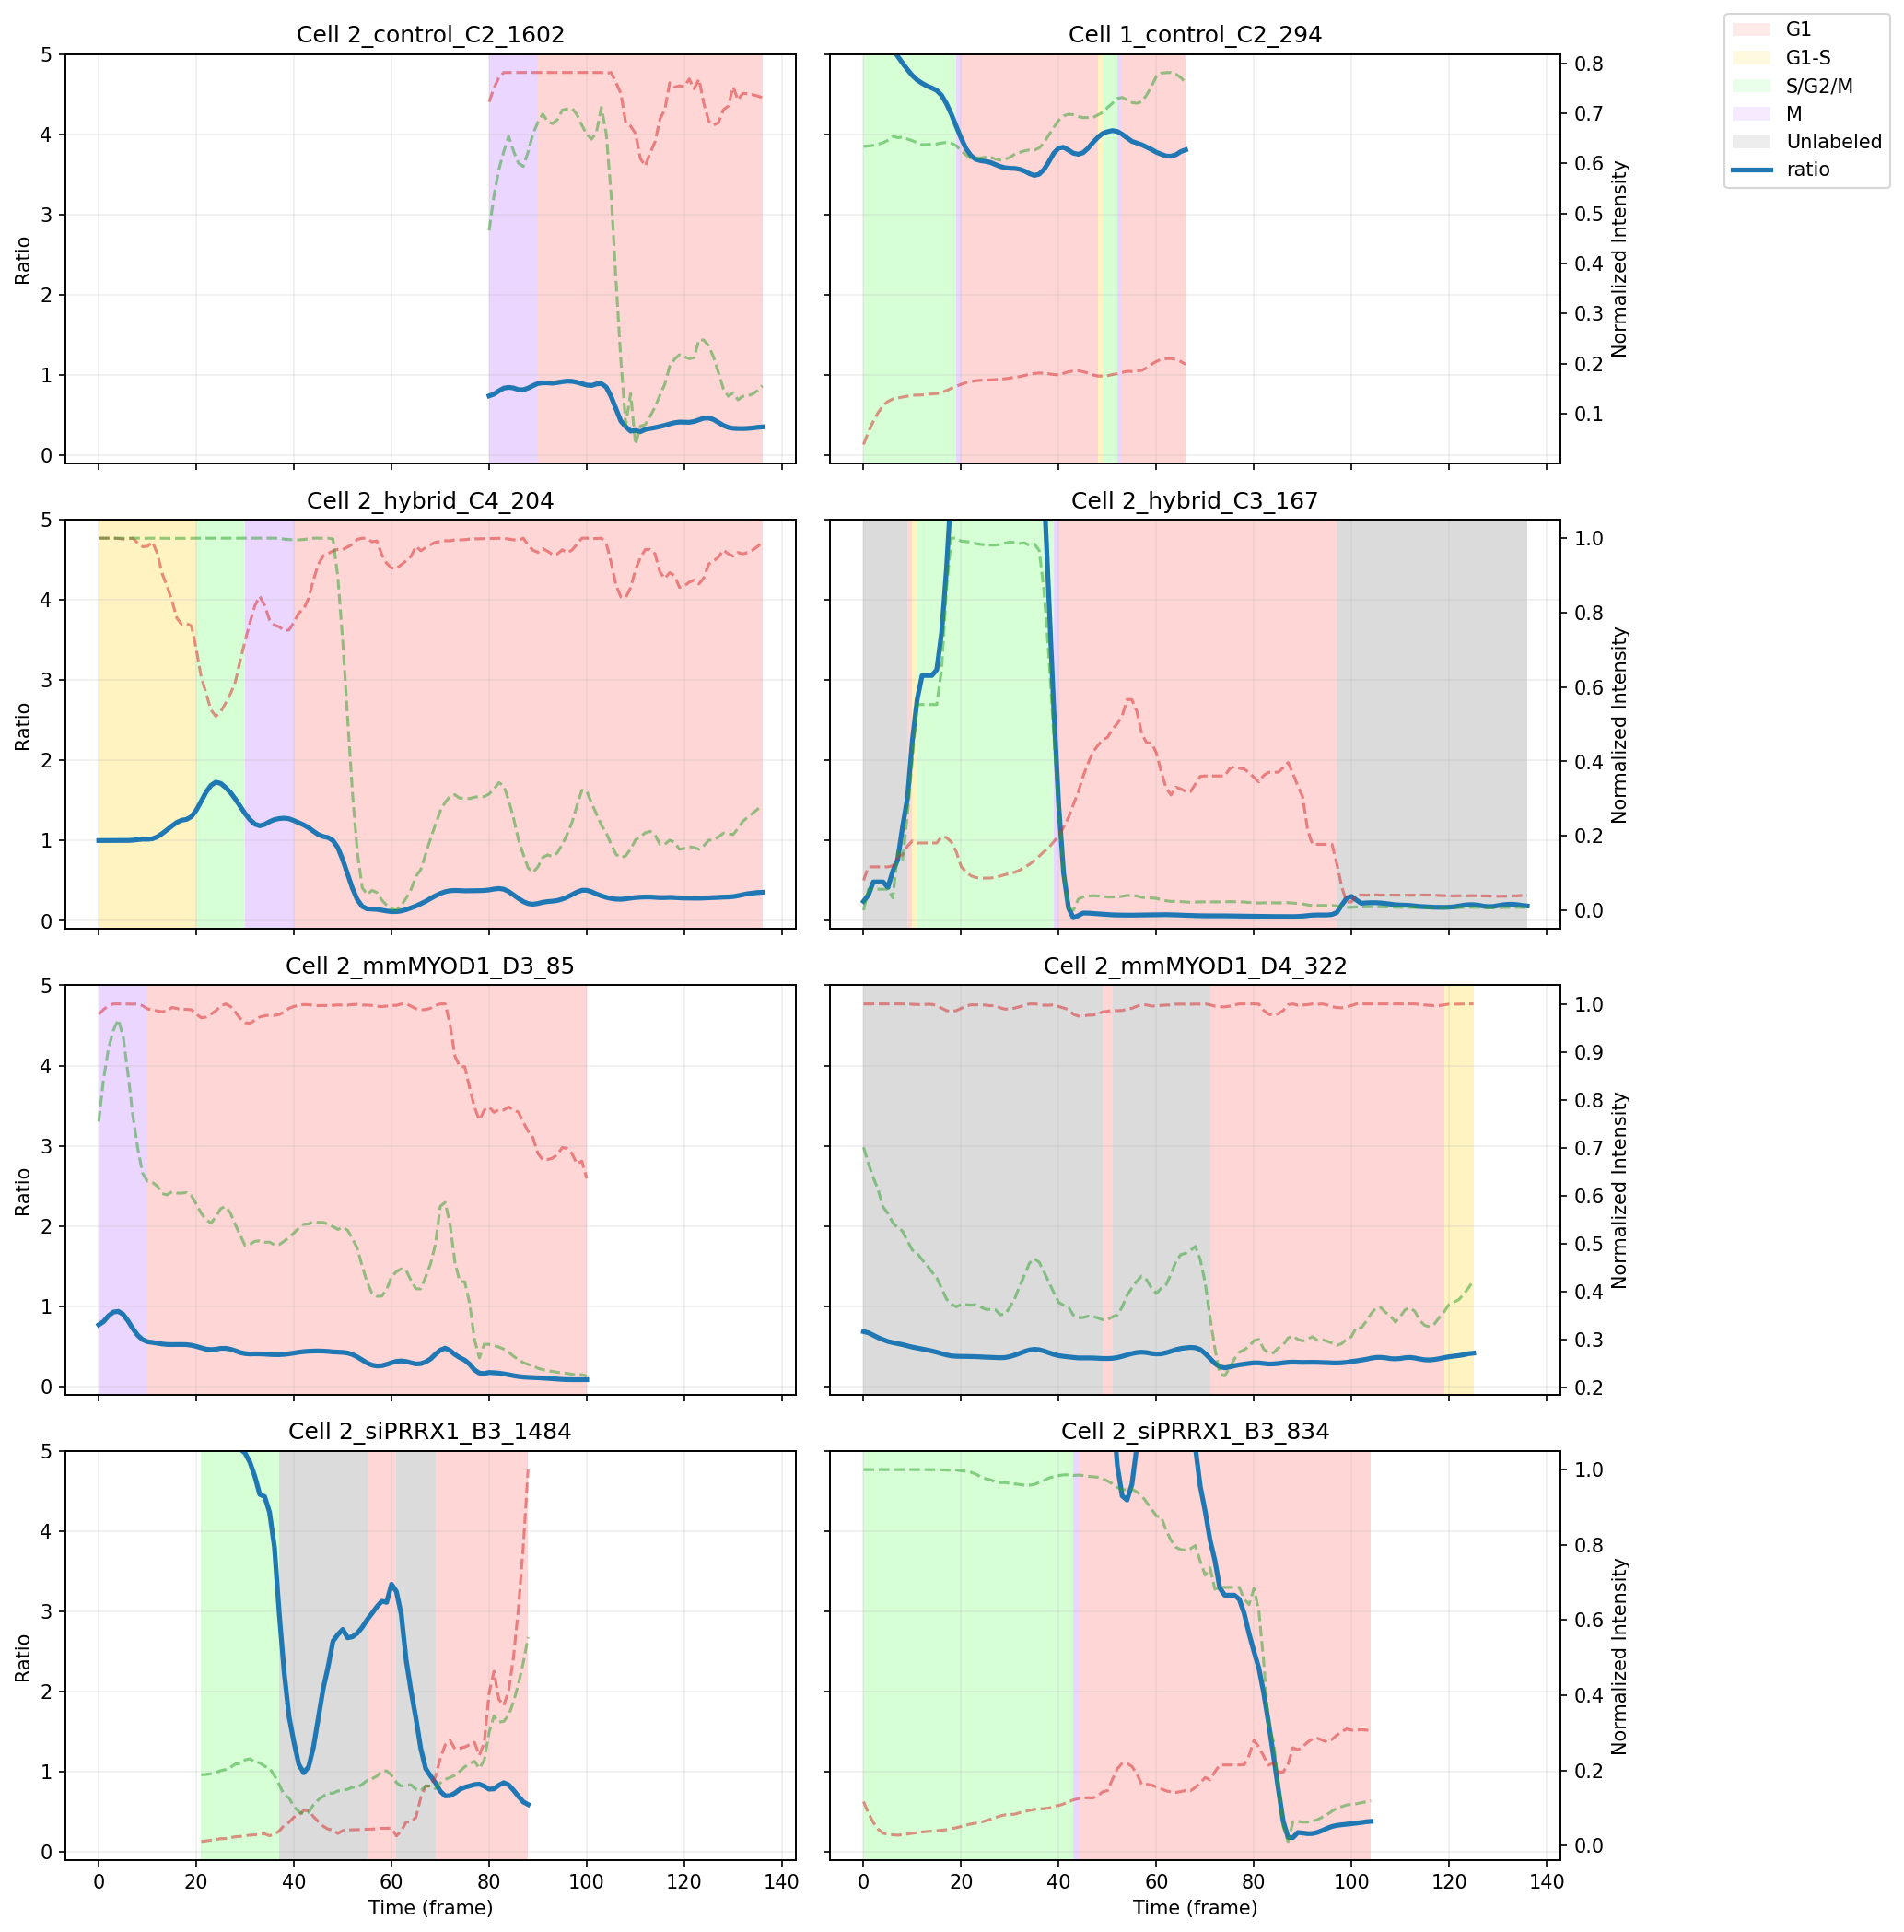

In [92]:
phase_colors = {
    'G1': '#ffcccc',  # Light Red
    'G1-S':  '#fff0b3',  # Light Yellow / Gold
    'S/G2/M': '#ccffcc',  # Light Green
    'M':  '#e6ccff',   # Light Purple / Mitosis collapse
    'unlabeled': 'lightgray',
}

sampled_cells = (
    not_flat.groupby('condition')['particle_id']
    .apply(lambda x: np.random.choice(x.unique(), size=min(2, len(x)), replace=False))
    .explode()
    .tolist()
)

num_cells = len(sampled_cells)
num_cols = 2

num_rows = int(np.ceil(num_cells / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 3.5 * num_rows), sharex=True, sharey=True, dpi=150)
axes_flat = axes.flatten()

for idx, cell_id in enumerate(sampled_cells):
    
    ax = axes_flat[idx]
    row, col = divmod(idx, num_cols)
    
    # Filter and sort data for the current cell
    cdf = not_flat[not_flat['particle_id'] == cell_id].sort_values('frame').reset_index(drop=True)
    
    # 1. Plot the FUCCI angle and individual channels
    ax.plot(cdf['frame'], cdf['ratio_smooth'], label='ratio_smooth', color='tab:blue', linewidth=2.5, zorder=3)
    
    ax2 = ax.twinx()
    ax2.plot(cdf['frame'], cdf['mKate_norm_smooth'], color='tab:red', alpha=0.5, linestyle='--', zorder=2)
    ax2.plot(cdf['frame'], cdf['TaGFP_norm_smooth'], color='tab:green', alpha=0.5, linestyle='--', zorder=2)
    
    if col == 1:
        ax2.set_ylabel('Normalized Intensity')
    else:
        ax2.get_yaxis().set_visible(False)

    # 2. Map the phases visually onto the background using axvspan
    # Loop through the track frame-by-frame to shade the background
    for i in range(len(cdf) - 1):
        start_frame = cdf.loc[i, 'frame']
        end_frame = cdf.loc[i+1, 'frame']
        phase = cdf.loc[i, 'phase_final2']
        
        if phase in phase_colors:
            ax.axvspan(start_frame, end_frame, color=phase_colors[phase], alpha=0.8, lw=0)

    # Aesthetics
    ax.set_title(f'Cell {cell_id}')
    ax.grid(True, alpha=0.2)
    ax.set_ylabel('Ratio' if col == 0 else '')
    if row == num_rows - 1: 
        ax.set_xlabel('Time (frame)')

    ax.set_ylim(-0.1, 5)

# Create a custom legend for the background phases
for empty_idx in range(num_cells, len(axes_flat)):
    axes_flat[empty_idx].axis('off')


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=phase_colors['G1'], alpha=0.4, label='G1'),
    Patch(facecolor=phase_colors['G1-S'], alpha=0.4, label='G1-S'),
    Patch(facecolor=phase_colors['S/G2/M'], alpha=0.4, label='S/G2/M'),
    Patch(facecolor=phase_colors['M'], alpha=0.4, label='M'),
    Patch(facecolor=phase_colors['unlabeled'], alpha=0.4, label='Unlabeled'),
    plt.Line2D([0], [0], color='tab:blue', lw=2.5, label='ratio')
]
fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()
plt.show()

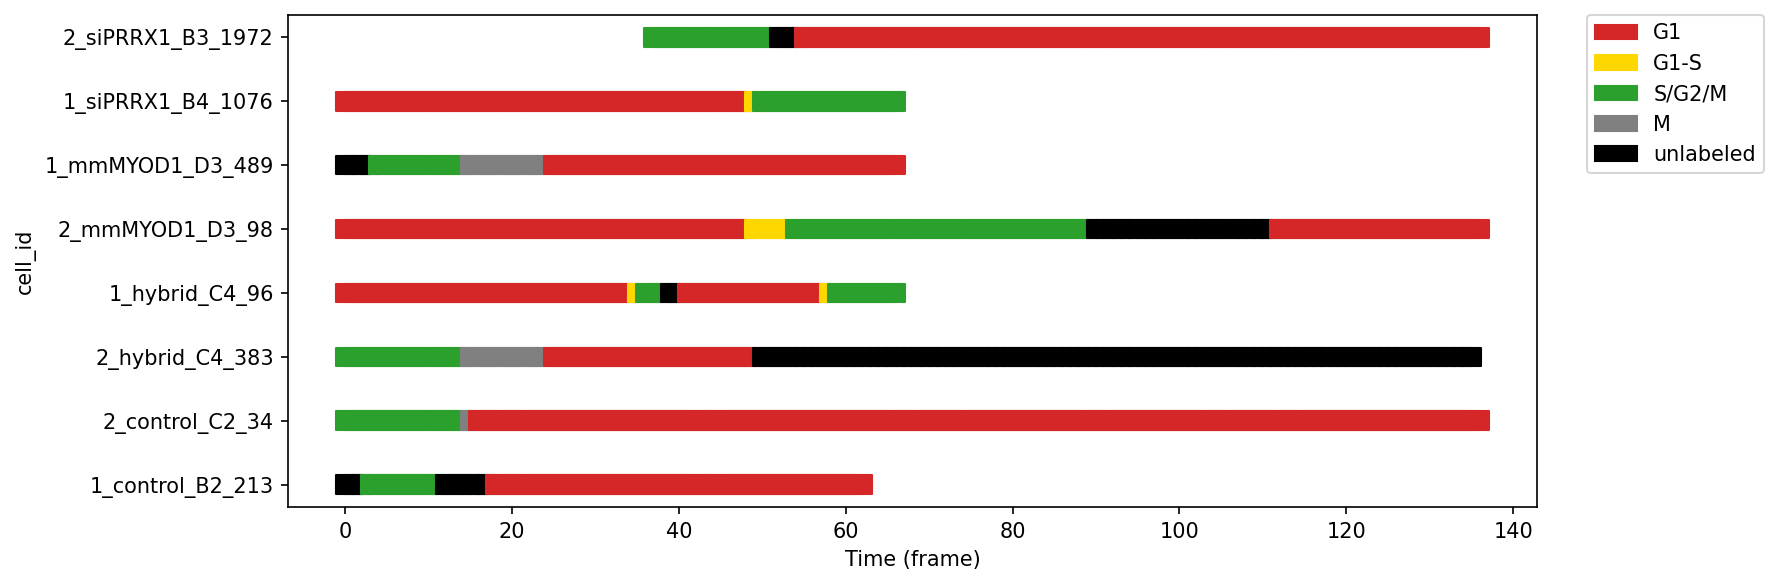

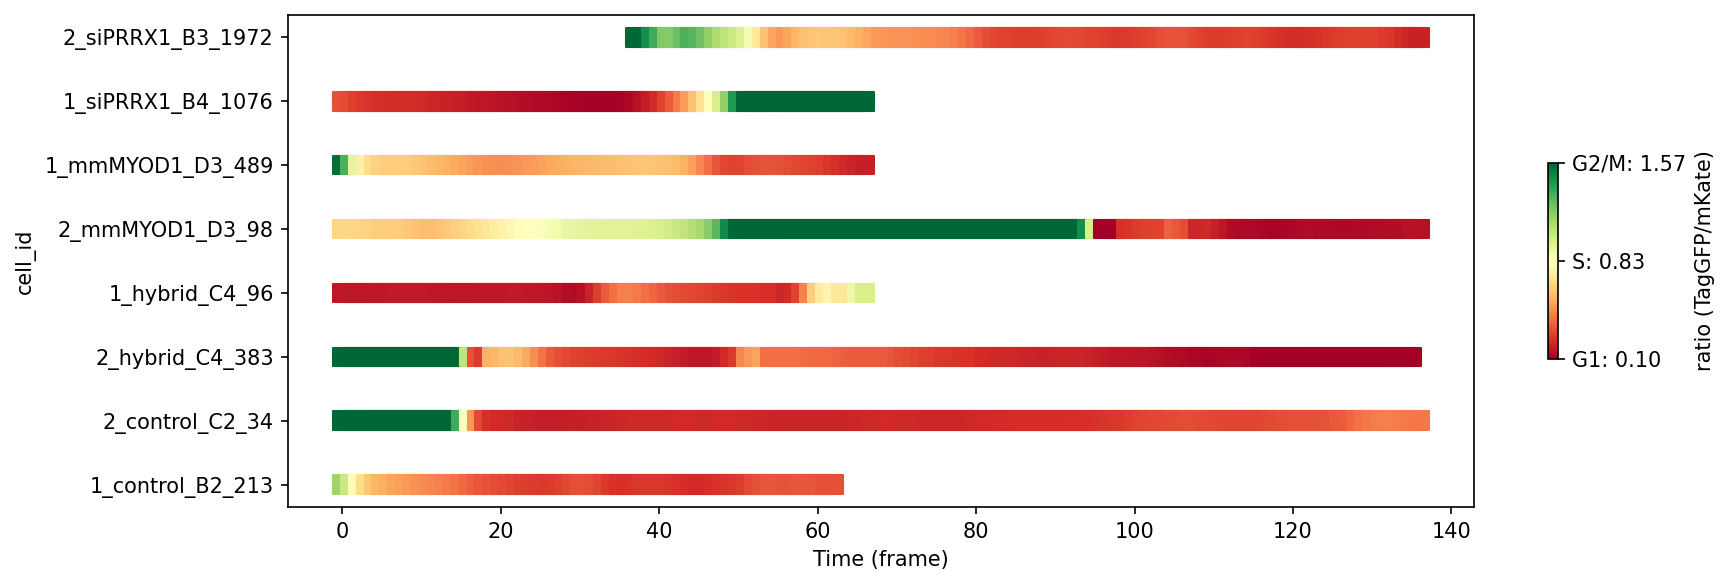

In [22]:
# sampled_cells = np.random.choice(df_phases['particle_id'].unique(), size=6, replace=False)

sampled_cells = (
    not_flat.groupby('condition')['particle_id']
    .apply(lambda x: np.random.choice(x.unique(), size=min(2, len(x)), replace=False))
    .explode()
    .tolist()
)

# Phase assignments
phase_colors = {
    'G1': 'tab:red',
    'G1-S': 'gold',
    'S/G2/M': 'tab:green',
    'M': 'gray',
    'unlabeled': 'black',
}
phase_order = ['G1', 'G1-S', 'S/G2/M', 'M', 'unlabeled']

fig, ax = plt.subplots(figsize=(12, 4))

for i, cell_id in enumerate(sampled_cells):
    cdf = df_phases[df_phases['particle_id'] == cell_id].sort_values('frame')
    colors = cdf['phase_final2'].map(phase_colors)
    ax.scatter(
        cdf['frame'],
        np.full_like(cdf['frame'], i, dtype=float),
        c=colors,
        s=80,
        marker='s',
    )

ax.set_yticks(range(len(sampled_cells)))
ax.set_yticklabels(sampled_cells)
ax.set_xlabel('Time (frame)')
ax.set_ylabel('cell_id')

legend_patches = [Patch(color=phase_colors[ph], label=ph) for ph in phase_order]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.04, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

# Ratios for same cells
cmap = plt.get_cmap('RdYlGn')
vmin = df_phases['ratio_smooth'].quantile(0.1)
vmax = df_phases['ratio_smooth'].quantile(0.9)
vmid = 0.5 * (vmin + vmax)

labels = [
    f"G1: {vmin:.2f}",
    f"S: {vmid:.2f}",
    f"G2/M: {vmax:.2f}",
]

fig, ax = plt.subplots(figsize=(12, 4))

for i, cell_id in enumerate(sampled_cells):
    cdf = df_phases[df_phases['particle_id'] == cell_id].sort_values('frame')
    ax.scatter(
        cdf['frame'],
        np.full_like(cdf['frame'], i, dtype=float),  # y-position: cell number
        c=cdf['ratio_smooth'],
        s=80,
        marker='s',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        # edgecolor='k'
    )

ax.set_yticks(range(len(sampled_cells)))
ax.set_yticklabels(sampled_cells)
ax.set_xlabel('Time (frame)')
ax.set_ylabel('cell_id')

# Step 5: Add Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(
    sm,
    ax=ax,
    label='ratio (TagGFP/mKate)',
    shrink=0.4,
    ticks=[vmin, vmid, vmax],
)
cbar.ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

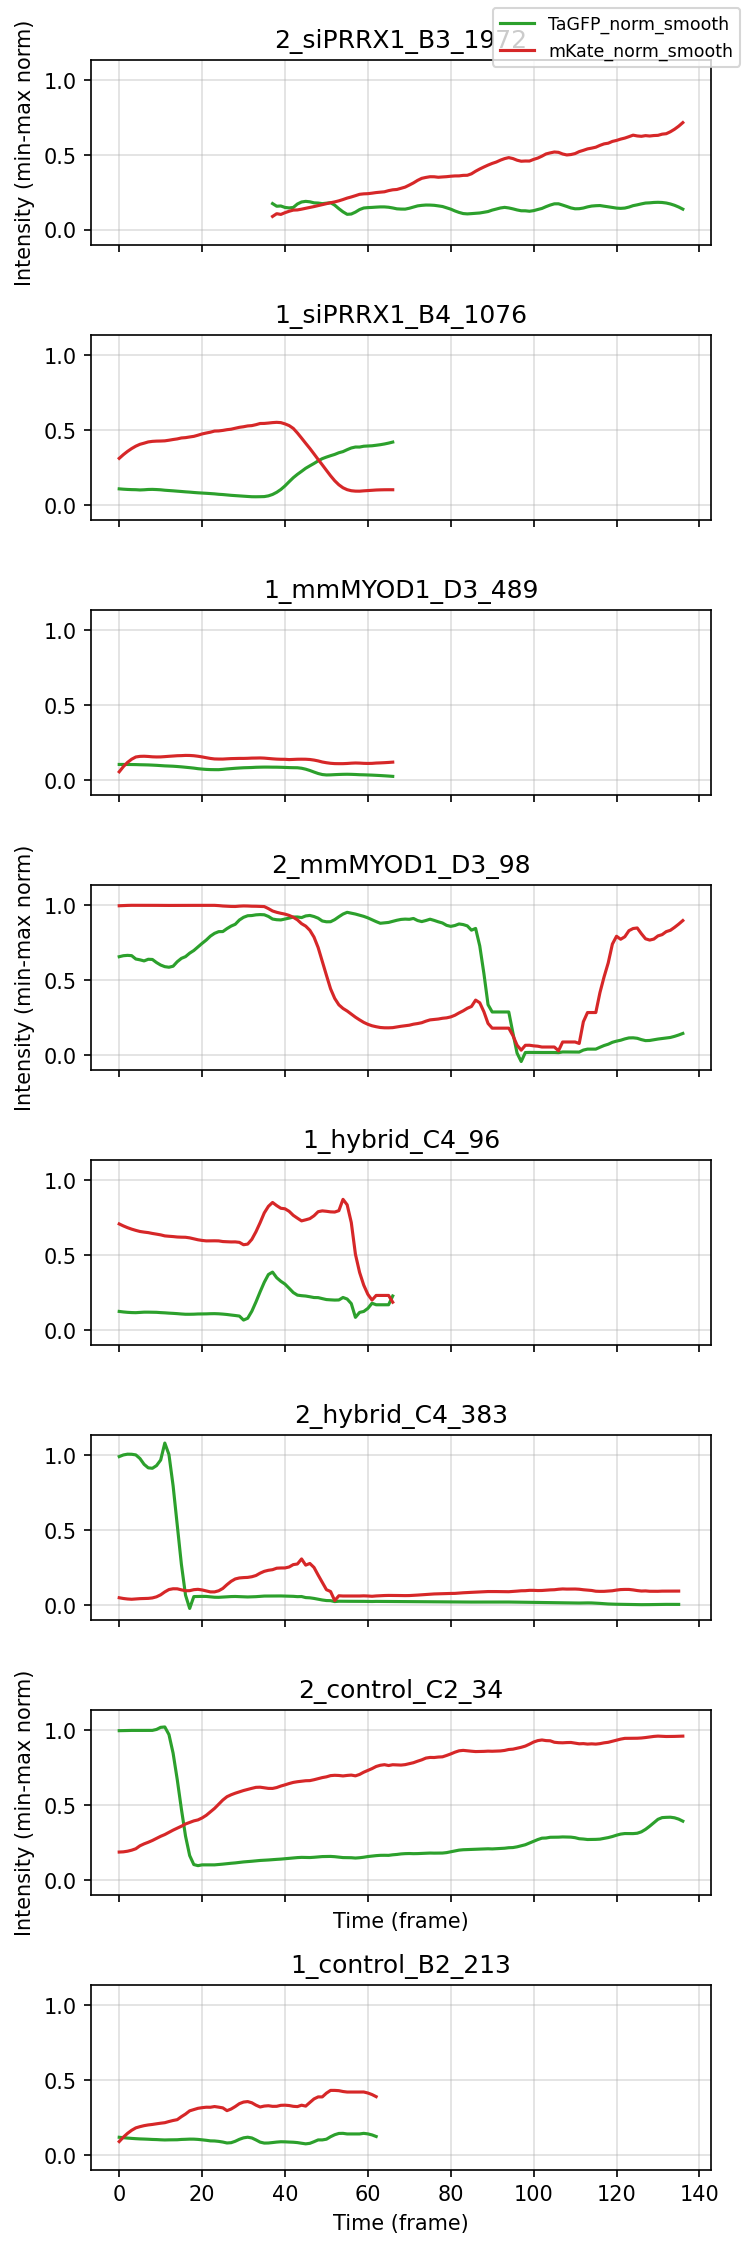

In [31]:
fig, axes = plt.subplots(8, 1, figsize=(5, 15), sharex=True, sharey=True)
axes = axes.flatten()

# sampled_cells.reverse()

for idx, cell_id in enumerate(sampled_cells):
    ax = axes[idx]
    cdf = df_phases[df_phases['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(cdf['frame'], cdf['TaGFP_norm_smooth'], label='TaGFP_norm_smooth', color='tab:green')
    ax.plot(cdf['frame'], cdf['mKate_norm_smooth'], label='mKate_norm_smooth', color='tab:red')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    ax.set_xlabel('Time (frame)' if idx // n_cols == n_rows - 1 else '')
    ax.set_ylabel('Intensity (min-max norm)' if idx % n_cols == 0 else '')

for ax in axes[len(noisy_cells):]:
    ax.set_visible(False)
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

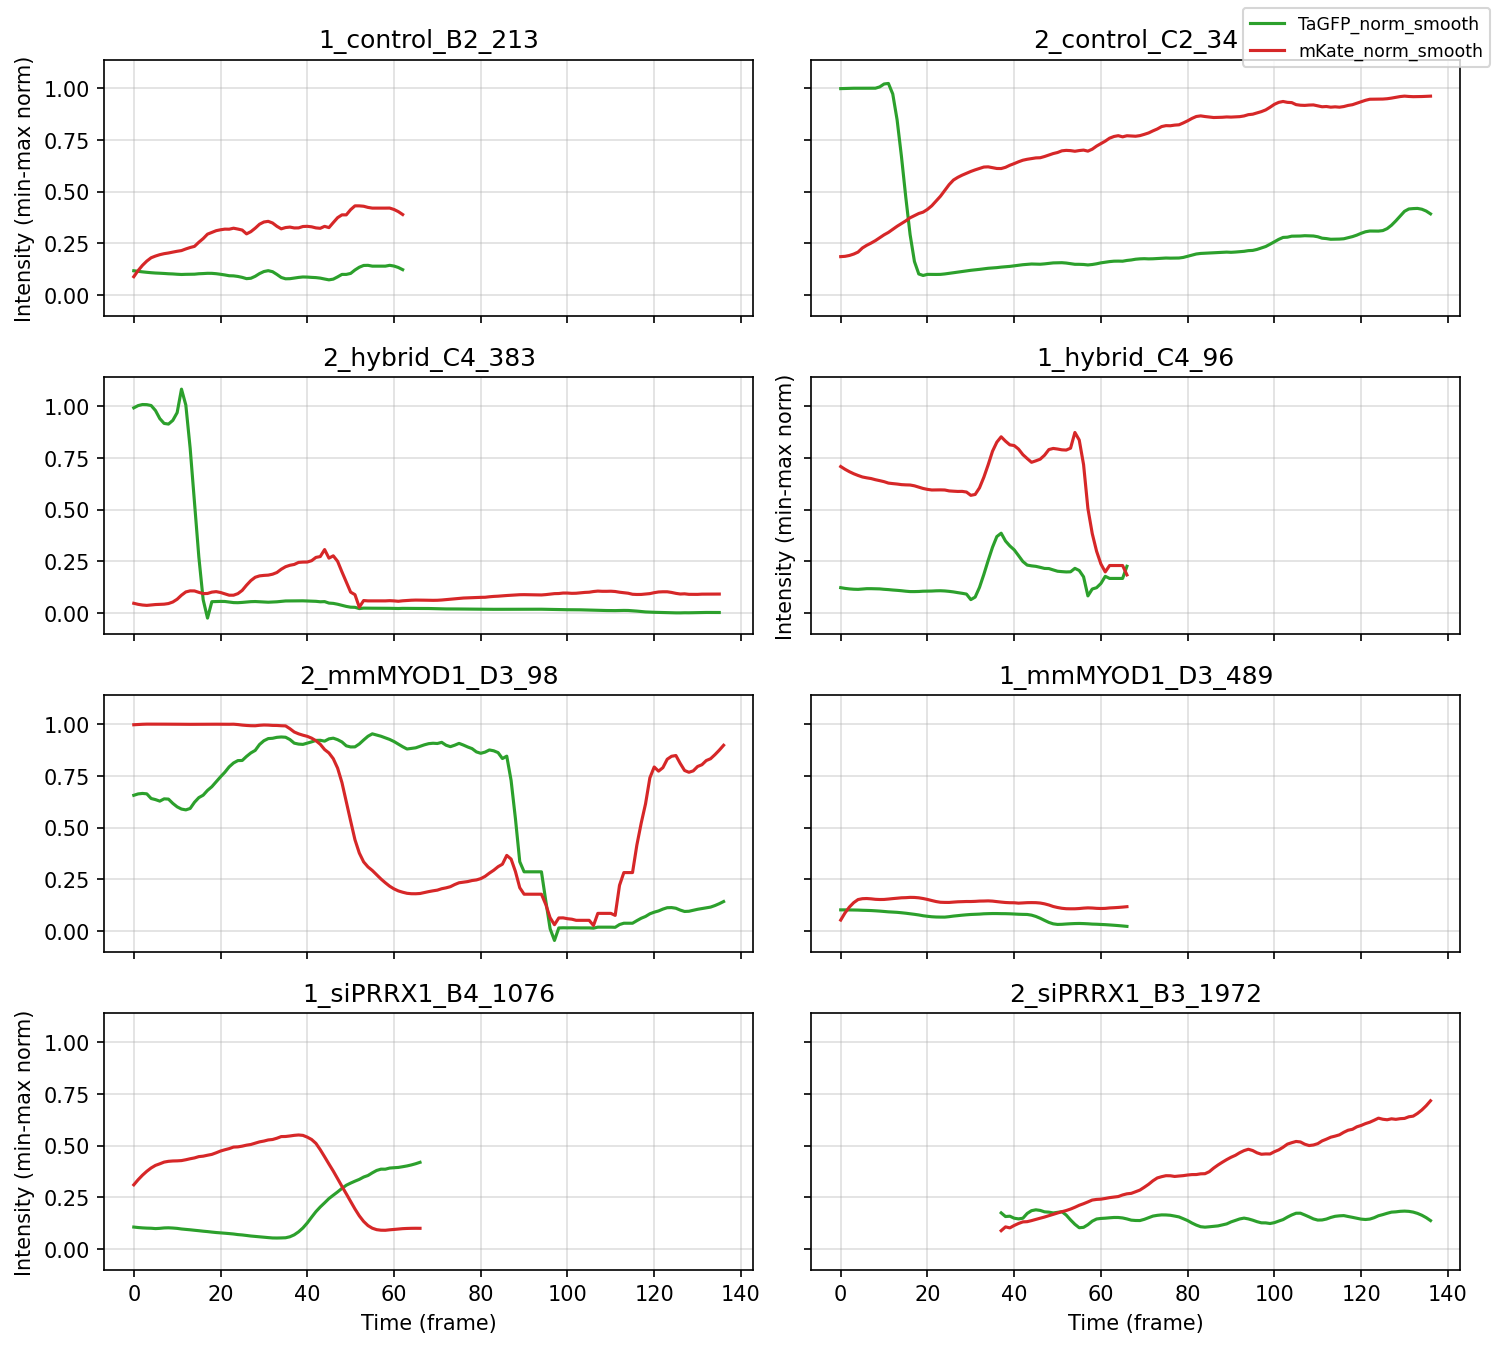

In [27]:
fig, axes = plt.subplots(4, 2, figsize=(10, 9), sharex=True, sharey=True)
axes = axes.flatten()
for idx, cell_id in enumerate(sampled_cells):
    ax = axes[idx]
    cdf = df_phases[df_phases['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(cdf['frame'], cdf['TaGFP_norm_smooth'], label='TaGFP_norm_smooth', color='tab:green')
    ax.plot(cdf['frame'], cdf['mKate_norm_smooth'], label='mKate_norm_smooth', color='tab:red')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    ax.set_xlabel('Time (frame)' if idx // n_cols == n_rows - 1 else '')
    ax.set_ylabel('Intensity (min-max norm)' if idx % n_cols == 0 else '')

for ax in axes[len(noisy_cells):]:
    ax.set_visible(False)
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

# High-confidence phase calls

In [24]:
def get_confidence_metrics(df_cell):
    """Calculates confidence metrics for a single cell trace."""
    n_frames = len(df_cell)
    
    # 1. Length and Completeness
    unlabeled_count = (df_cell['phase_final2'] == 'unlabeled').sum()
    unlabeled_prop = unlabeled_count / n_frames if n_frames > 0 else 1.0
    
    # 2. Progression
    has_g1s = ('G1-S' in df_cell['phase_final2'].values)
    has_m = ('M' in df_cell['phase_final2'].values)
    
    # 3. Jitter (Counting distinct phase blocks)
    # Count of times phase changes
    n_switches = (df_cell['phase_final2'] != df_cell['phase_final2'].shift(1)).sum() - 1 
    
    # 4. Phase proportions
    phase_counts = df_cell['phase_final2'].value_counts(normalize=True).to_dict()
    
    return pd.Series({
        'n_frames': n_frames,
        'unlabeled_prop': unlabeled_prop,
        'has_transition': has_g1s or has_m,
        'has_g1s': has_g1s,
        'has_m': has_m,
        'n_switches': n_switches,
        'prop_g1': phase_counts.get('G1', 0),
        'prop_sg2m': phase_counts.get('S/G2/M', 0),
    })

df_metrics = df_phases.groupby('particle_id').apply(get_confidence_metrics, include_groups=False)

df_metrics.head()

,n_frames,unlabeled_prop,has_transition,has_g1s,has_m,n_switches,prop_g1,prop_sg2m
particle_id,,,,,,,,
1_control_B2_0,67,0.000000,False,False,False,0,1.000000,0.000000
1_control_B2_101,67,0.074627,True,True,False,3,0.776119,0.134328
1_control_B2_102,50,0.180000,False,False,False,2,0.680000,0.140000
1_control_B2_103,67,0.000000,False,False,False,0,1.000000,0.000000
1_control_B2_104,67,0.000000,True,False,True,2,0.835821,0.149254


In [25]:
print(df_metrics.shape)
print(df_metrics['has_transition'].value_counts())
print(df_metrics['has_g1s'].value_counts())
print(df_metrics['has_m'].value_counts())

df_metrics.describe()

(14249, 8)
has_transition
True     7864
False    6385
Name: count, dtype: int64
has_g1s
False    9671
True     4578
Name: count, dtype: int64
has_m
False    8715
True     5534
Name: count, dtype: int64


,n_frames,unlabeled_prop,n_switches,prop_g1,prop_sg2m
count,14249.000000,14249.000000,14249.000000,14249.000000,14249.000000
mean,87.835988,0.172700,1.998175,0.629956,0.131076
std,30.099304,0.322569,2.285183,0.344002,0.201242
min,50.000000,0.000000,0.000000,0.000000,0.000000
25%,67.000000,0.000000,0.000000,0.386861,0.000000
50%,67.000000,0.000000,2.000000,0.716418,0.000000
75%,117.000000,0.142857,3.000000,0.945455,0.208955
max,137.000000,1.000000,30.000000,1.000000,1.000000


In [26]:
MAX_UNLABELED_PROP = 0.05
MAX_SWITCHES = 10

confidence_filter = (
    (df_metrics['unlabeled_prop'] <= MAX_UNLABELED_PROP) &
    # (df_metrics['has_transition']) & # Must have 'G1-S' or 'M'
    (df_metrics['n_switches'] <= MAX_SWITCHES)
)

confident_ids = df_metrics[confidence_filter].index
df_confident = df_phases[df_phases['particle_id'].isin(confident_ids)]

print(df_confident['particle_id'].nunique())
df_confident.head()

9227


,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,ratio_smooth,flat_flag,phase_raw,phase_final,phase_smoothed,phase_final2,vmin,vmax,vmid,small_range
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,0.556557,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,0.551582,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,0.542279,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,0.534920,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,0.530026,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN


In [27]:
group_counts = df_confident.groupby(['condition', 'scene'])['particle_id'].nunique().reset_index(name='n_confident_cells')
display(group_counts)

,condition,scene,n_confident_cells
0,control,B2,875
1,control,C2,895
2,control,D2,654
3,hybrid,C3,777
4,hybrid,C4,904
5,hybrid,C6,1074
6,mmMYOD1,D3,632
7,mmMYOD1,D4,706
8,siPRRX1,B3,1320
9,siPRRX1,B4,1390


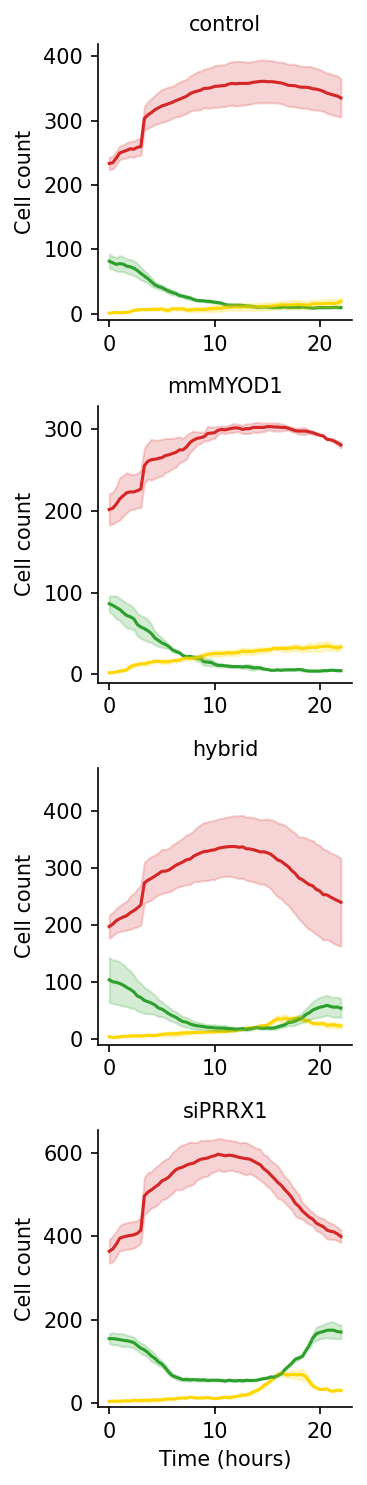

In [28]:
phase_counts = (
    df_confident
    .groupby(['frame', 'stage', 'condition', 'scene', 'phase_final2'])
    .size()
    .reset_index(name='n_cells')
)

# drop unlabeled
phase_counts = phase_counts[phase_counts['phase_final2'] != 'unlabeled']

# drop M phase for now
phase_counts = phase_counts[phase_counts['phase_final2'] != 'M']

# shift stage 2 times to follow after stage 1
max_time_stage1 = phase_counts.loc[phase_counts["stage"] == 1.0, "frame"].max()
phase_counts["time_shifted"] = phase_counts["frame"] + (
    (phase_counts["stage"] == 2.0) * (max_time_stage1 + 1)
)

# calculate hours (1 time point = 20 minutes)
phase_counts['time_hours'] = phase_counts['time_shifted'] / 3

max_cells_per_condition = (
    phase_counts
    .groupby('condition')['n_cells']
    .max()
    .to_dict()
)


stage = 1.0
phase_counts = phase_counts[phase_counts['stage'] == stage]


plt.rcParams['figure.dpi'] = 150
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(3, 10)) # 6x10 for stage 2, 3x10 for stage 1

conditions = ['control', 'mmMYOD1', 'hybrid', 'siPRRX1']

phase_colors = {
    'G1': 'tab:red',
    'G1-S': 'gold',
    'S/G2/M': 'tab:green',
    # 'M': 'gray',
    # 'unlabeled': 'black',
}

for ax, cond in zip(axes, conditions):
    d = phase_counts.loc[phase_counts["condition"] == cond]

    sns.lineplot(
        data=d,
        x="time_hours",
        y="n_cells",
        hue="phase_final2",
        ax=ax,
        palette=phase_colors,
        lw=1.5,
        errorbar='se',
        zorder=0,
    )

    ax.set_title(f"{cond}", fontsize=10)
    ax.set_ylabel("Cell count")
    ax.set_xlabel("")

    max_y = max_cells_per_condition[cond]
    ax.set_ylim(-10, max_y + 20)
    
    ax.legend().set_visible(False)

axes[-1].set_xlabel("Time (hours)")


sns.despine()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

(6094, 11)


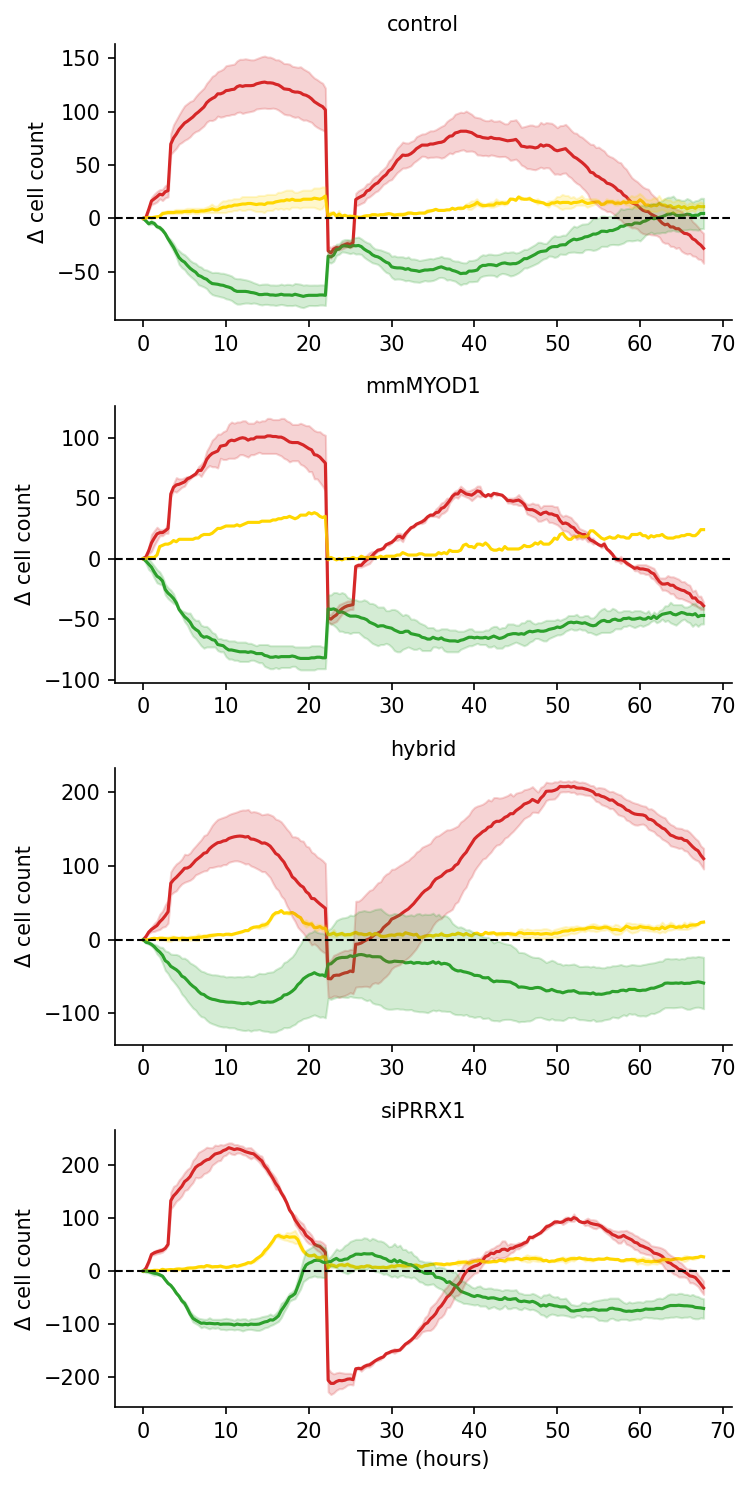

In [100]:
phase_counts = (
    df_confident
    .groupby(['frame', 'stage', 'condition', 'scene', 'phase_final2'])
    .size()
    .reset_index(name='n_cells')
)

# drop unlabeled
phase_counts = phase_counts[phase_counts['phase_final2'] != 'unlabeled']

# drop M phase for now
phase_counts = phase_counts[phase_counts['phase_final2'] != 'M']

# shift stage 2 times to follow after stage 1
max_time_stage1 = phase_counts.loc[phase_counts["stage"] == 1.0, "frame"].max()
phase_counts["time_shifted"] = phase_counts["frame"] + (
    (phase_counts["stage"] == 2.0) * (max_time_stage1 + 1)
)

# calculate hours (1 time point = 20 minutes)
phase_counts['time_hours'] = phase_counts['time_shifted'] / 3

max_cells_per_condition = (
    phase_counts
    .groupby('condition')['n_cells']
    .max()
    .to_dict()
)




stage = 2.0

if stage == 1.0:
    figsize = (3, 10)
    baseline_t = 0
    
if stage == 2.0:
    figsize = (6, 10)
    baseline_t = 67


# phase_counts = phase_counts[phase_counts['stage'] == stage]


# # Get baseline counts (time=0) for each group
# baseline = (
#     phase_counts.loc[phase_counts["frame"] == 0, ["stage", "condition", "scene", "phase_final2", "n_cells"]]
#     .rename(columns={"n_cells": "baseline_cells"})
# )


# phase_counts = phase_counts.merge(baseline, on=["stage", "condition", "scene", "phase_final2"], how="left")


baseline = (
    phase_counts.loc[
        (phase_counts["stage"] == 1.0) & (phase_counts["frame"] == 0),
        ["condition", "scene", "phase_final2", "n_cells"]
    ]
    .rename(columns={"n_cells": "baseline_cells"})
)

phase_counts = phase_counts.merge(
    baseline,
    on=["condition", "scene", "phase_final2"],
    how="left"
)


phase_counts['n_cells_rel'] = phase_counts['n_cells'] / phase_counts['baseline_cells']
phase_counts['n_cells_abs'] = phase_counts['n_cells'] - phase_counts['baseline_cells']

print(phase_counts.shape)
phase_counts.head()
plt.rcParams['figure.dpi'] = 150


    
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=figsize) # 6x10 for stage 2, 3x10 for stage 1

conditions = ['control', 'mmMYOD1', 'hybrid', 'siPRRX1']

phase_colors = {
    'G1': 'tab:red',
    'G1-S': 'gold',
    'S/G2/M': 'tab:green',
    # 'M': 'gray',
    # 'unlabeled': 'black',
}

for ax, cond in zip(axes, conditions):
    d = phase_counts.loc[phase_counts["condition"] == cond]

    sns.lineplot(
        data=d,
        x="time_hours",
        y="n_cells_abs",
        hue="phase_final2",
        ax=ax,
        palette=phase_colors,
        lw=1.5,
        errorbar='se',
        zorder=0,
    )

    ax.set_title(f"{cond}", fontsize=10)
    ax.set_ylabel("Δ cell count")
    ax.set_xlabel("")

    # max_y = max_cells_per_condition[cond]
    # ax.set_ylim(-10, max_y + 20)
    
    ax.legend().set_visible(False)
    
    ax.axhline(y=0, ls='--', color='k', lw=1)

axes[-1].set_xlabel("Time (hours)")


sns.despine()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

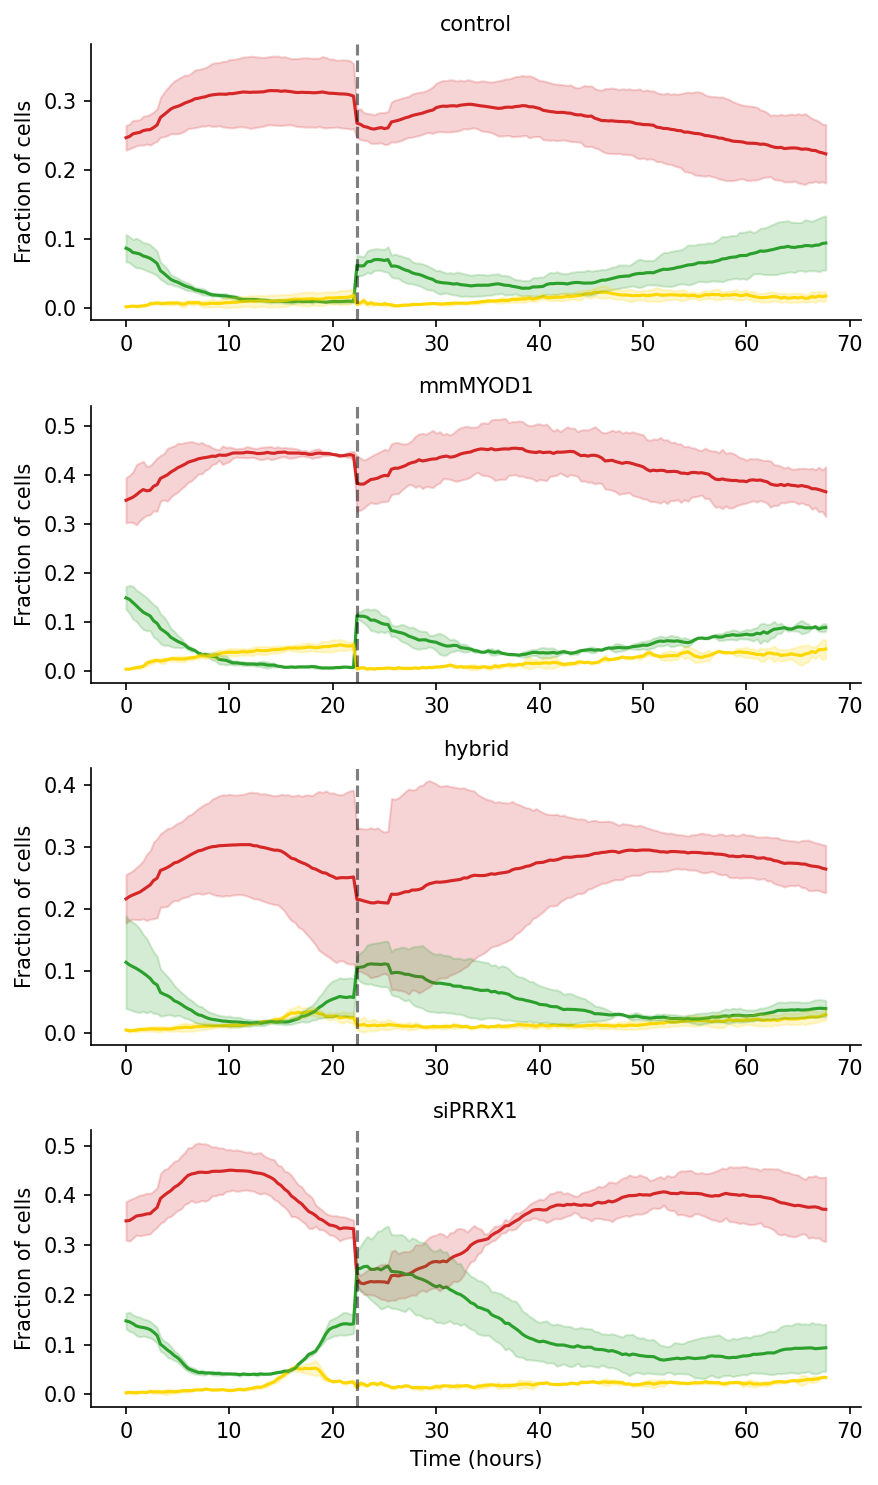

In [35]:
phase_counts = (
    df_confident
    .groupby(['frame', 'stage', 'condition', 'scene', 'phase_final2'])
    .size()
    .reset_index(name='n_cells')
)

# drop unlabeled
phase_counts = phase_counts[phase_counts['phase_final2'] != 'unlabeled']

# drop M phase for now
phase_counts = phase_counts[phase_counts['phase_final2'] != 'M']

# shift stage 2 times to follow after stage 1
max_time_stage1 = phase_counts.loc[phase_counts["stage"] == 1.0, "frame"].max()
phase_counts["time_shifted"] = phase_counts["frame"] + (
    (phase_counts["stage"] == 2.0) * (max_time_stage1 + 1)
)

# calculate hours (1 time point = 20 minutes)
phase_counts['time_hours'] = phase_counts['time_shifted'] / 3

max_cells_per_condition = (
    phase_counts
    .groupby('condition')['n_cells']
    .max()
    .to_dict()
)


# stage = 1.0
# phase_counts = phase_counts[phase_counts['stage'] == stage]



phase_counts['total_cells_timepoint'] = (
    phase_counts
    .groupby(['condition', 'time_shifted'])['n_cells']
    .transform('sum')
)

phase_counts['fraction'] = (
    phase_counts['n_cells'] / phase_counts['total_cells_timepoint']
)



plt.rcParams['figure.dpi'] = 150
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(7, 10)) # 6x10 for stage 2, 3x10 for stage 1

conditions = ['control', 'mmMYOD1', 'hybrid', 'siPRRX1']

phase_colors = {
    'G1': 'tab:red',
    'G1-S': 'gold',
    'S/G2/M': 'tab:green',
    # 'M': 'gray',
    # 'unlabeled': 'black',
}

for ax, cond in zip(axes, conditions):
    d = phase_counts.loc[phase_counts["condition"] == cond]

    sns.lineplot(
        data=d,
        x="time_hours",
        y="fraction",
        hue="phase_final2",
        ax=ax,
        palette=phase_colors,
        lw=1.5,
        errorbar='sd',
        zorder=0,
    )

    ax.set_title(f"{cond}", fontsize=10)
    ax.set_ylabel("Fraction of cells")
    ax.set_xlabel("")

    # max_y = max_cells_per_condition[cond]
    # ax.set_ylim(-10, max_y + 20)
    
    stage_boundary = (max_time_stage1 + 1) / 3

    ax.axvline(stage_boundary, linestyle='--', color='black', alpha=0.5)
    
    
    ax.legend().set_visible(False)

axes[-1].set_xlabel("Time (hours)")


sns.despine()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [32]:
phase_counts = (
    df_confident
    .groupby(['frame', 'stage', 'condition', 'scene', 'phase_final2'])
    .size()
    .reset_index(name='n_cells')
)

phase_counts.head()

# drop unlabeled
phase_counts = phase_counts[phase_counts['phase_final2'] != 'unlabeled']

# drop M phase for now
phase_counts = phase_counts[phase_counts['phase_final2'] != 'M']


# shift stage 2 times to follow after stage 1
max_time_stage1 = phase_counts.loc[phase_counts["stage"] == 1.0, "frame"].max()
phase_counts["time_shifted"] = phase_counts["frame"] + (
    (phase_counts["stage"] == 2.0) * (max_time_stage1 + 1)
)

# calculate hours (1 time point = 20 minutes)
phase_counts['time_hours'] = phase_counts['time_shifted'] / 3


phase_counts.head()

,frame,stage,condition,scene,phase_final2,n_cells,time_shifted,time_hours
0,0,1.0,control,B2,G1,235,0,0.0
2,0,1.0,control,B2,S/G2/M,91,0,0.0
4,0,1.0,control,C2,G1,250,0,0.0
5,0,1.0,control,C2,G1-S,1,0,0.0
7,0,1.0,control,C2,S/G2/M,94,0,0.0


In [91]:
phase_counts[phase_counts['stage'] == 2.0]['time_shifted'].min()

67

In [73]:
phase_counts['time_shifted'].describe()

count    6094.000000
mean      101.863800
std        58.737333
min         0.000000
25%        51.000000
50%       102.000000
75%       153.000000
max       203.000000
Name: time_shifted, dtype: float64

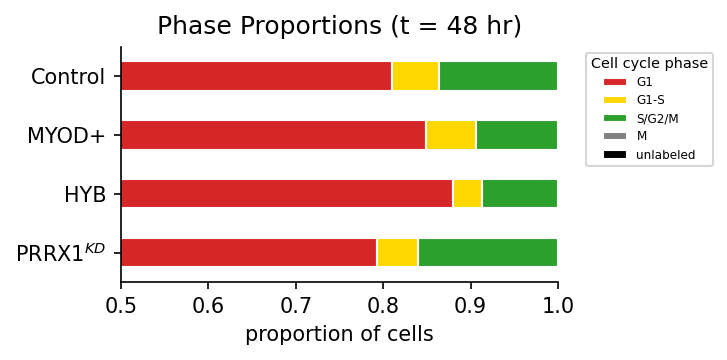

In [81]:
timepoint = 48
d_stage = phase_counts[phase_counts['time_hours'] == timepoint]

props = (
    d_stage.groupby(["condition", "phase_final2"])["n_cells"]
     .sum()
     .reset_index(name="n_cells")
)

props["prop"] = props.groupby("condition")["n_cells"].transform(lambda x: x / x.sum())
d_wide = props.pivot(index="condition", columns="phase_final2", values="prop").fillna(0)


phase_order = list(phase_colors.keys())
cond_order = ['siPRRX1', 'hybrid', 'mmMYOD1', 'control']

d_wide = d_wide.reindex(cond_order, columns=phase_order, fill_value=0)

d_wide.head()

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 5, 2.5

d_wide.plot(
    kind="barh",
    stacked=True,
    color=[phase_colors[phase] for phase in d_wide.columns],
    edgecolor="white",
    width=0.5,
)
       
        
# plt.xlim([0.5, 1.01])
plt.xlabel("proportion of cells")
plt.ylabel("")

tick_labels = [r'PRRX1$^{KD}$', 'HYB', 'MYOD+', 'Control']
plt.yticks(ticks=range(len(cond_order)), labels=tick_labels)

plt.title(f"Phase Proportions (t = {timepoint} hr)")

plt.legend(
    title="Cell cycle phase",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize='xx-small',
    title_fontsize='x-small',
)

plt.xlim([0.5, 1])

sns.despine()
plt.tight_layout()
plt.show()

In [80]:
props


,condition,phase_final2,n_cells,prop
0,control,G1,908,0.809991
1,control,G1-S,61,0.054416
2,control,S/G2/M,152,0.135593
3,hybrid,G1,1169,0.879609
4,hybrid,G1-S,44,0.033108
5,hybrid,S/G2/M,116,0.087284
6,mmMYOD1,G1,477,0.848754
7,mmMYOD1,G1-S,32,0.056940
8,mmMYOD1,S/G2/M,53,0.094306
9,siPRRX1,G1,874,0.792384


In [33]:
props = (
    phase_counts
    .groupby(["time_hours", "condition", "phase_final2"])["n_cells"]
    .sum()
    .reset_index()
)

props["prop"] = (
    props.groupby(["time_hours", "condition"])["n_cells"]
    .transform(lambda x: x / x.sum())
)

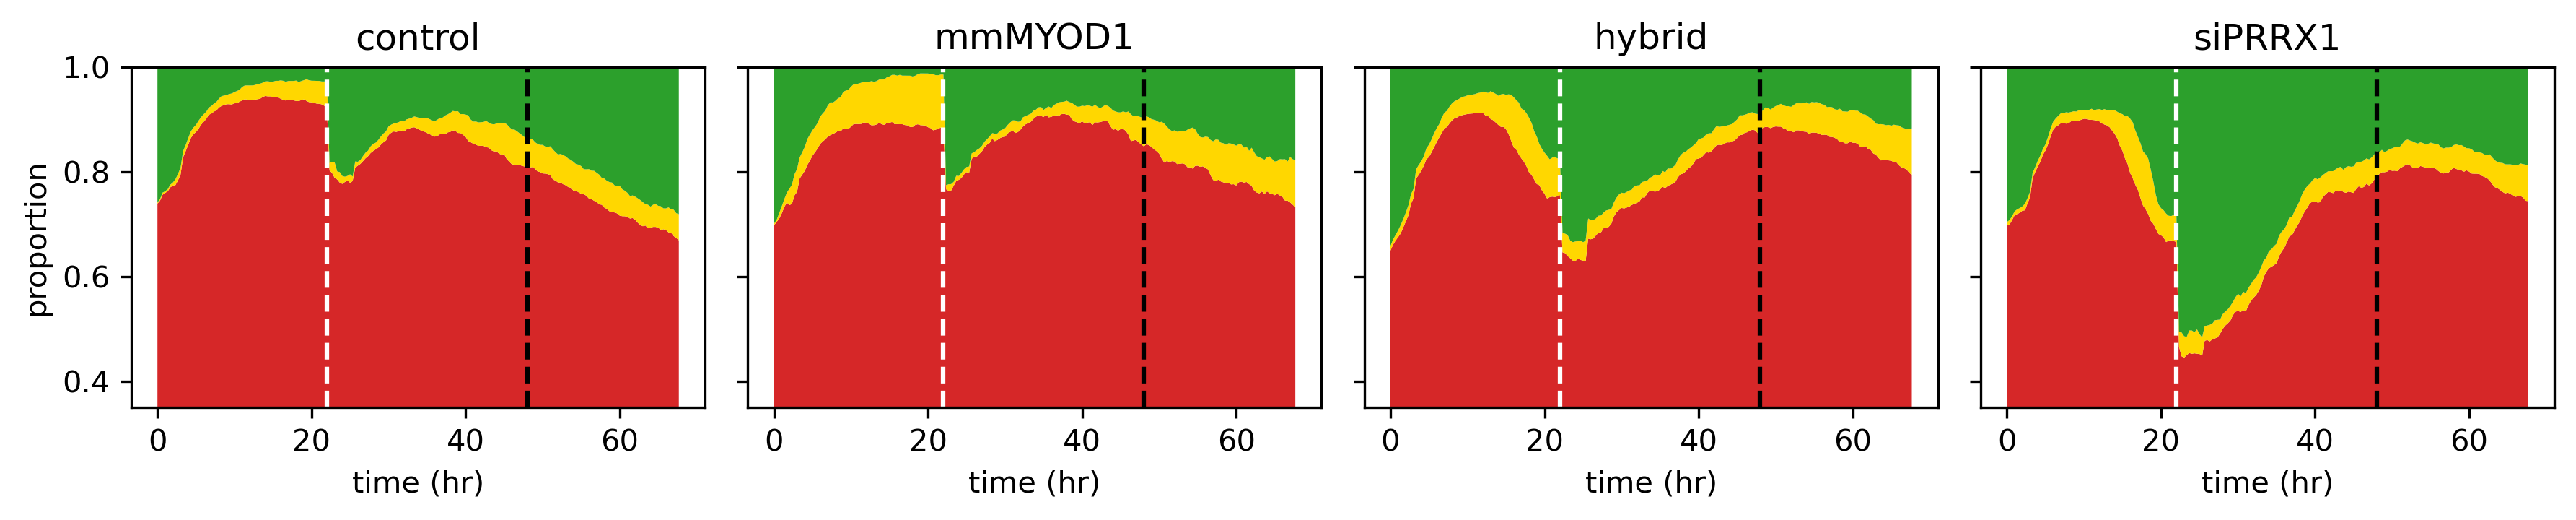

In [34]:
# conds = ['siPRRX1', 'hybrid', 'mmMYOD1', 'control']
conds = ['control', 'mmMYOD1', 'hybrid', 'siPRRX1']
phase_order = list(phase_colors.keys())

fig, axes = plt.subplots(1, 4, figsize=(12, 2.5), sharey=True, dpi=300)

for i, cond in enumerate(conds):
    ax = axes[i]
    
    tmp = props[props["condition"] == cond]
    
    d_wide = (
        tmp.pivot(index="time_hours", columns="phase_final2", values="prop")
        .reindex(columns=phase_order)
        .fillna(0)
        .sort_index()
    )
    
    # stacked area plot
    ax.stackplot(
        d_wide.index,
        d_wide.T,
        colors=[phase_colors[p] for p in d_wide.columns],
        edgecolor="none"
    )
    
    ax.set_title(cond)
    ax.set_xlabel("time (hr)")
    
    if i == 0:
        ax.set_ylabel("proportion")
        
    ax.set_ylim(0.35, 1)
        
    ax.axvline(x=22, ls='--', color='white')
    ax.axvline(x=48, ls='--', color='k')

plt.tight_layout()
plt.show()

In [36]:
props = (
    phase_counts
    .groupby(["time_hours", "condition", "scene", "phase_final2"])["n_cells"]
    .sum()
    .reset_index()
)

props["prop"] = (
    props.groupby(["time_hours", "condition", "scene"])["n_cells"]
    .transform(lambda x: x / x.sum())
)

props.head()

,time_hours,condition,scene,phase_final2,n_cells,prop
0,0.0,control,B2,G1,235,0.720859
1,0.0,control,B2,S/G2/M,91,0.279141
2,0.0,control,C2,G1,250,0.724638
3,0.0,control,C2,G1-S,1,0.002899
4,0.0,control,C2,S/G2/M,94,0.272464


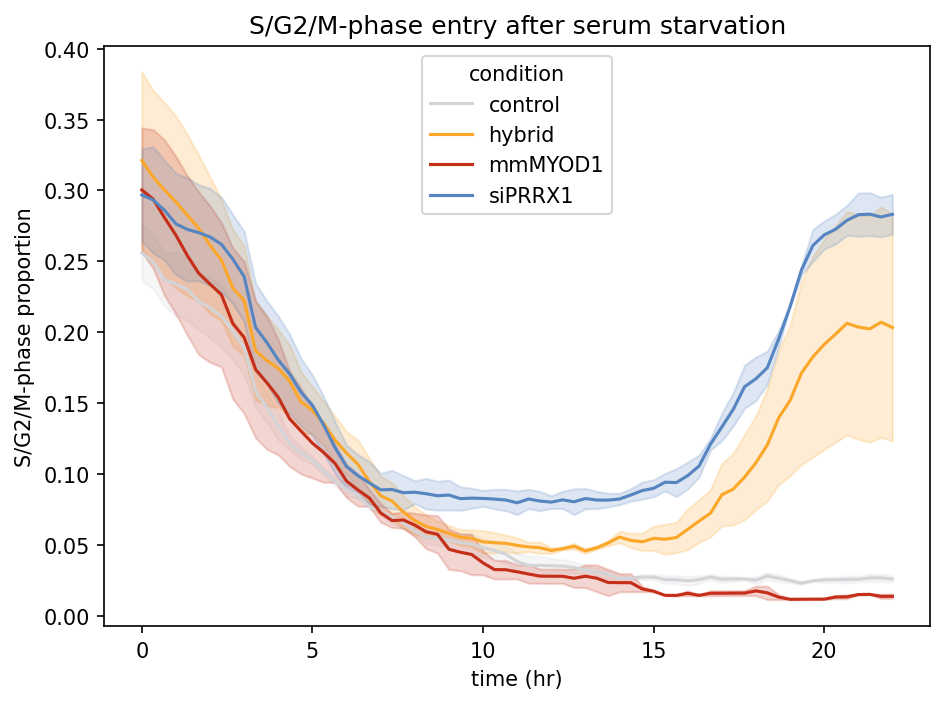

In [42]:
early_props = props[props['time_hours'] <= 22.0].copy()
early_props = early_props[early_props['phase_final2'] == 'S/G2/M'].copy()

cond_palette = {
    'control': '#D3D4D8',
    'hybrid': '#FBA72A',
    'mmMYOD1': '#C52E19',
    'siPRRX1': '#5785C1',
}

sns.lineplot(
    data=early_props,
    x='time_hours',
    y='prop',
    hue='condition',
    errorbar='se',
    palette=cond_palette,
)


plt.xlabel("time (hr)")
plt.ylabel("S/G2/M-phase proportion")
plt.title("S/G2/M-phase entry after serum starvation")

plt.tight_layout()
plt.show()

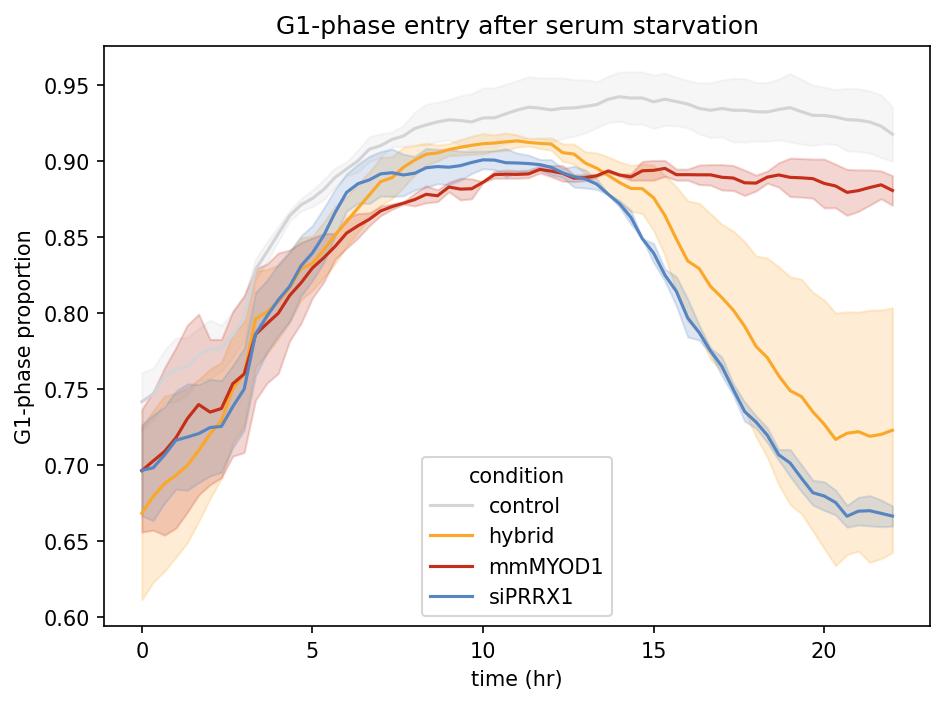

In [43]:
early_props = props[props['time_hours'] <= 22.0].copy()
early_props = early_props[early_props['phase_final2'] == 'G1'].copy()

sns.lineplot(
    data=early_props,
    x='time_hours',
    y='prop',
    hue='condition',
    errorbar='se',
    palette=cond_palette,
)


plt.xlabel("time (hr)")
plt.ylabel("G1-phase proportion")
plt.title("G1-phase entry after serum starvation")

plt.tight_layout()
plt.show()

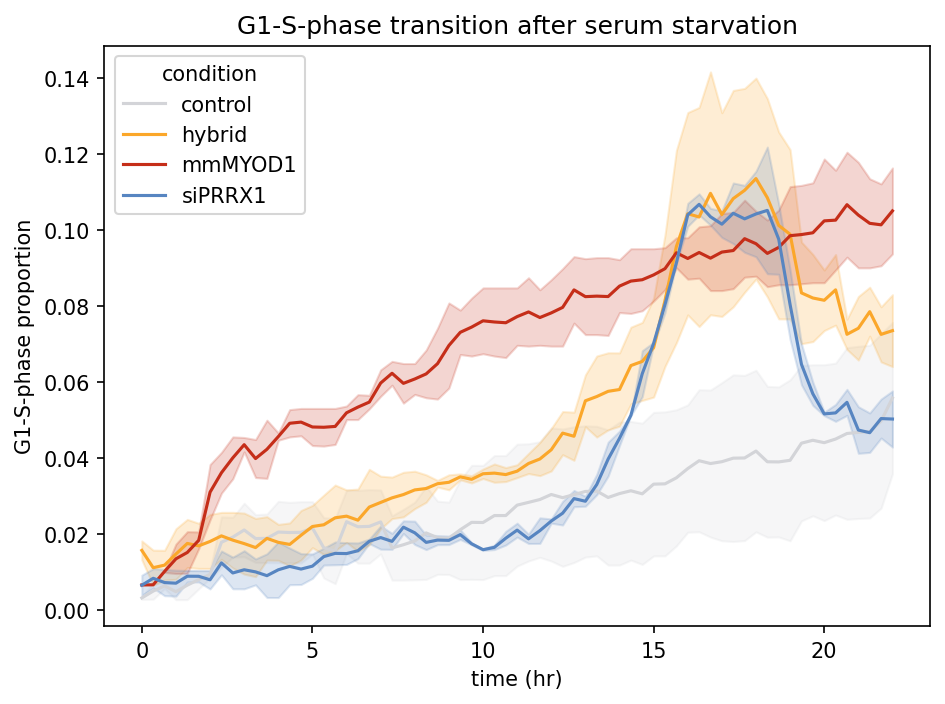

In [44]:
early_props = props[props['time_hours'] <= 22.0].copy()
early_props = early_props[early_props['phase_final2'] == 'G1-S'].copy()

sns.lineplot(
    data=early_props,
    x='time_hours',
    y='prop',
    hue='condition',
    errorbar='se',
    palette=cond_palette,
)


plt.xlabel("time (hr)")
plt.ylabel("G1-S-phase proportion")
plt.title("G1-S-phase transition after serum starvation")

plt.tight_layout()
plt.show()

In [35]:
props.head()

,time_hours,condition,phase_final2,n_cells,prop
0,0.0,control,G1,701,0.739451
1,0.0,control,G1-S,2,0.002110
2,0.0,control,S/G2/M,245,0.258439
3,0.0,hybrid,G1,593,0.649507
4,0.0,hybrid,G1-S,8,0.008762


In [46]:
props = (
    phase_counts
    .groupby(["time_hours", "condition", "phase_final2"])["n_cells"]
    .sum()
    .reset_index()
)

props["prop"] = (
    props.groupby(["time_hours", "condition"])["n_cells"]
    .transform(lambda x: x / x.sum())
)

props.head()

,time_hours,condition,phase_final2,n_cells,prop
0,0.0,control,G1,701,0.739451
1,0.0,control,G1-S,2,0.002110
2,0.0,control,S/G2/M,245,0.258439
3,0.0,hybrid,G1,593,0.649507
4,0.0,hybrid,G1-S,8,0.008762


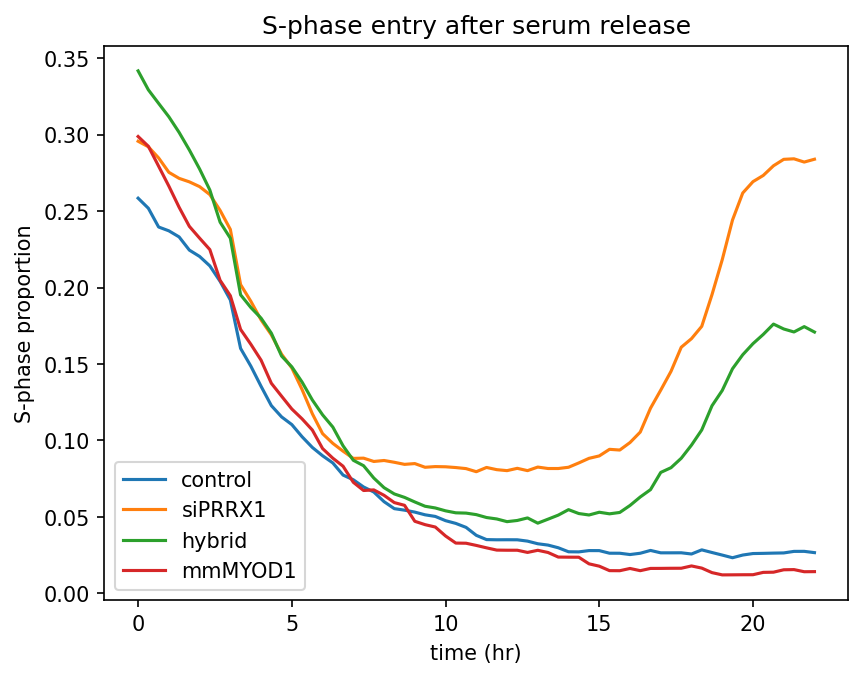

In [47]:
early_props = props[props['time_hours'] <= 22.0].copy()

for cond in ['control', 'siPRRX1', 'hybrid', 'mmMYOD1']:
    tmp = early_props[
        (early_props["condition"] == cond) &
        (early_props["phase_final2"] == "S/G2/M")
    ]
    
    plt.plot(tmp["time_hours"], tmp["prop"], label=cond)

plt.xlabel("time (hr)")
plt.ylabel("S-phase proportion")
plt.legend()
plt.title("S-phase entry after serum release")
plt.show()

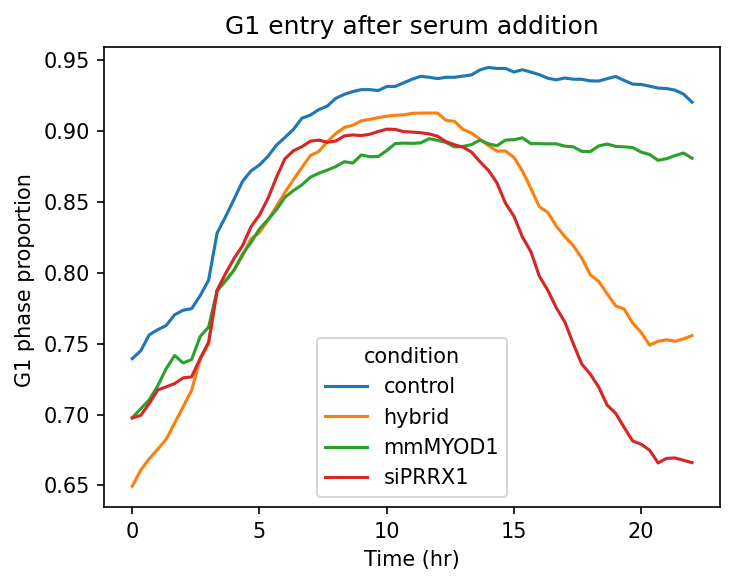

In [52]:
early_props = props[props['time_hours'] <= 22.0].copy()
early_props.head()

phase = 'G1-S'
phase = 'S/G2/M'
phase = 'G1'
early_props1 = early_props[early_props['phase_final2'] == phase]

plt.figure(figsize=(5,4), dpi=150)

sns.lineplot(
    data=early_props1,
    x='time_hours',
    y='prop',
    hue='condition',
)


if phase == 'G1':
    plt.title("G1 entry after serum addition")
    plt.ylabel('G1 phase proportion ')
    
if phase == 'G1-S':
    plt.title("G1-S transition after serum addition")
    plt.ylabel('G1-S phase proportion ')
    
if phase == 'S/G2/M':
    plt.title("S/G2/M entry after serum addition")
    plt.ylabel('S/G2/M phase proportion ')
    
plt.xlabel('Time (hr)')

plt.tight_layout()
plt.show()

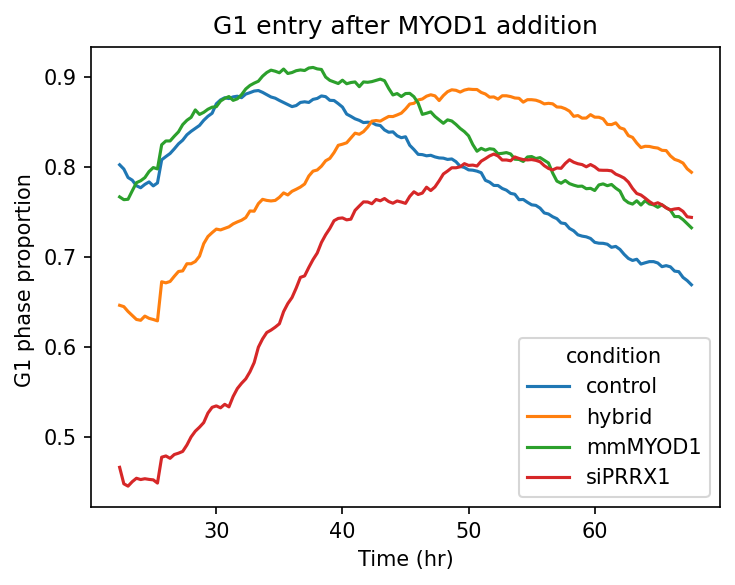

In [64]:
early_props = props[props['time_hours'] > 22.0].copy()
early_props.head()

phase = 'G1-S'
phase = 'S/G2/M'
phase = 'G1'
early_props1 = early_props[early_props['phase_final2'] == phase]

plt.figure(figsize=(5,4), dpi=150)

sns.lineplot(
    data=early_props1,
    x='time_hours',
    y='prop',
    hue='condition',
)


if phase == 'G1':
    plt.title("G1 entry after MYOD1 addition")
    plt.ylabel('G1 phase proportion ')
    
if phase == 'G1-S':
    plt.title("G1-S transition after MYOD1 addition")
    plt.ylabel('G1-S phase proportion ')
    
if phase == 'S/G2/M':
    plt.title("S/G2/M entry after MYOD1 addition")
    plt.ylabel('S/G2/M phase proportion ')
    
plt.xlabel('Time (hr)')

plt.tight_layout()
plt.show()

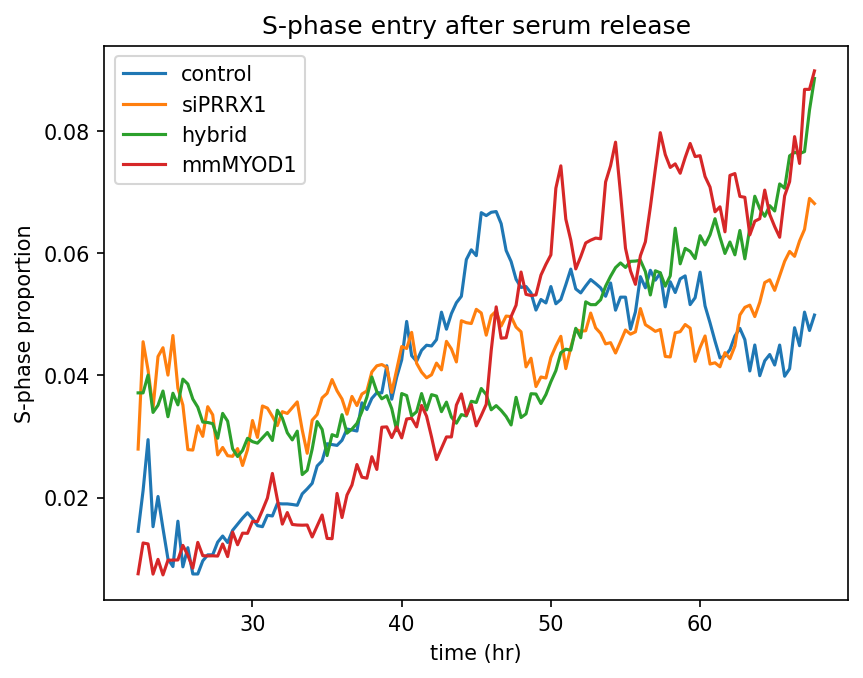

In [65]:
for cond in ['control', 'siPRRX1', 'hybrid', 'mmMYOD1']:
    tmp = early_props[
        (early_props["condition"] == cond) &
        (early_props["phase_final2"] == "G1-S")
    ]
    
    plt.plot(tmp["time_hours"], tmp["prop"], label=cond)

plt.xlabel("time (hr)")
plt.ylabel("S-phase proportion")
plt.legend()
plt.title("S-phase entry after serum release")
plt.show()

/tmp/ipykernel_2719558/3807442057.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(smooth_and_diff)


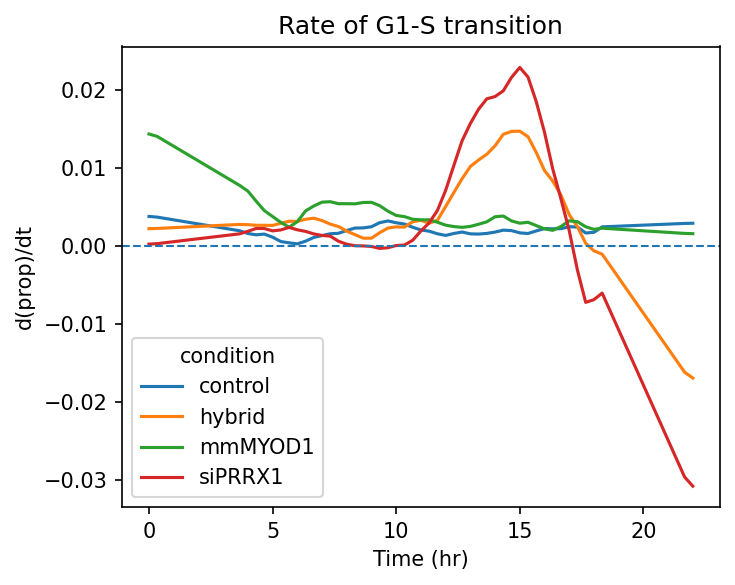

In [48]:
# def compute_derivative(g):
#     g = g.sort_values('time_hours')
#     g['dprop_dt'] = (
#         g['prop'].shift(-1) - g['prop'].shift(1)
#     ) / (
#         g['time_hours'].shift(-1) - g['time_hours'].shift(1)
#     )
#     return g

# slope_df = (
#     early_props
#     .groupby(['condition', 'phase_final2'], group_keys=False)
#     .apply(compute_derivative)
# )

def smooth_and_diff(g):
    g = g.sort_values('time_hours')
    g['prop_smooth'] = savgol_filter(g['prop'], window_length=25, polyorder=2)
    g['dprop_dt'] = np.gradient(g['prop_smooth'], g['time_hours'])
    return g


early_props = props[props['time_hours'] <= 22.0].copy()

slope_df = (
    early_props
    .groupby(['condition', 'phase_final2'], group_keys=False)
    .apply(smooth_and_diff)
)

phase = 'G1-S'

slope_phase = slope_df[slope_df['phase_final2'] == phase]

plt.figure(figsize=(5,4), dpi=150)

sns.lineplot(
    data=slope_phase,
    x='time_hours',
    y='dprop_dt',
    hue='condition',
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.xlabel('Time (hr)')
plt.ylabel('d(prop)/dt')

if phase == 'G1':
    plt.title("Rate of change in G1 proportion")
elif phase == 'G1-S':
    plt.title("Rate of G1-S transition")
elif phase == 'S/G2/M':
    plt.title("Rate of S/G2/M entry")

plt.tight_layout()
plt.show()

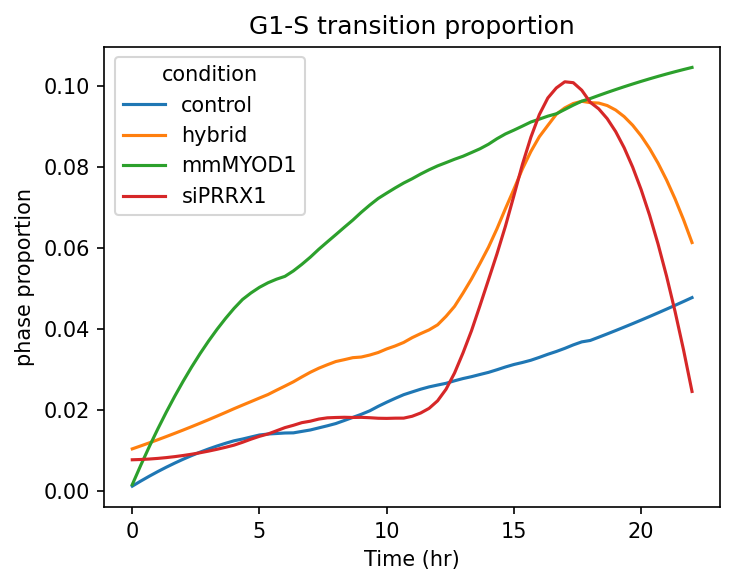

In [49]:
plt.figure(figsize=(5,4), dpi=150)

sns.lineplot(
    data=slope_phase,
    x='time_hours',
    y='prop_smooth',
    hue='condition',
)

# plt.axhline(0, linestyle='--', linewidth=1)

plt.xlabel('Time (hr)')
plt.ylabel('phase proportion')

if phase == 'G1':
    plt.title("G1 proportion")
elif phase == 'G1-S':
    plt.title("G1-S transition proportion")
elif phase == 'S/G2/M':
    plt.title("S/G2/M proportion")

plt.tight_layout()
plt.show()

In [39]:
print(df_confident.shape)
print(df_confident.columns)
df_confident.head()

(803143, 35)
Index(['frame', 'condition', 'scene', 'stage', 'particle', 'particle_id',
       'time_shifted', 'filled_area', 'Cy5_mean', 'TaGFP_mean', 'mKate_mean',
       'x', 'y', 'path_length', 'gap_length', 'has_gap', 'max_gap_length',
       'TaGFP_norm', 'mKate_norm', 'Cy5_norm', 'noisy', 'mKate_norm_smooth',
       'TaGFP_norm_smooth', 'Cy5_norm_smooth', 'ratio', 'ratio_smooth',
       'flat_flag', 'phase_raw', 'phase_final', 'phase_smoothed',
       'phase_final2', 'vmin', 'vmax', 'vmid', 'small_range'],
      dtype='object')


,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,ratio_smooth,flat_flag,phase_raw,phase_final,phase_smoothed,phase_final2,vmin,vmax,vmid,small_range
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,0.556557,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,0.551582,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,0.542279,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,0.534920,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,0.530026,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN


In [38]:
cols = ['frame', 'condition', 'scene', 'stage', 'particle_id', 'time_shifted',
        'phase_final2',
       ]


tmp = df_confident[cols].copy()

tmp = tmp[tmp['phase_final2'].isin(['G1', 'G1-S', 'S/G2/M'])]

# calculate hours (1 time point = 20 minutes)
tmp['time_hours'] = tmp['time_shifted'] / 3

tmp.head()

,frame,condition,scene,stage,particle_id,time_shifted,phase_final2,time_hours
0,0,control,B2,1.0,1_control_B2_0,0.0,G1,0.000000
1,1,control,B2,1.0,1_control_B2_0,1.0,G1,0.333333
2,2,control,B2,1.0,1_control_B2_0,2.0,G1,0.666667
3,3,control,B2,1.0,1_control_B2_0,3.0,G1,1.000000
4,4,control,B2,1.0,1_control_B2_0,4.0,G1,1.333333


In [54]:
tmp[tmp['stage'] == 1.0]['time_hours'].max()

22.0

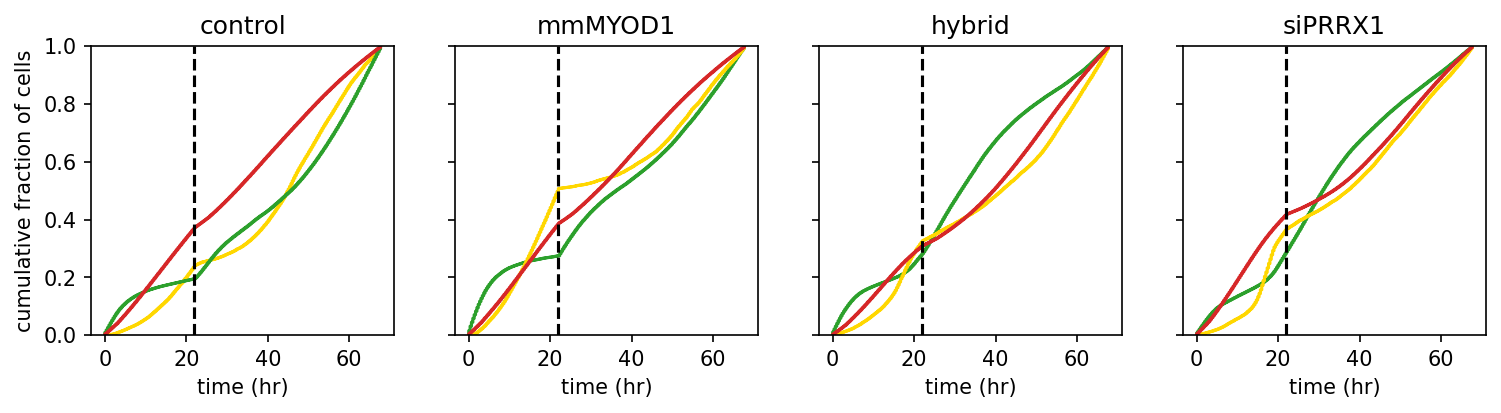

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.5), sharey=True, dpi=150)


for i, cond in enumerate(conds):
    ax = axes[i]
    
    tmp1 = tmp[tmp["condition"] == cond]
    
    sns.ecdfplot(
        data=tmp1,
        x="time_hours",
        hue="phase_final2",
        palette=phase_colors,
        ax=ax,
        legend=False,
    )
    
    ax.set_title(cond)
    ax.set_xlabel("time (hr)")
    ax.set_ylabel("cumulative fraction of cells")
    ax.axvline(x=22, ls='--', color='k')

plt.show()

In [ ]:
tmp1 = tmp.copy()





fig, axes = plt.subplots(1, 4, figsize=(12, 2.5), sharey=True, dpi=150)


for i, cond in enumerate(conds):
    ax = axes[i]
    
    tmp1 = tmp[tmp["condition"] == cond]
    
    sns.ecdfplot(
        data=tmp1,
        x="time_hours",
        hue="phase_final2",
        palette=phase_colors,
        ax=ax,
        legend=False,
    )
    
    ax.set_title(cond)
    ax.set_xlabel("time (hr)")
    ax.set_ylabel("cumulative fraction of cells")
    ax.axvline(x=22, ls='--', color='k')

plt.show()